# Analyse contrail climate impact of 2019 European departures

- Contrail forcing by departure airport
- Contrail forcing by departure FIR 
- Contrail forcing by departure time of day
- Contrail forcing by departure month of year 
- Number of big hits by day and airport
- Number of big hits by day and FIR

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet(r"C:\Users\TE\Documents\Datasets\icl/2019 - Jet-A - Flight Summary.pq")

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

###########################################
### CO2 emissions and radiative forcing ###
###########################################

# Density of conventional jet fuel
density_kerosene = 0.81 # kg/l

# CO2 emitted per kilogram of jet fuel
CO2_per_kg_fuel = 3.168  # kg_CO2/kg_jet_a1

# Total surface area of Earth
earth_surface_area = 5.101e14  # m^2

# CO2 absolute global warming potential over 20 years
CO2_agwp_20_years = 2.39e-14  # yr W m^-2 kg^-2

# CO2 absolute global warming potential over 100 years
CO2_agwp_100_years = 8.8e-14  # yr W m^-2 kg^-2

# Number of seconds in a year
seconds_per_year = 365 * 24 * 60 * 60  # s/yr

# Effective radiative forcing to radiative forcing ratio
ERF_RF_ratio = 0.42

fuel_to_co2_forcing_20  = CO2_per_kg_fuel * earth_surface_area * CO2_agwp_20_years  * seconds_per_year
fuel_to_co2_forcing_100 = CO2_per_kg_fuel * earth_surface_area * CO2_agwp_100_years * seconds_per_year


# Calculate tailpipe CO2 emissions, AGWP and GWP
df["total_co2"]              = df["total_fuel_burn"] * CO2_per_kg_fuel
df["total_co2_forcing_20"]   = df["total_fuel_burn"] * fuel_to_co2_forcing_20
df["total_co2_forcing_100"]  = df["total_fuel_burn"] * fuel_to_co2_forcing_100
df["gwp20"]                  = df["total_contrail_energy_forcing"] / df["total_co2_forcing_20"]   * ERF_RF_ratio
df["gwp100"]                 = df["total_contrail_energy_forcing"] / df["total_co2_forcing_100"]  * ERF_RF_ratio


DATE_COL = "first_waypoint_time"  # adjust to your datetime column

# Define seasons: DJF, MAM, JJA, SON
season_map = {12: "DJF", 1: "DJF", 2: "DJF",
            3: "MAM", 4: "MAM", 5: "MAM",
            6: "JJA", 7: "JJA", 8: "JJA",
            9: "SON", 10: "SON", 11: "SON"}

title_map = {
    "DJF": "December - February", 
    "MAM": "March - May", 
    "JJA": "June - August", 
    "SON": "September - November"
}

# Month labels
month_names = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
    7:"Jul", 8:"Aug", 9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}

if not np.issubdtype(df[DATE_COL].dtype, np.datetime64):
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

df["_month"]  = df[DATE_COL].dt.month
df["_season"] = df["_month"].map(season_map)
df["_hour"]   = df[DATE_COL].dt.hour  # 0..23

countries = pd.read_csv("data/icl/countries.csv")

# Suppose your dataframe is named df
iso2_to_region = countries.set_index('alpha-2')['region'].to_dict()

# Now you can map this to another DataFrame column:
df['origin_region'] = df['origin_country'].map(iso2_to_region)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------------------
# T&E visual style
# ---------------------------
TE_PRIMARY = "#75A1F4"  # main blue
TE_POS     = "#039961"  # positive/“good”
TE_NEG     = "#C2447A"  # negative
TE_ACCENT  = "#FF8754"  # secondary accent
TE_TEXT    = "#707070"  # text
TE_GRID    = "#9E9E9E"  # grid
TE_BG      = "#FFFFFF"  # white background

# Figure size close to 794x575px at 150 dpi (Flourish style)
FIGSIZE = (5.3, 4)
DPI = 150

mpl.rcParams.update({
    # Fonts
    "font.family": "DejaVu Sans",          # requires Roboto installed; otherwise comment this & next line
    "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
    "font.size": 12,
    # Colors & axes
    "text.color": TE_TEXT,
    "axes.labelcolor": TE_TEXT,
    "axes.edgecolor": "#EEEEEE",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.facecolor": TE_BG,
    
    # Ticks
    "xtick.color": TE_TEXT,
    "ytick.color": TE_TEXT,
    # Legend
    "legend.frameon": False,
})



def plot_contrail_distribution(df): 
    title = "All flights"

    def analyse_df(df):
        datum = {}
        datum["n_flights"] = len(df)
        datum["gwp"]       = df["total_contrail_energy_forcing"].sum()/df["total_co2_forcing_100"].sum() * ERF_RF_ratio
        datum["co2"]       = df["total_co2"].sum()
        datum["contrails"] = df["total_contrail_energy_forcing"].sum()
        return datum

    data = {}
    data["global"]            = analyse_df(df)
    no_contrails              = df[df['mean_contrail_lifetime'].isna()]
    data["no_contrails"]      = analyse_df(no_contrails)
    persistent_contrails      = df[df['mean_contrail_lifetime'] > 0]
    data["forming_contrails"] = analyse_df(persistent_contrails)
    cooling_contrails         = persistent_contrails[persistent_contrails['total_contrail_energy_forcing'] < 0]
    data["cooling"]           = analyse_df(cooling_contrails)
    warming_contrails         = persistent_contrails[persistent_contrails['total_contrail_energy_forcing'] > 0]
    data["warming"]           = analyse_df(warming_contrails)

    # Calculate cumulative EF contrail as a function of the share of all flights
    sorted_df      = persistent_contrails.sort_values(by='total_contrail_energy_forcing', ascending=False)
    sorted_forcing = sorted_df['total_contrail_energy_forcing'].cumsum()
    normalized_sorted_forcing = sorted_forcing / sorted_forcing.iloc[-1]

    normalized_sorted_forcing.reset_index(drop=True, inplace=True)  # Reset indices
    flight_share = np.arange(1, len(sorted_df) + 1)/len(df) * 100

    # Determine the percentage of all flights that cause 80% of the annual energy forcing
    eighty_percent_index = (normalized_sorted_forcing >= 0.8).idxmax()
    eighty_percent_flights = flight_share[eighty_percent_index]


    very_warming_contrails               =  sorted_df.iloc[:eighty_percent_index]
    data["very_warming"]                 = analyse_df(very_warming_contrails)
    slightly_warming_contrails           = sorted_df.iloc[eighty_percent_index:]
    data["slightly_warming_and_cooling"] = analyse_df(slightly_warming_contrails)
    slightly_warming_contrails           = slightly_warming_contrails[slightly_warming_contrails['total_contrail_energy_forcing'] > 0]
    data["slightly_warming"]             = analyse_df(slightly_warming_contrails)

    # ---------------------------
    # Plot 1: Cumulative EF vs flight share (clean, no markers)
    # ---------------------------
    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    # Highlight area up to 80% forcing
    ax.fill_between(
        flight_share[:eighty_percent_index+1],
        normalized_sorted_forcing[:eighty_percent_index+1] * 100,
        step=None, alpha=0.15, color=TE_PRIMARY
    )

    ax.plot(flight_share, normalized_sorted_forcing * 100,
            linewidth=2.2, color=TE_PRIMARY)

    # Reference lines
    ax.axhline(80, color=TE_GRID, linestyle="--", linewidth=1)
    ax.axhline(100, color=TE_GRID, linestyle="--", linewidth=1)

    # Direct annotation (label-as-legend)
    ax.annotate(
        f"{eighty_percent_flights:.1f}% of flights cause 80% of warming",
        xy=(eighty_percent_flights, 80),
        xytext=(min(eighty_percent_flights + 8, 50), 88),
        textcoords="data",
        arrowprops=dict(arrowstyle="-|>", linewidth=1, color=TE_TEXT),
        ha="left", va="bottom", fontsize=11, color=TE_TEXT
    )

    ax.set_title(f"A small share of flights cause 80% of contrail warming", pad=20)
    ax.set_xlabel("Share of flights (%)")
    ax.set_ylabel("Cumulative contrail warming (%)")
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 125)

    plt.tight_layout()
    plt.show()


    # ---------------------------
    # Plot 2: Replace pies with 100% stacked bars
    # ---------------------------
    # Shares for number of flights
    nflight_labels = ['no_contrails', 'cooling', 'slightly_warming', 'very_warming']
    nflight_vals = np.array([data[k]['n_flights'] for k in nflight_labels], dtype=float)
    nflight_share = nflight_vals / nflight_vals.sum()

    # Shares for CO2
    co2_labels = ['no_contrails', 'cooling', 'slightly_warming', 'very_warming']
    co2_vals = np.array([data[k]['co2'] for k in co2_labels], dtype=float)
    co2_share = co2_vals / co2_vals.sum()

    # Shares for Contrails (warming-heavy vs the rest)
    contrails_labels = ['slightly_warming_and_cooling', 'very_warming']
    contrails_vals = np.array([data[k]['contrails'] for k in contrails_labels], dtype=float)
    contrails_share = contrails_vals / contrails_vals.sum()

    # Consistent colors by category
    cat_colors = {
        'no_contrails': "#BCDCF5",                       # soft blue for "none"
        'cooling': TE_PRIMARY,                               # negative = magenta family
        'slightly_warming': TE_ACCENT,                   # light orange
        'very_warming': TE_NEG,                      # main blue
        'slightly_warming_and_cooling': "#B4D8F4",       # light blue
    }


    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=DPI)  # ~21x7 at 150dpi is overkill for screens
    axes[0].pie(nflight_share, labels=nflight_labels, colors=[cat_colors["no_contrails"], cat_colors["cooling"], cat_colors["slightly_warming"], cat_colors["very_warming"]])
    axes[0].set_title("Number of flights")
    axes[1].pie(co2_share,    labels= co2_labels, colors=[cat_colors["no_contrails"], cat_colors["cooling"], cat_colors["slightly_warming"], cat_colors["very_warming"]])
    axes[1].set_title("CO₂ distribution")
    axes[2].pie(contrails_share,labels= contrails_labels, colors=[cat_colors["slightly_warming"], cat_colors["very_warming"]])
    axes[2].set_title("Contrail warming distribution")
    plt.tight_layout()
    plt.show()



    # Extract labels and values for CO₂ and GWP100
    labels = ['global', 'no_contrails', 'forming_contrails', 'cooling', 'slightly_warming', 'very_warming']
    co2_values = [1] * len(labels)  # CO₂ bar of size 1 for each category
    gwp_values = [data[label]['gwp'] for label in labels]

    # Set up the figure and axes
    x = np.arange(len(labels))  # Label locations
    width = 0.35  # Width of the bars

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot CO₂ bars
    co2_bars = ax.bar(x - width/2, co2_values, width, label='CO₂ (scaled to 1)')

    # Plot GWP100 bars
    gwp_bars = ax.bar(x + width/2, gwp_values, width, label='GWP100')

    # Add annotations on top of each bar
    for bar in co2_bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

    for bar in gwp_bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

    # Add labels, title, and legend
    ax.set_xlabel('Category')
    ax.set_ylabel('Value')
    ax.set_title(title + ': Comparison of CO₂ and GWP100 by Category')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    # Display the chart
    plt.tight_layout()
    plt.show()



    # --- Define warming/cooling components ---
    # Big-hit warming (positives only, by month)
    vw_month = (
        very_warming_contrails
        .assign(warming=lambda d: d["total_contrail_energy_forcing"].clip(lower=0))
        .groupby("_month", dropna=True)["warming"]
        .sum()
        .reindex(range(1,13), fill_value=0.0)
    )

    # Other warming (positives only, by month)
    ow_month = (
        slightly_warming_contrails
        .assign(warming=lambda d: d["total_contrail_energy_forcing"].clip(lower=0))
        .groupby("_month", dropna=True)["warming"]
        .sum()
        .reindex(range(1,13), fill_value=0.0)
    )

    # Cooling (negatives only, by month) — keep negative sign
    cool_month = (
        cooling_contrails
        .assign(cooling=lambda d: d["total_contrail_energy_forcing"].clip(upper=0))
        .groupby("_month", dropna=True)["cooling"]
        .sum()
        .reindex(range(1,13), fill_value=0.0)
    )

    # --- Normalise by TOTAL annual warming (so big-hit + warming + cooling months sum to +100%) ---
    total_vw = max(df["total_contrail_energy_forcing"].sum(), 1e-12)  # avoid /0
    vw_pct   = vw_month / total_vw * 100.0
    ow_pct   = ow_month / total_vw * 100.0
    cool_pct = cool_month / total_vw * 100.0  # stays negative

    # --- Colors (T&E-ish): cooling blue, big-hits magenta/red, other warming orange ---
    COOLING_BLUE   = "#4A78C2"  # blue (cooling)
    BIG_HIT_RED    = "#C2447A"  # strong pink/red (big hits)
    OTHER_WARM_ORG = "#FF8754"  # lighter red/orange (other warming)



    # Count number of flights in each month
    monthly_counts = (
        df.groupby("_month").size()
        .reindex(range(1, 13), fill_value=0)
    )
    monthly_counts = monthly_counts / monthly_counts.sum() * 100



    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 4), dpi=DPI)  # wider than FIGSIZE

    months = np.arange(1, 13)

    # Cooling (negative, plotted first so stacks correctly)
    ax.bar(months, cool_pct.values, color=COOLING_BLUE, edgecolor="none", label="Cooling flights")

    # Big-hit warming (positive)
    ax.bar(months, vw_pct.values, bottom=np.maximum(cool_pct.values, 0),  # bottom=0 since cool is negative
        color=BIG_HIT_RED, edgecolor="none", label="Big-hit warming")

    # Other warming (stacked on top of big-hit)
    ax.bar(months, ow_pct.values, bottom=vw_pct.values,  # positive stack only
        color=OTHER_WARM_ORG, edgecolor="none", label="Other warming")

    # Cosmetics
    ax.axhline(0, color="#9E9E9E", linewidth=1)         # zero line
    ax.set_xticks(months)
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
    ax.set_ylabel("% of annual contrail warming")
    ax.set_title(f"Big hits by month (monthly averages)")

    ax2 = ax.twinx()
    ax2.plot(months, monthly_counts.values,
            color="black", marker="o", linewidth=1.5, markersize=5, label="Flight number")
    ax2.set_ylabel("% of annual flights", color="black")
    ax2.tick_params(axis='y', colors="black")
    ax.set_ylim(-2, 17)
    ax2.set_ylim(-2, 17)

    # --- Combined legend ---
    # Get both bar and line handles/labels
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2,
            ncols=4, loc="upper center", bbox_to_anchor=(0.5, -0.2),
            frameon=False, fontsize=9)

    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()
    HOURS = range(24)

    # --- Define warming/cooling by hour ---
    vw_hour = (
        very_warming_contrails
        .assign(warming=lambda d: d["total_contrail_energy_forcing"].clip(lower=0))
        .groupby("_hour", dropna=True)["warming"]
        .sum()
        .reindex(HOURS, fill_value=0.0)
    )

    ow_hour = (
        slightly_warming_contrails
        .assign(warming=lambda d: d["total_contrail_energy_forcing"].clip(lower=0))
        .groupby("_hour", dropna=True)["warming"]
        .sum()
        .reindex(HOURS, fill_value=0.0)
    )

    cool_hour = (
        cooling_contrails
        .assign(cooling=lambda d: d["total_contrail_energy_forcing"].clip(upper=0))
        .groupby("_hour", dropna=True)["cooling"]
        .sum()
        .reindex(HOURS, fill_value=0.0)
    )

    # --- Normalise by TOTAL annual warming (same as your month plot) ---
    total_warming = max(df["total_contrail_energy_forcing"].sum(), 1e-12)
    vw_pct_h   = vw_hour / total_warming * 100.0
    ow_pct_h   = ow_hour / total_warming * 100.0
    cool_pct_h = cool_hour / total_warming * 100.0  # negative stays negative

    # --- Secondary axis series: % of annual flights by hour ---
    hourly_counts = (
        df.groupby("_hour").size()
        .reindex(HOURS, fill_value=0)
    )
    flights_pct_h = hourly_counts / hourly_counts.sum() * 100.0

    # --- Plot (reuses same colors/legend layout) ---
    fig, ax = plt.subplots(figsize=(9.5, 4), dpi=DPI)

    hours_idx = np.arange(24)

    # Cooling (negative)
    ax.bar(hours_idx, cool_pct_h.values,
        color=COOLING_BLUE, edgecolor="none", label="Cooling flights")

    # Big-hit warming
    ax.bar(hours_idx, vw_pct_h.values,
        bottom=np.maximum(cool_pct_h.values, 0),
        color=BIG_HIT_RED, edgecolor="none", label="Big-hit warming")

    # Other warming
    ax.bar(hours_idx, ow_pct_h.values,
        bottom=vw_pct_h.values,
        color=OTHER_WARM_ORG, edgecolor="none", label="Other warming")

    # X/Y cosmetics
    ax.axhline(0, color="#9E9E9E", linewidth=1)
    ax.set_xticks(hours_idx)
    ax.set_xticklabels([f"{h:02d}" for h in HOURS])
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("% of annual contrail warming")
    ax.set_title("Big hits by departure time (annual average)")

    # Secondary y-axis: % of annual flights
    ax2 = ax.twinx()
    ax2.plot(hours_idx, flights_pct_h.values,
            color="black", marker="o", linewidth=1.5, markersize=4.5, label="Flights (% of annual)")
    ax2.set_ylabel("% of annual flights", color="black")
    ax2.tick_params(axis='y', colors="black")

    # Smart y-lims with headroom (works for different datasets)
    upper_stack = (vw_pct_h + ow_pct_h).max()
    lower_stack = cool_pct_h.min()
    ax.set_ylim(min(-abs(lower_stack)*1.15, -2), max(upper_stack*1.15, 8))
    ax2.set_ylim(ax.get_ylim())  # keep scales visually aligned (both in %)

    # Combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2,
            ncols=4, loc="upper center", bbox_to_anchor=(0.5, -0.22),
            frameon=False, fontsize=9)

    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    
    # --- Hourly data ---
    big_hits_hour = pd.DataFrame({
        "Hour": range(24),
        "Big_hit_warming_pct": vw_pct_h,
        "Other_warming_pct": ow_pct_h,
        "Cooling_pct": cool_pct_h,
        "Flights_pct": flights_pct_h
    })
    big_hits_hour.to_csv("big_hits_by_hour.csv", index=False)

    # =========================
    # Hour-of-day by season (4 subplots)
    # =========================

    # Prepare subplot layout
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), dpi=DPI)
    axes = axes.flatten()
    secondary_axes = []

    for i, season in enumerate(["DJF", "MAM", "JJA", "SON"]):
        ax = axes[i]

        # --- Filter data for season ---
        vw_season = very_warming_contrails[very_warming_contrails["_season"] == season]
        ow_season = slightly_warming_contrails[slightly_warming_contrails["_season"] == season]
        cool_season = cooling_contrails[cooling_contrails["_season"] == season]
        df_season = df[df["_season"] == season]

        HOURS = range(24)

        # --- Aggregation ---
        vw_hour = (
            vw_season
            .assign(warming=lambda d: d["total_contrail_energy_forcing"].clip(lower=0))
            .groupby("_hour")["warming"].sum()
            .reindex(HOURS, fill_value=0.0)
        )

        ow_hour = (
            ow_season
            .assign(warming=lambda d: d["total_contrail_energy_forcing"].clip(lower=0))
            .groupby("_hour")["warming"].sum()
            .reindex(HOURS, fill_value=0.0)
        )

        cool_hour = (
            cool_season
            .assign(cooling=lambda d: d["total_contrail_energy_forcing"].clip(upper=0))
            .groupby("_hour")["cooling"].sum()
            .reindex(HOURS, fill_value=0.0)
        )

        # --- Normalise by total annual warming (same denominator for all seasons) ---
        total_warming = max(df["total_contrail_energy_forcing"].sum(), 1e-12)
        vw_pct_h   = vw_hour / total_warming * 100.0
        ow_pct_h   = ow_hour / total_warming * 100.0
        cool_pct_h = cool_hour / total_warming * 100.0

        # % of annual flights for that season
        flights_pct_h = (
            df_season.groupby("_hour").size()
            .reindex(HOURS, fill_value=0)
            / df.groupby("_hour").size().sum() * 100.0
        )

        # --- Plot bars ---
        hours_idx = np.arange(24)
        ax.bar(hours_idx, cool_pct_h.values, color=COOLING_BLUE, edgecolor="none", label="Cooling flights")
        ax.bar(hours_idx, vw_pct_h.values, bottom=np.maximum(cool_pct_h.values, 0),
            color=BIG_HIT_RED, edgecolor="none", label="Big-hit warming")
        ax.bar(hours_idx, ow_pct_h.values, bottom=vw_pct_h.values,
            color=OTHER_WARM_ORG, edgecolor="none", label="Other warming")

        # Secondary axis: flights line
        ax2 = ax.twinx()
        secondary_axes.append(ax2)
        ax2.plot(hours_idx, flights_pct_h.values,
                color="black", marker="o", linewidth=1.5, markersize=4, label="Flights (% of annual)")
        ax2.set_ylabel("% of annual flights", color="black")
        ax2.tick_params(axis='y', colors="black")

        # X/Y setup
        ax.axhline(0, color="#9E9E9E", linewidth=1)
        ax.set_xticks(hours_idx)
        ax.set_xticklabels([f"{h:02d}" for h in HOURS])
        ax.set_xlabel("Hour")
        ax.set_ylabel("% of annual contrail warming")
        ax.set_title(f"{title_map[season]}")

        # Same y-limits for both axes
        upper_stack = 4
        lower_stack = -0.5
        ax.set_ylim(min(-abs(lower_stack)*1.15, 0), max(upper_stack*1.15, 2))
        ax2.set_ylim(ax.get_ylim())

    # Single legend for all subplots
    handles1, labels1 = axes[0].get_legend_handles_labels()
    handles2, labels2 = secondary_axes[0].get_legend_handles_labels()
    fig.legend(handles1 + handles2, labels1 + labels2,
            ncols=4, loc="lower center", bbox_to_anchor=(0.5, -0.02),
            frameon=False, fontsize=18)
    plt.suptitle("Big hits by season (3-month averages)", fontsize=28, fontweight="bold")
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

    # =========================
    # Hour-of-day by month (12 subplots)
    # =========================

    # Prepare subplot layout (3 rows x 4 cols)
    fig, axes = plt.subplots(3, 4, figsize=(22, 14), dpi=DPI)
    axes = axes.flatten()

    HOURS = range(24)
    hours_idx = np.arange(24)

    # Precompute denominator once (annual warming)
    total_warming = max(df["total_contrail_energy_forcing"].sum(), 1e-12)

    # We'll track global y-lims to make all subplots comparable
    global_upper = 0.0
    global_lower = 0.0

    # First pass: compute data & store to avoid recomputation
    plots = {}
    for m in range(1, 13):
        vw_m = very_warming_contrails[very_warming_contrails["_month"] == m]
        ow_m = slightly_warming_contrails[slightly_warming_contrails["_month"] == m]
        cool_m = cooling_contrails[cooling_contrails["_month"] == m]
        df_m = df[df["_month"] == m]

        vw_hour = (
            vw_m.assign(warming=lambda d: d["total_contrail_energy_forcing"].clip(lower=0))
                .groupby("_hour")["warming"].sum()
                .reindex(HOURS, fill_value=0.0)
        )
        ow_hour = (
            ow_m.assign(warming=lambda d: d["total_contrail_energy_forcing"].clip(lower=0))
                .groupby("_hour")["warming"].sum()
                .reindex(HOURS, fill_value=0.0)
        )
        cool_hour = (
            cool_m.assign(cooling=lambda d: d["total_contrail_energy_forcing"].clip(upper=0))
                .groupby("_hour")["cooling"].sum()
                .reindex(HOURS, fill_value=0.0)
        )

        vw_pct_h   = vw_hour / total_warming * 100.0
        ow_pct_h   = ow_hour / total_warming * 100.0
        cool_pct_h = cool_hour / total_warming * 100.0

        # % of ANNUAL flights contributed by that hour within this month (consistent with your season plot)
        flights_pct_h = (
            df_m.groupby("_hour").size().reindex(HOURS, fill_value=0)
            / df.groupby("_hour").size().sum() * 100.0
        )

        plots[m] = (vw_pct_h.values, ow_pct_h.values, cool_pct_h.values, flights_pct_h.values)

        upper_stack = (vw_pct_h + ow_pct_h).max()
        lower_stack = cool_pct_h.min()
        global_upper = max(global_upper, upper_stack)
        global_lower = min(global_lower, lower_stack)

    # Add a little headroom
    ymin = min(-abs(global_lower) * 1.15, 0)
    ymax = max(global_upper * 1.15, 2)

    # Second pass: draw
    for i, m in enumerate(range(1, 13)):
        ax = axes[i]
        vw_pct_h, ow_pct_h, cool_pct_h, flights_pct_h = plots[m]

        # Bars
        ax.bar(hours_idx, cool_pct_h, color=COOLING_BLUE, edgecolor="none", label="Cooling flights")
        ax.bar(hours_idx, vw_pct_h, bottom=np.maximum(cool_pct_h, 0),
            color=BIG_HIT_RED, edgecolor="none", label="Big-hit warming")
        ax.bar(hours_idx, ow_pct_h, bottom=vw_pct_h,
            color=OTHER_WARM_ORG, edgecolor="none", label="Other warming")

        # Flights line (secondary axis)
        ax2 = ax.twinx()
        ax2.plot(hours_idx, flights_pct_h, color="black", marker="o", linewidth=1.5, markersize=4,
                label="Flights (% of annual)")
        ax2.set_ylabel("% of annual flights", color="black")
        ax2.tick_params(axis='y', colors="black")

        ax.axhline(0, color="#9E9E9E", linewidth=1)
        ax.set_xticks(hours_idx)
        ax.set_xticklabels([f"{h:02d}" for h in HOURS])
        ax.set_xlabel("Hour")
        ax.set_ylabel("% of annual contrail warming")
        ax.set_title(month_names[m])

        ax.set_ylim(ymin, ymax)
        ax2.set_ylim(ymin, ymax)

    # Single legend for all subplots (merge bar + line)
    handles1, labels1 = axes[0].get_legend_handles_labels()
    handles2, labels2 = axes[0].twinx().get_legend_handles_labels()
    fig.legend(handles1 + handles2, labels1 + labels2,
            ncols=4, loc="lower center", bbox_to_anchor=(0.5, -0.02),
            frameon=False, fontsize=16)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

    # === Export data used in Big Hits plots ===

    # --- Monthly data ---
    big_hits_month = pd.DataFrame({
        "Month": range(1, 13),
        "Big_hit_warming_pct": vw_pct,
        "Other_warming_pct": ow_pct,
        "Cooling_pct": cool_pct,
        "Flights_pct": monthly_counts
    })
    big_hits_month.to_csv("big_hits_by_month.csv", index=False)





## European arrivals and departures

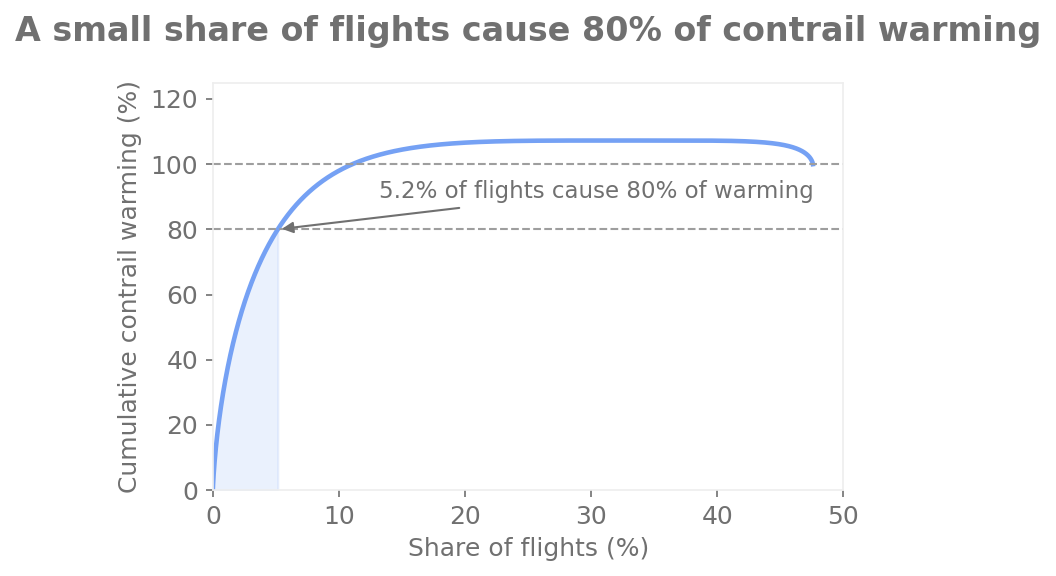

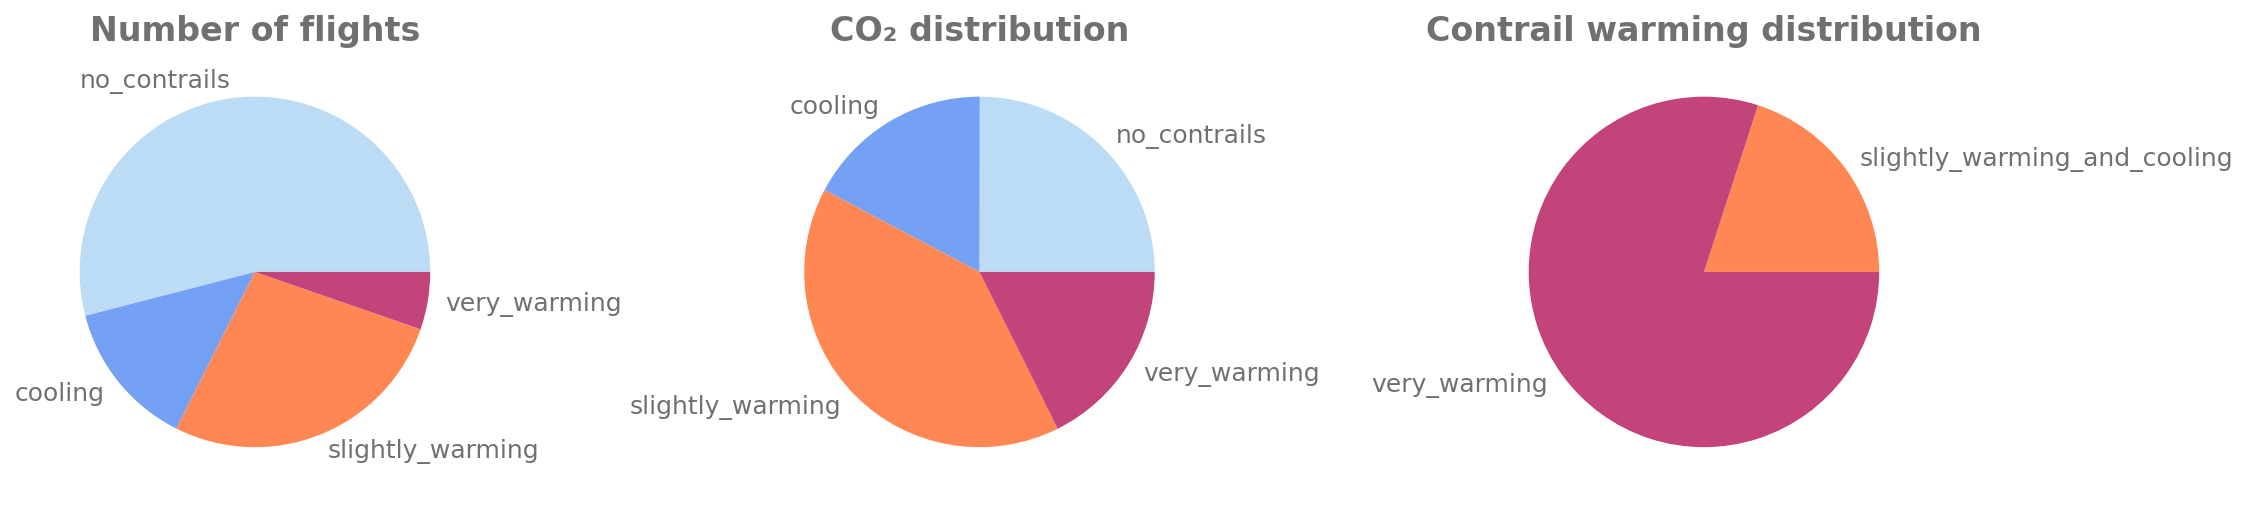

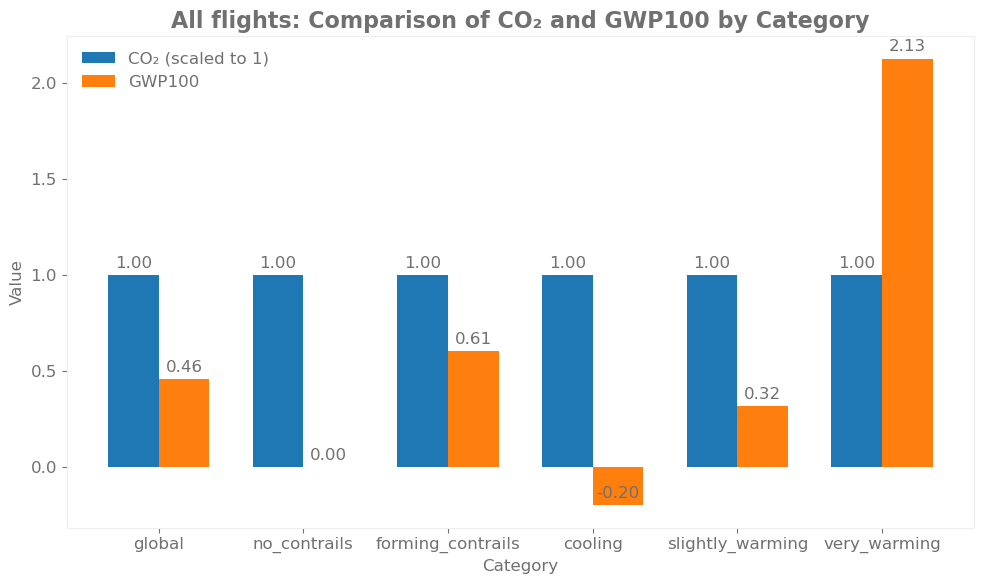

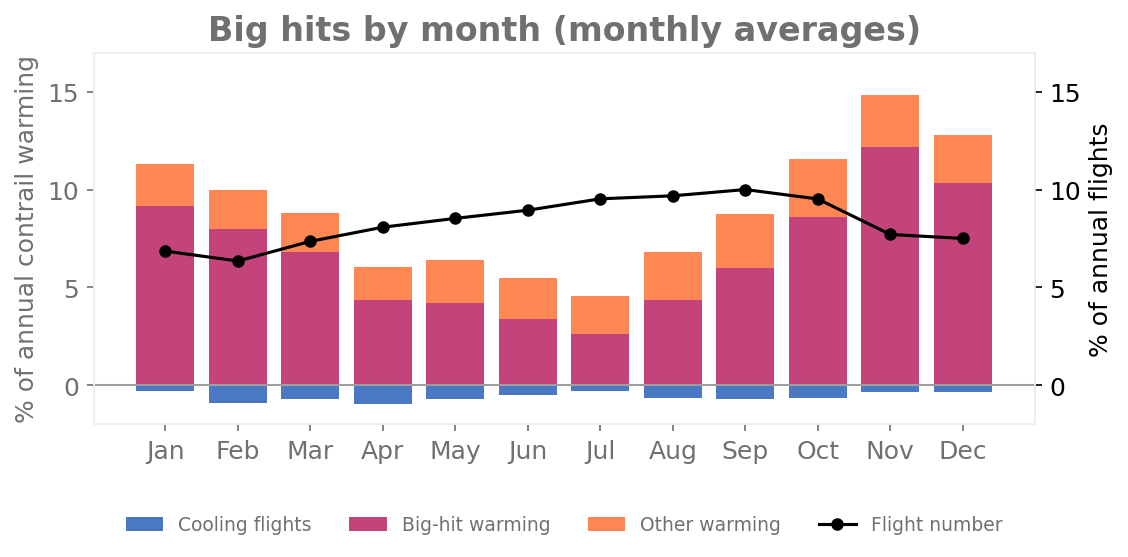

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23


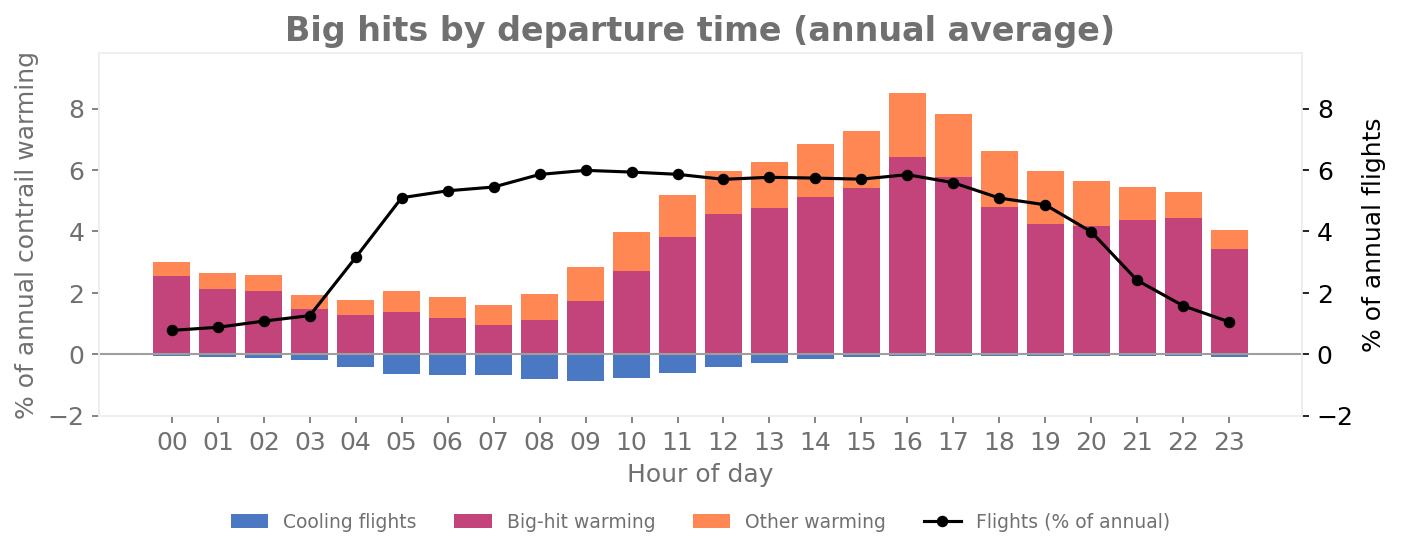

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:421: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_season"] = _df["_month"].map(season_map)
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:422: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

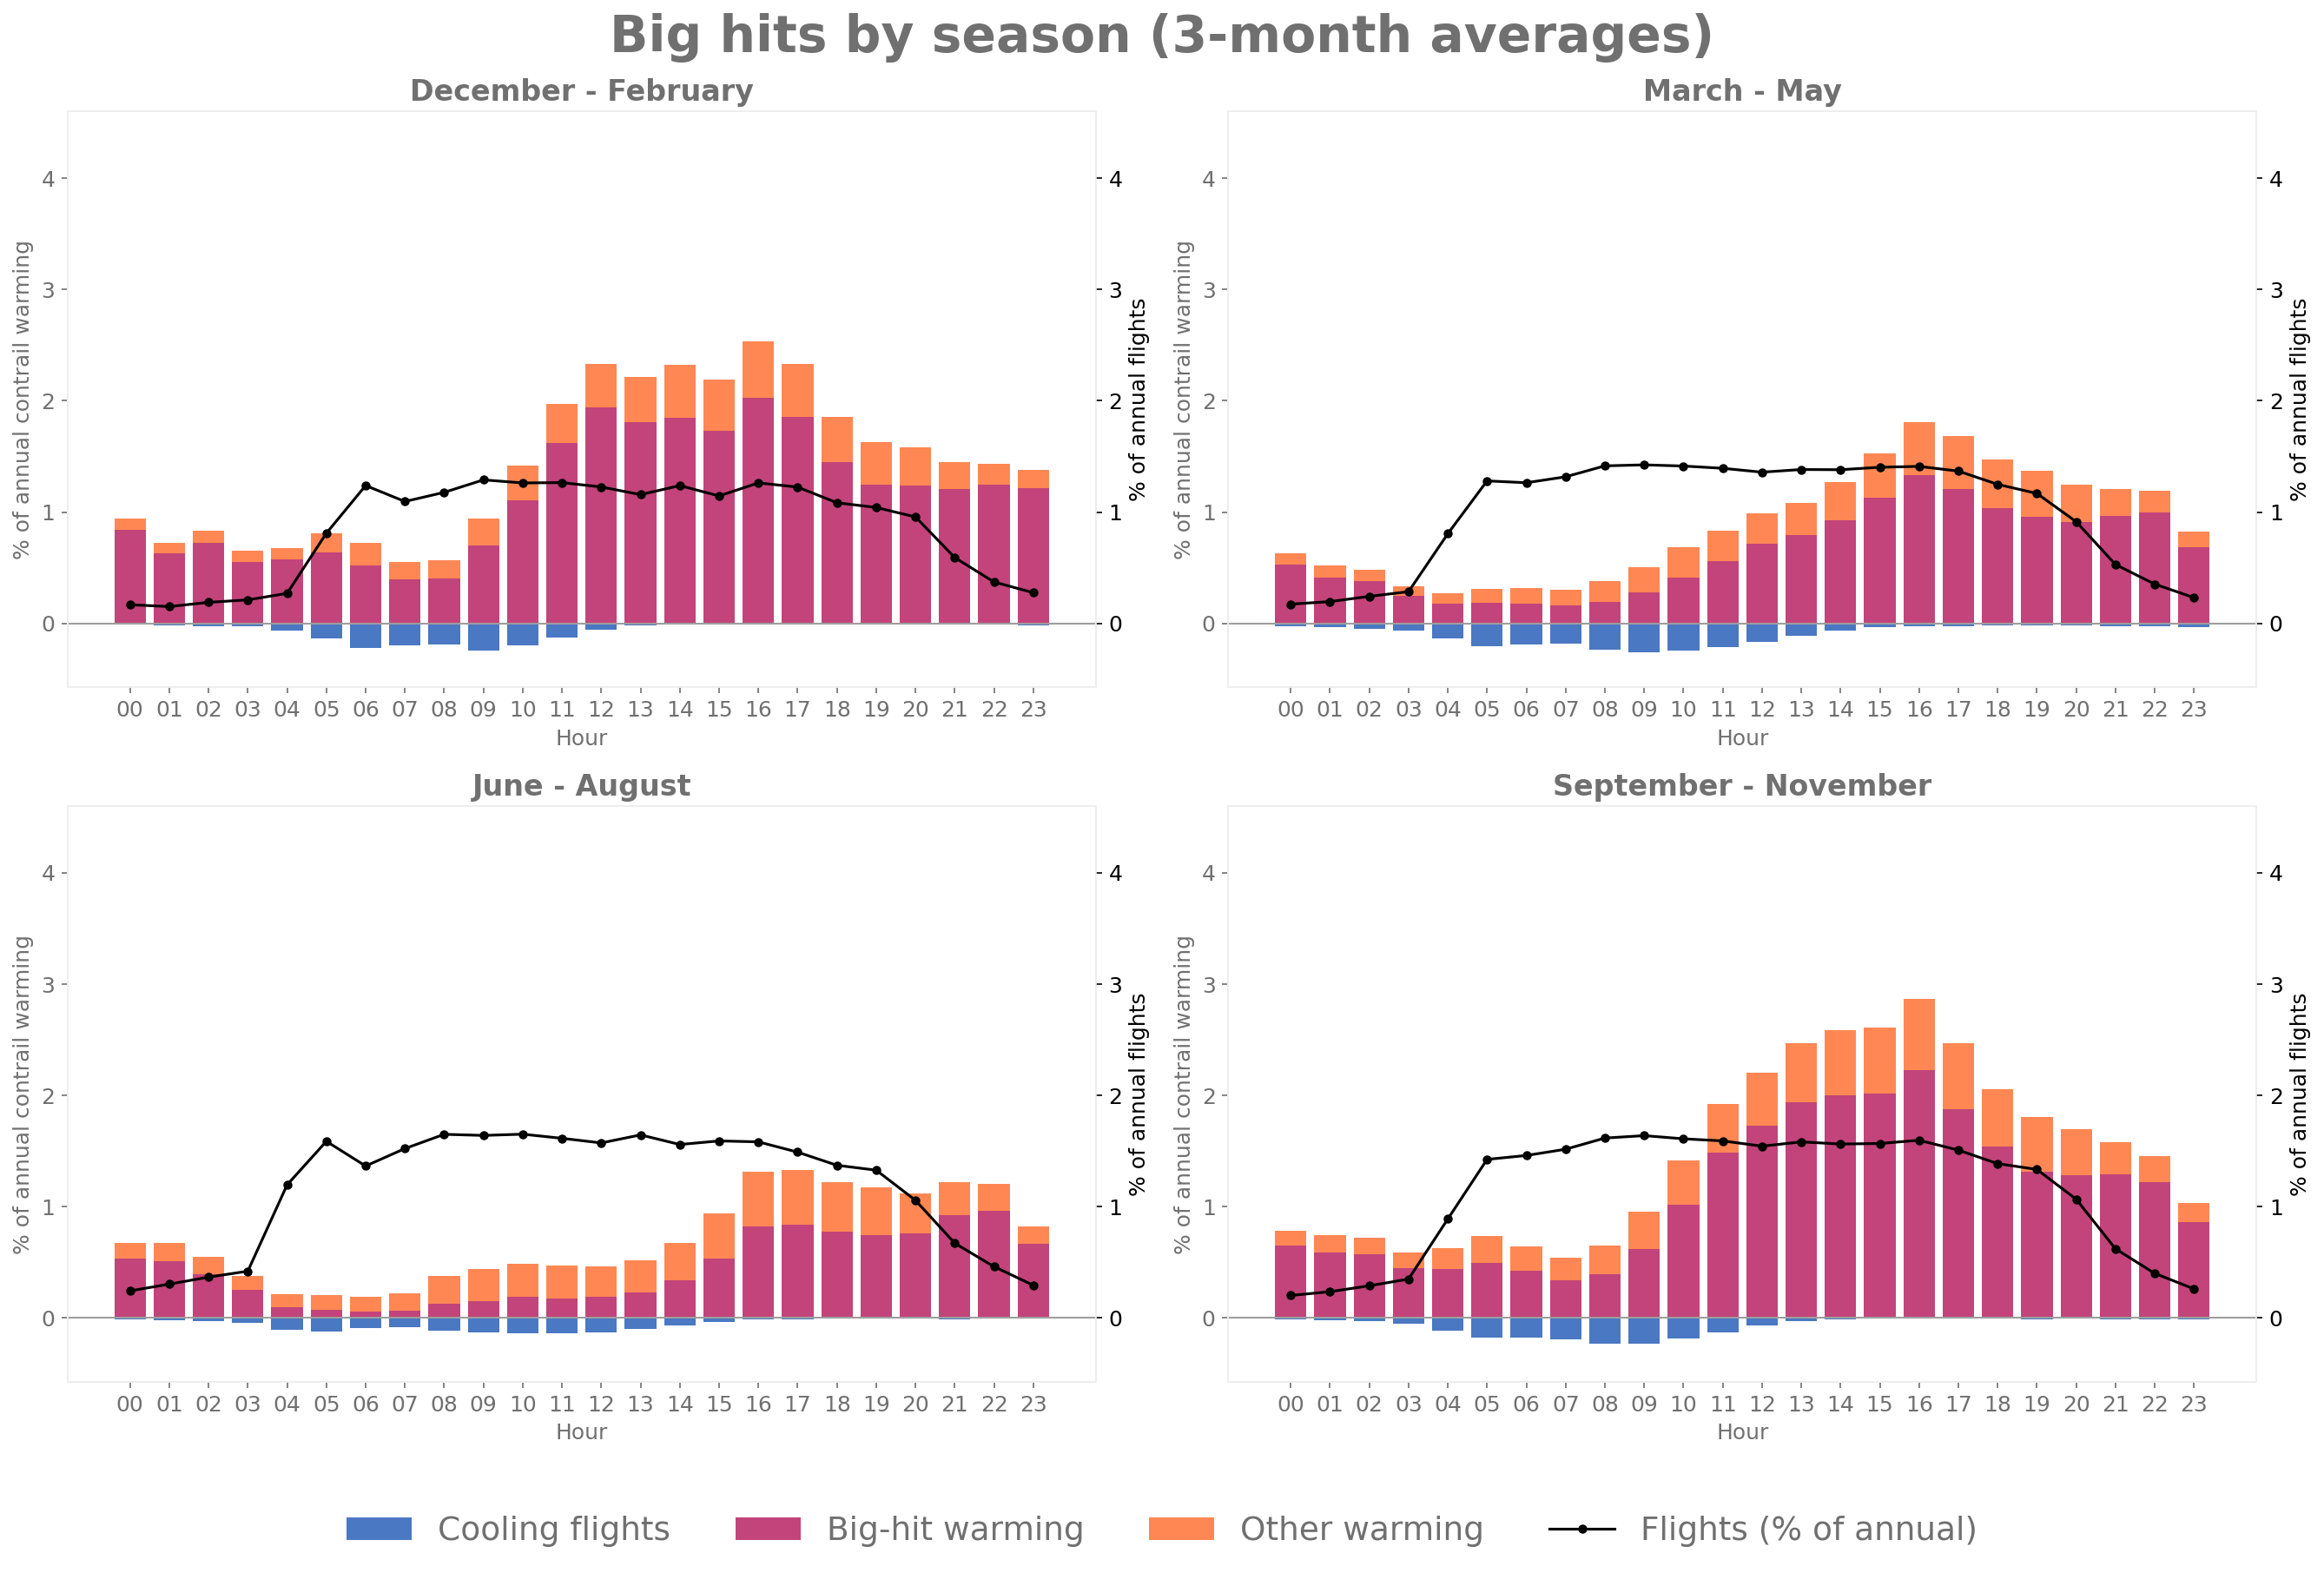

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:529: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"]  = _df[DATE_COL].dt.hour
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


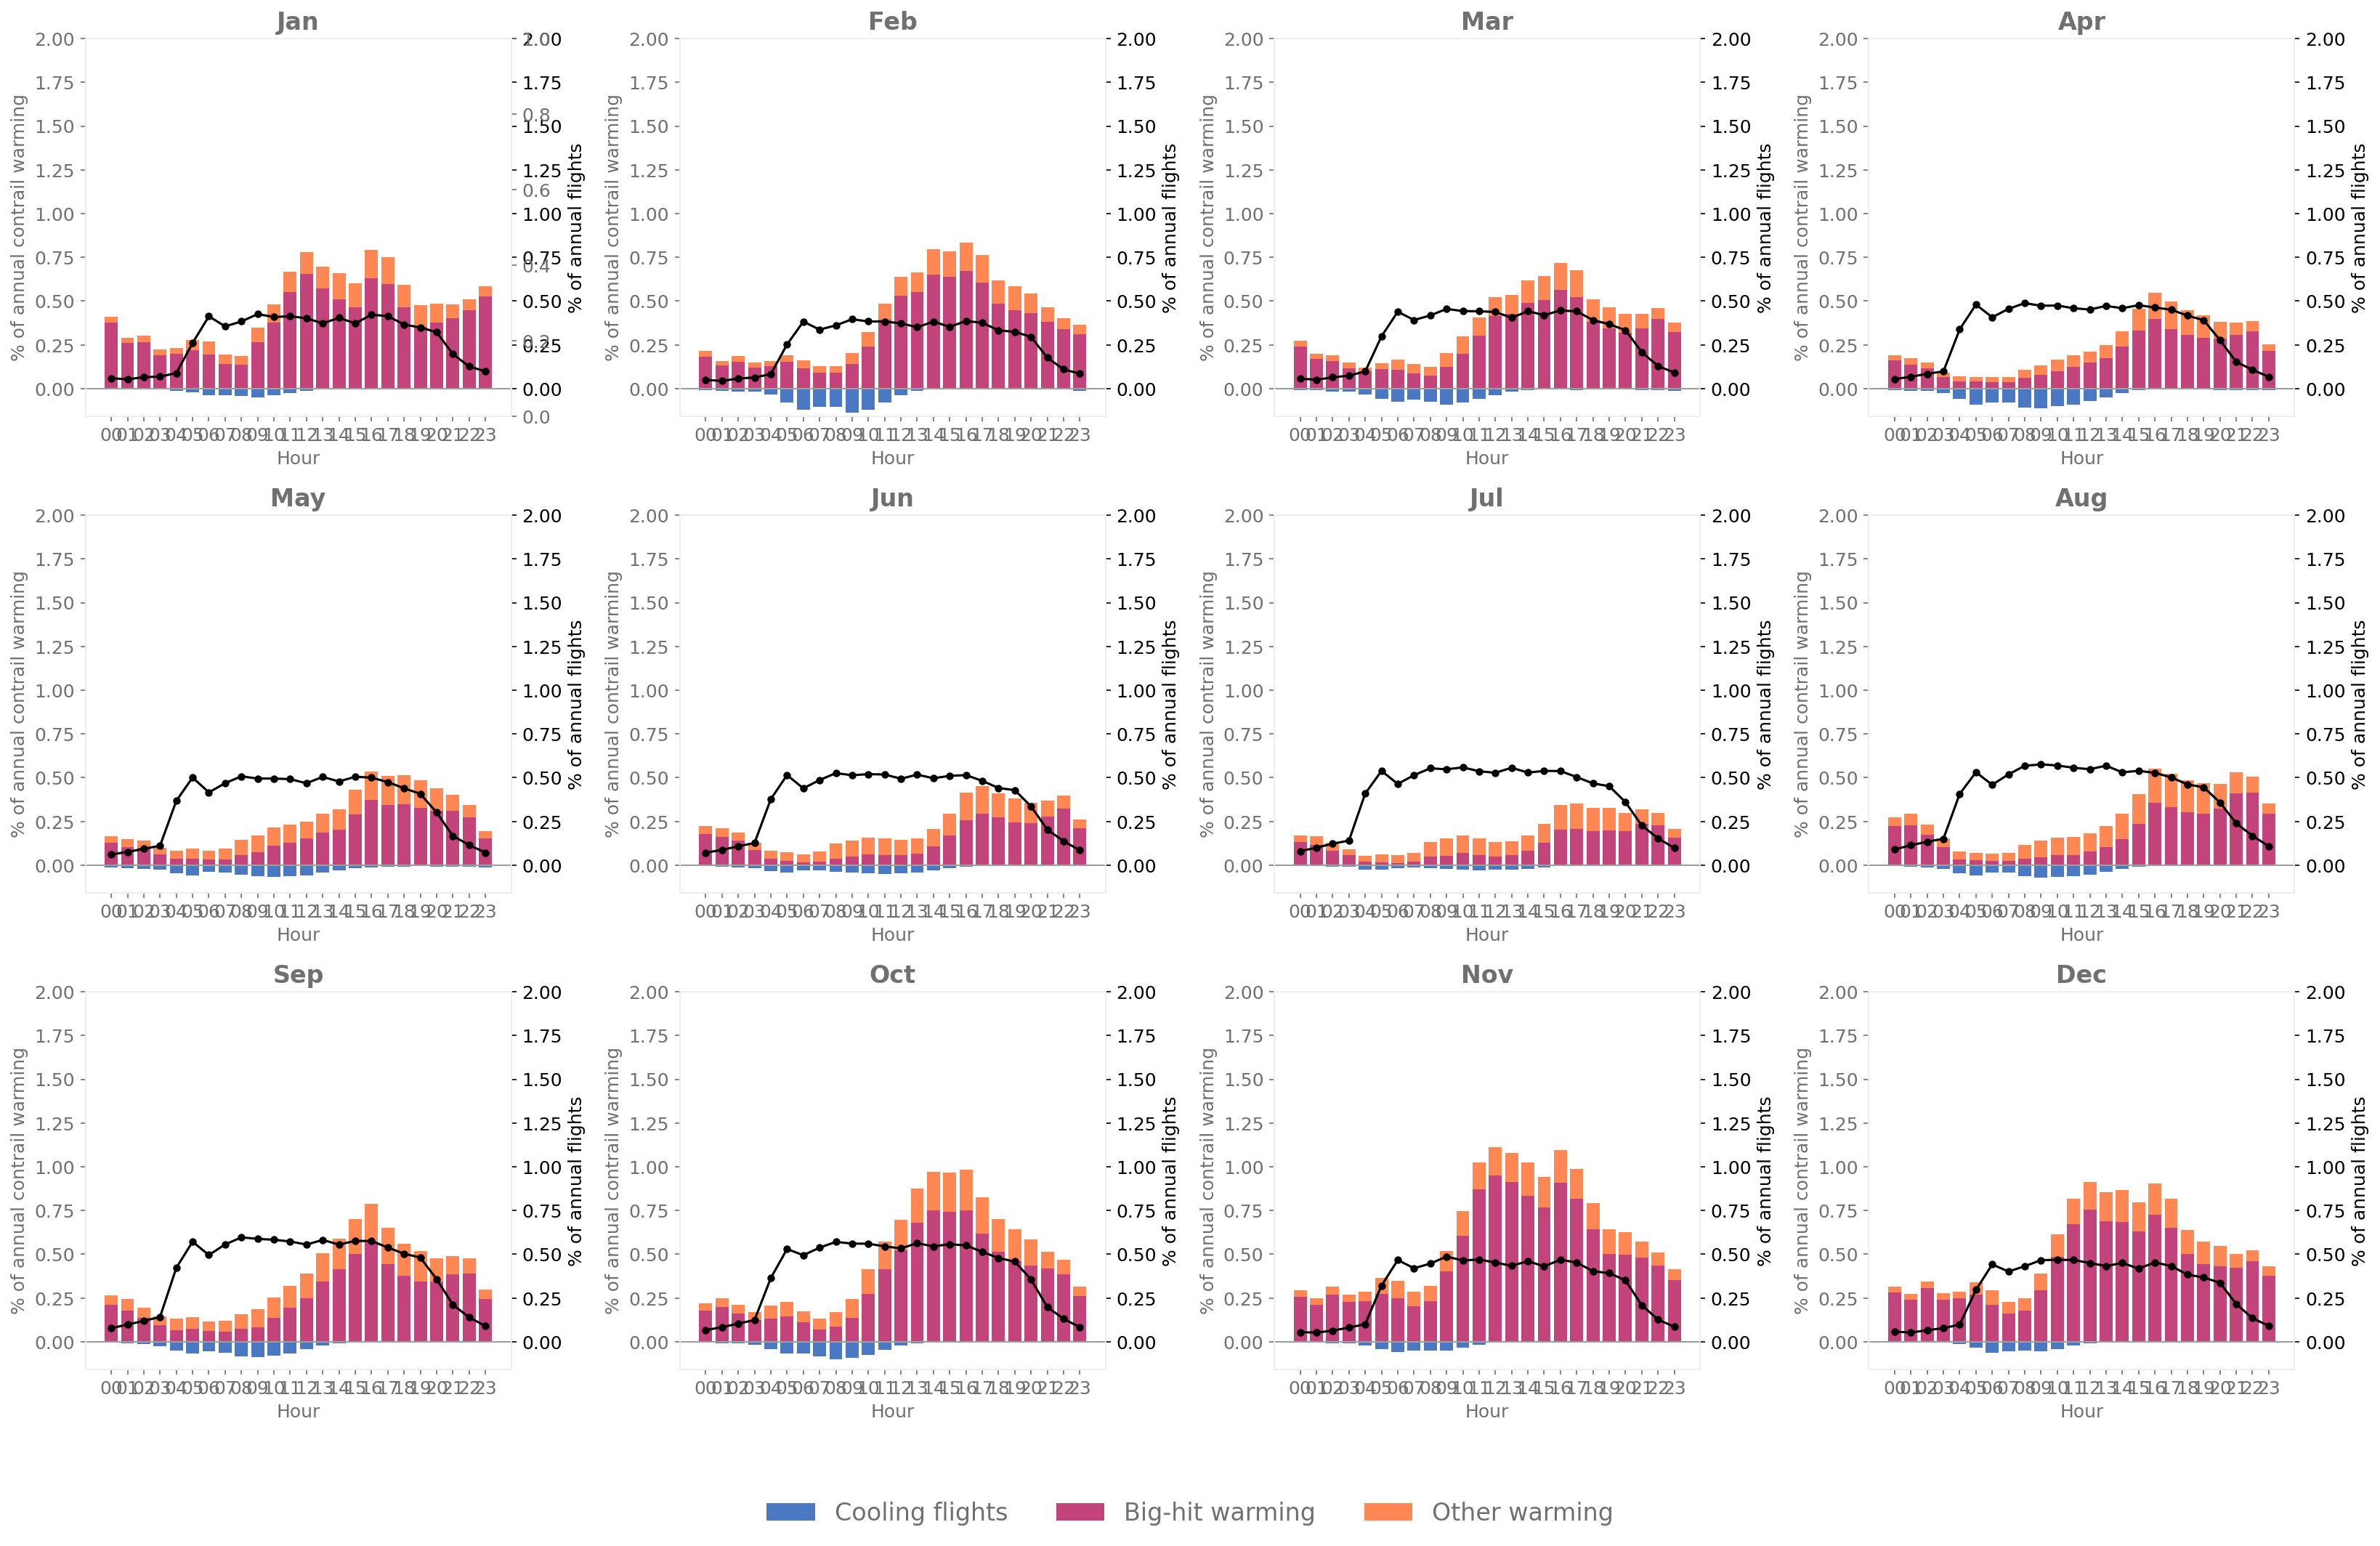

In [16]:
plot_contrail_distribution(df)

## European departures

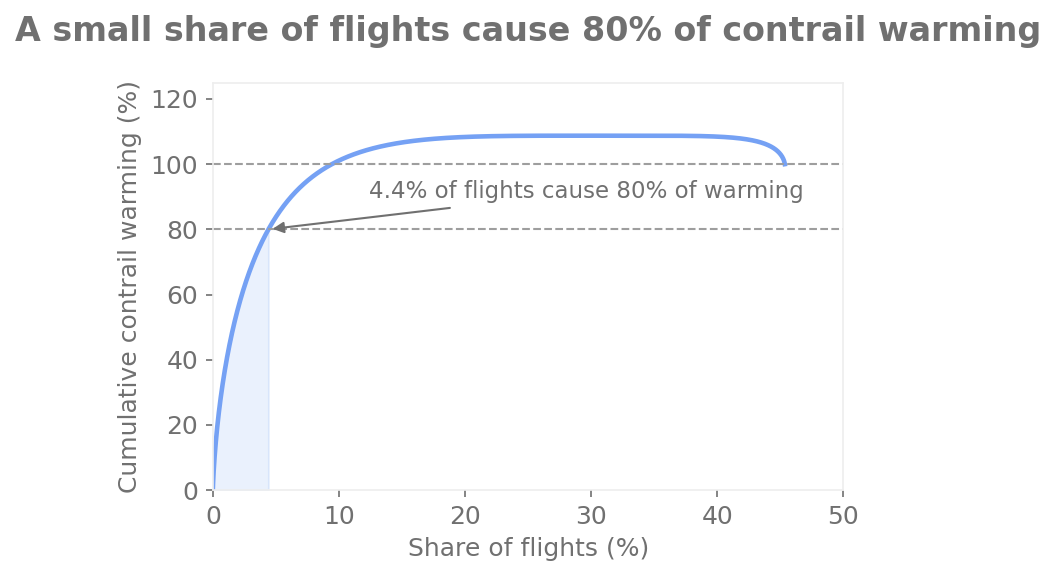

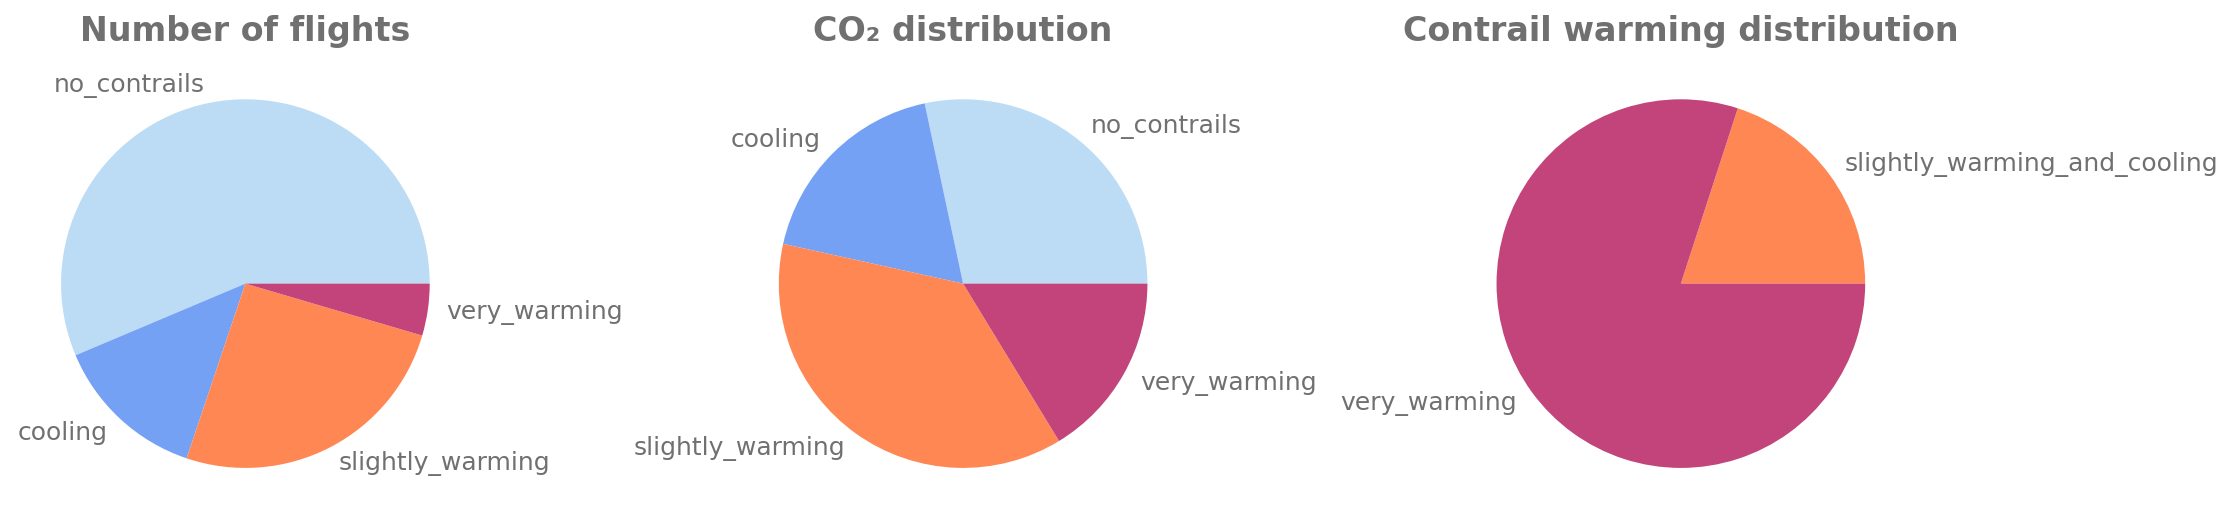

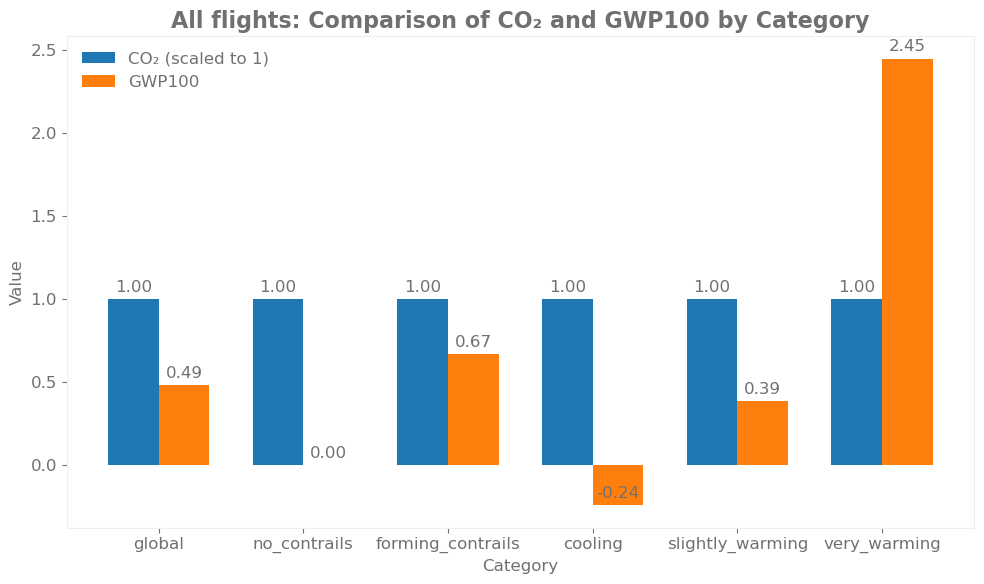

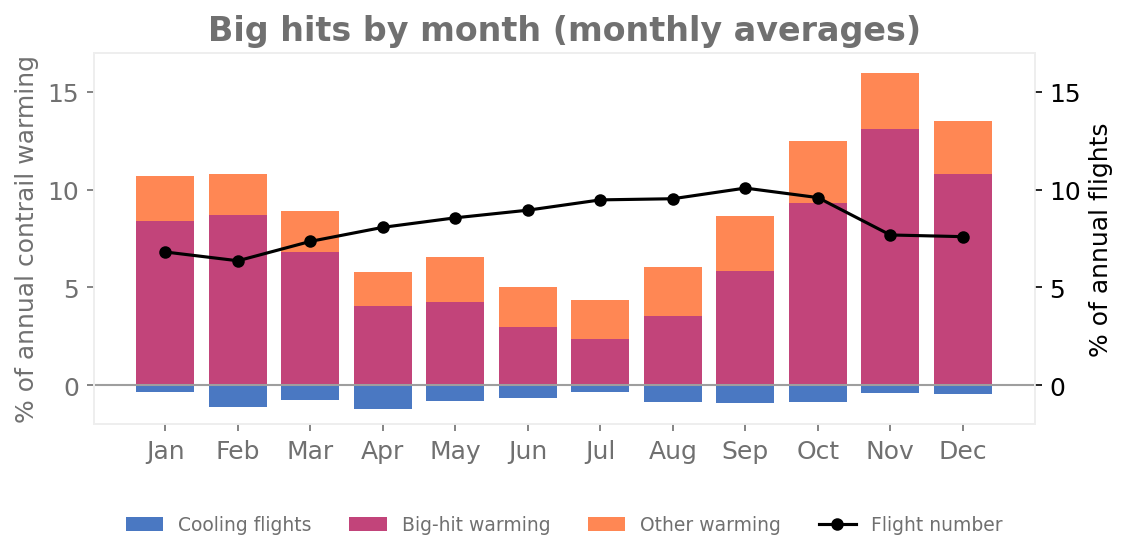

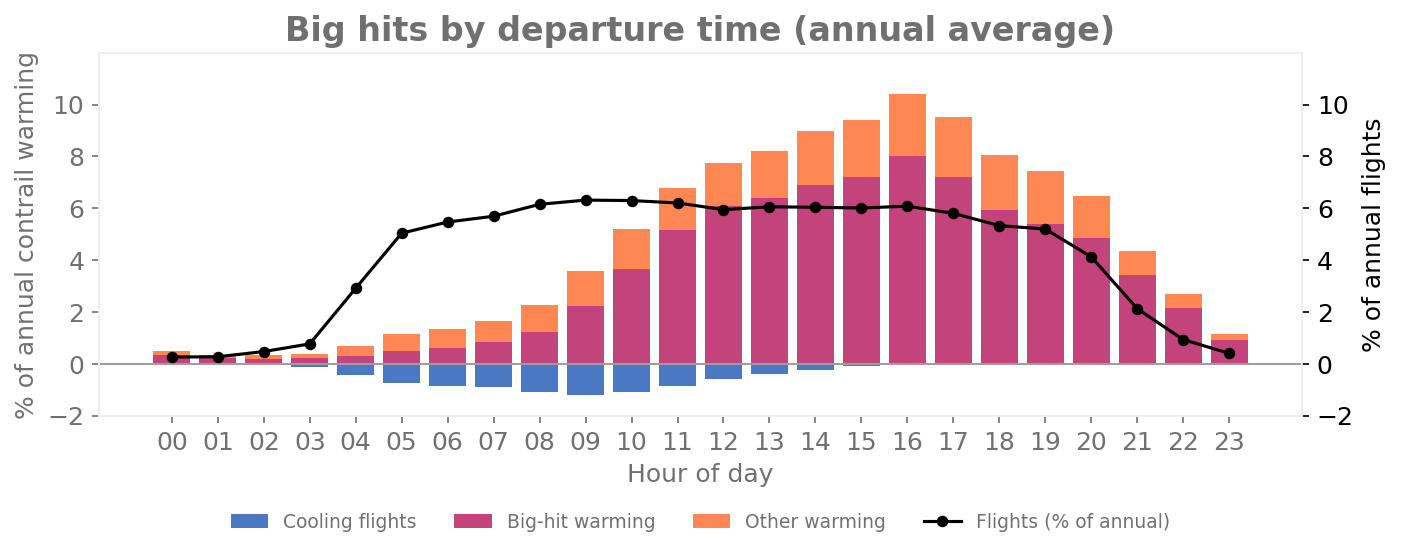

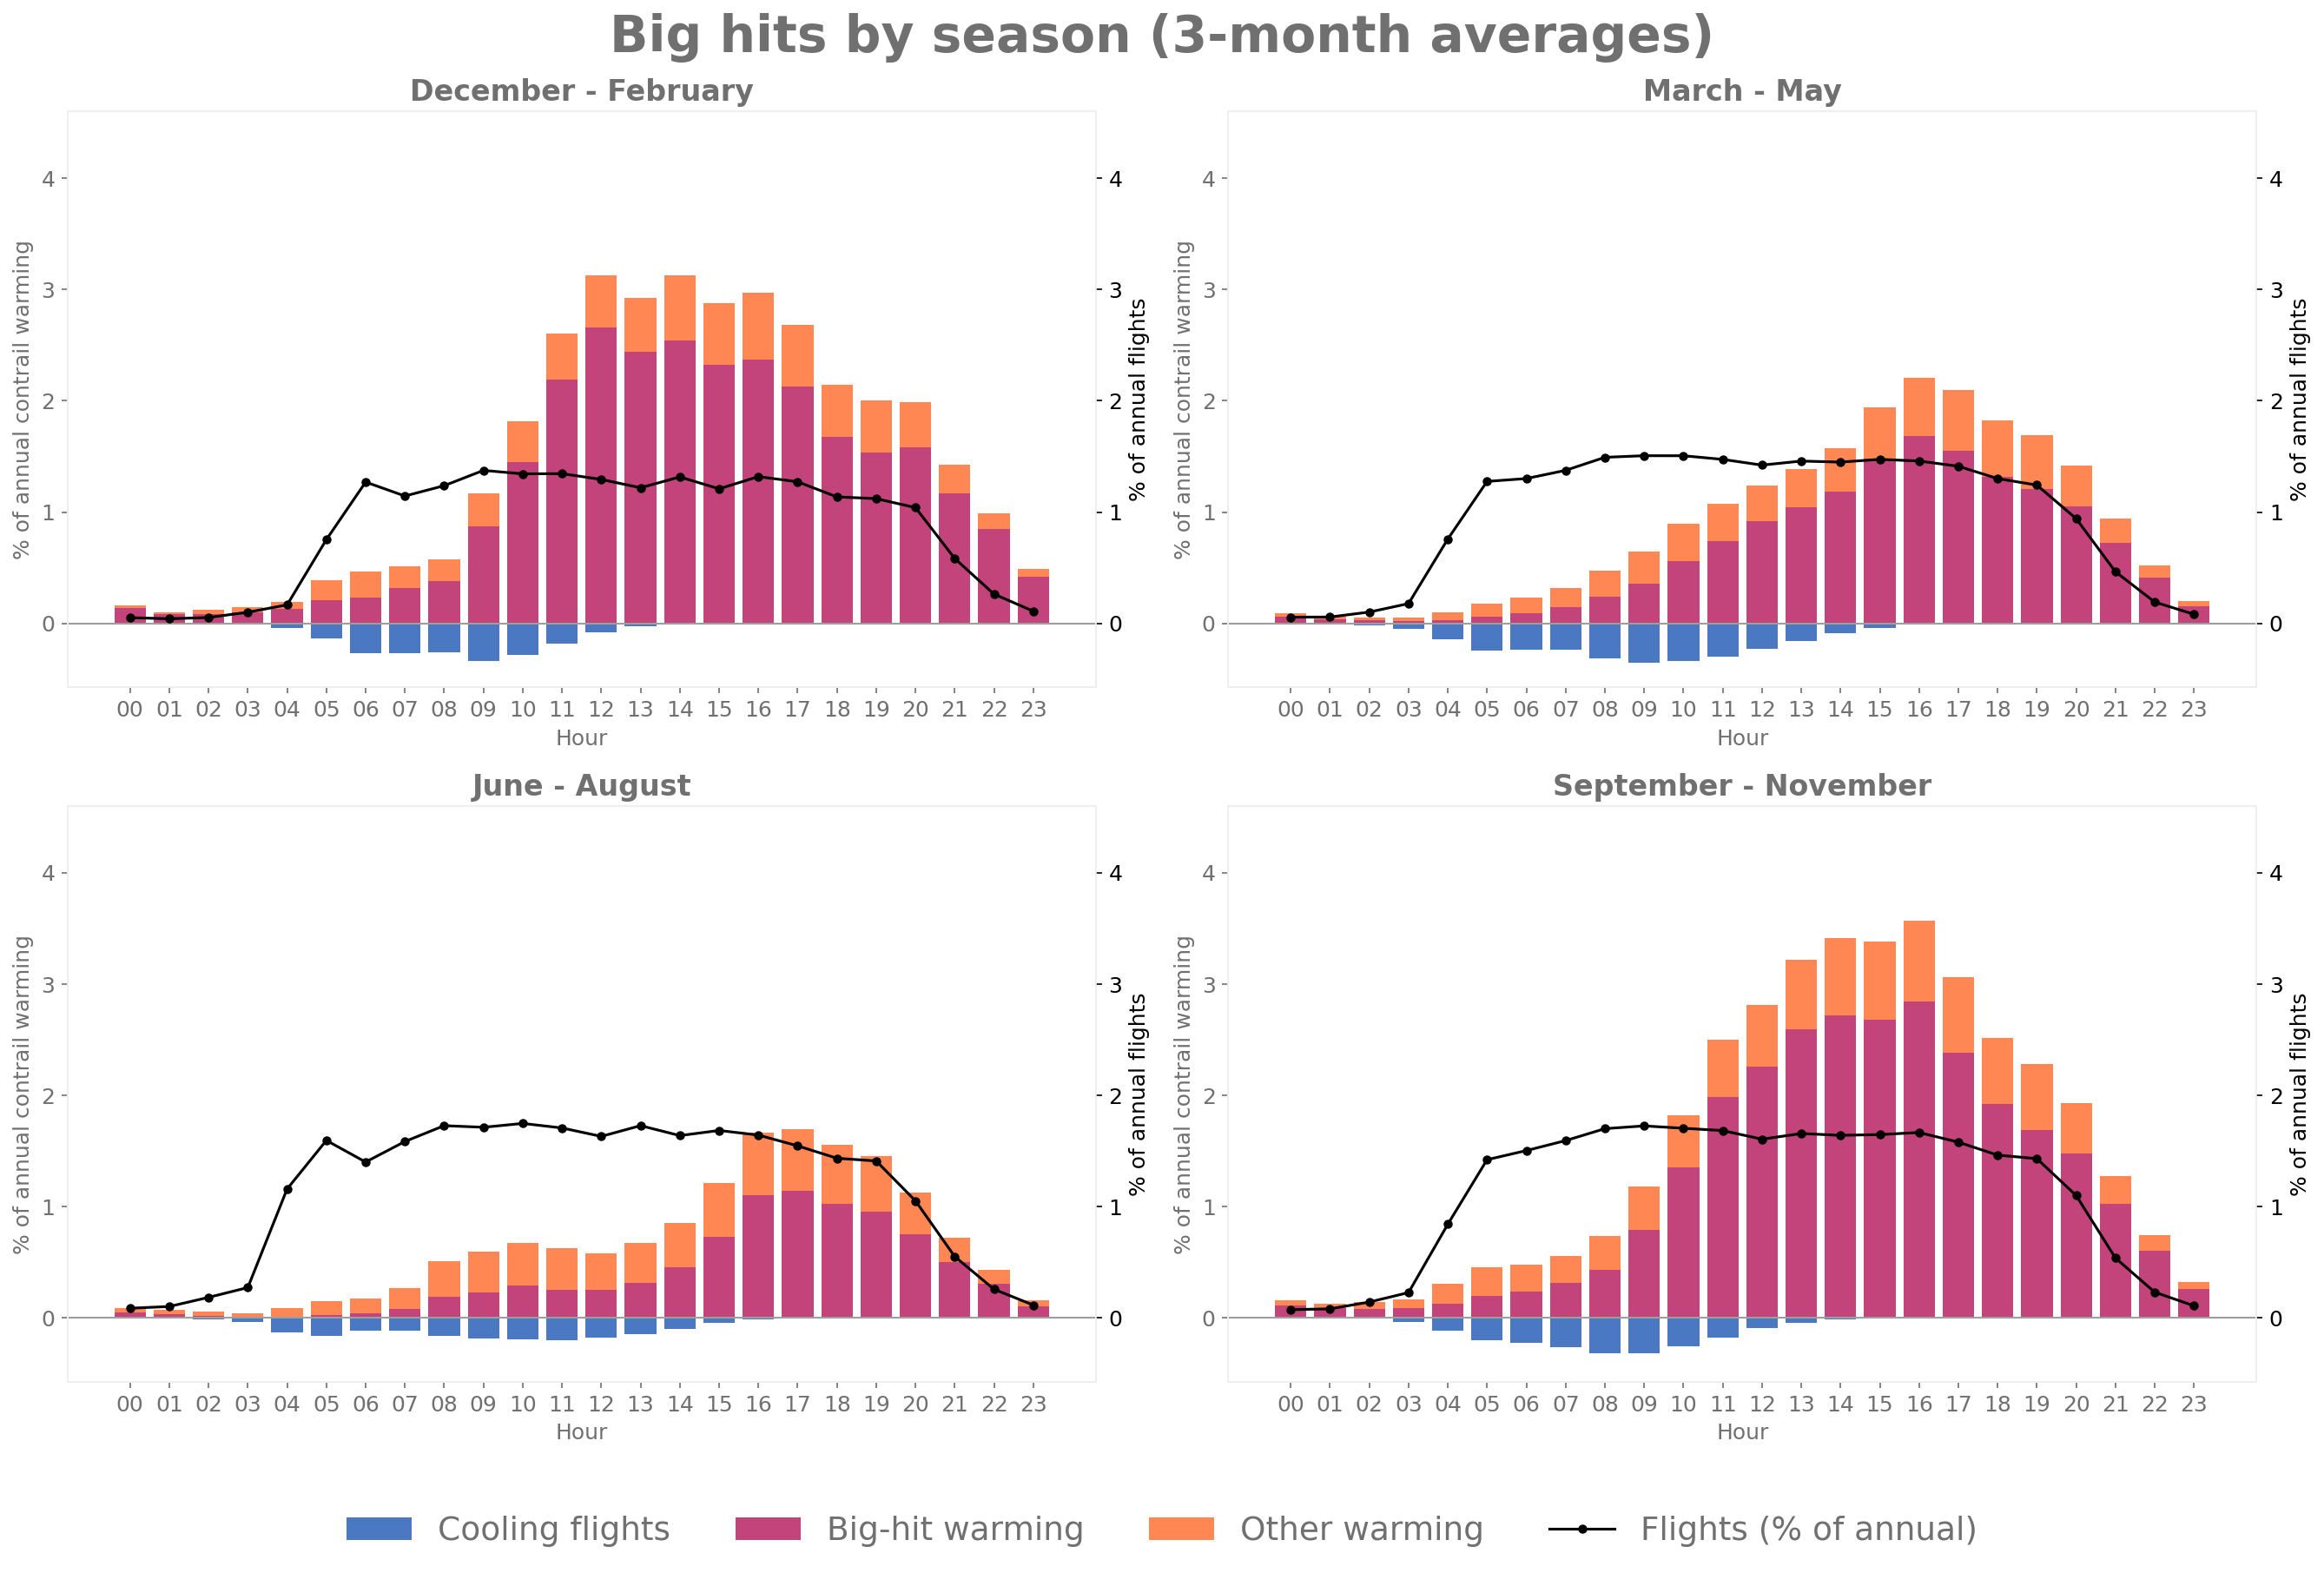

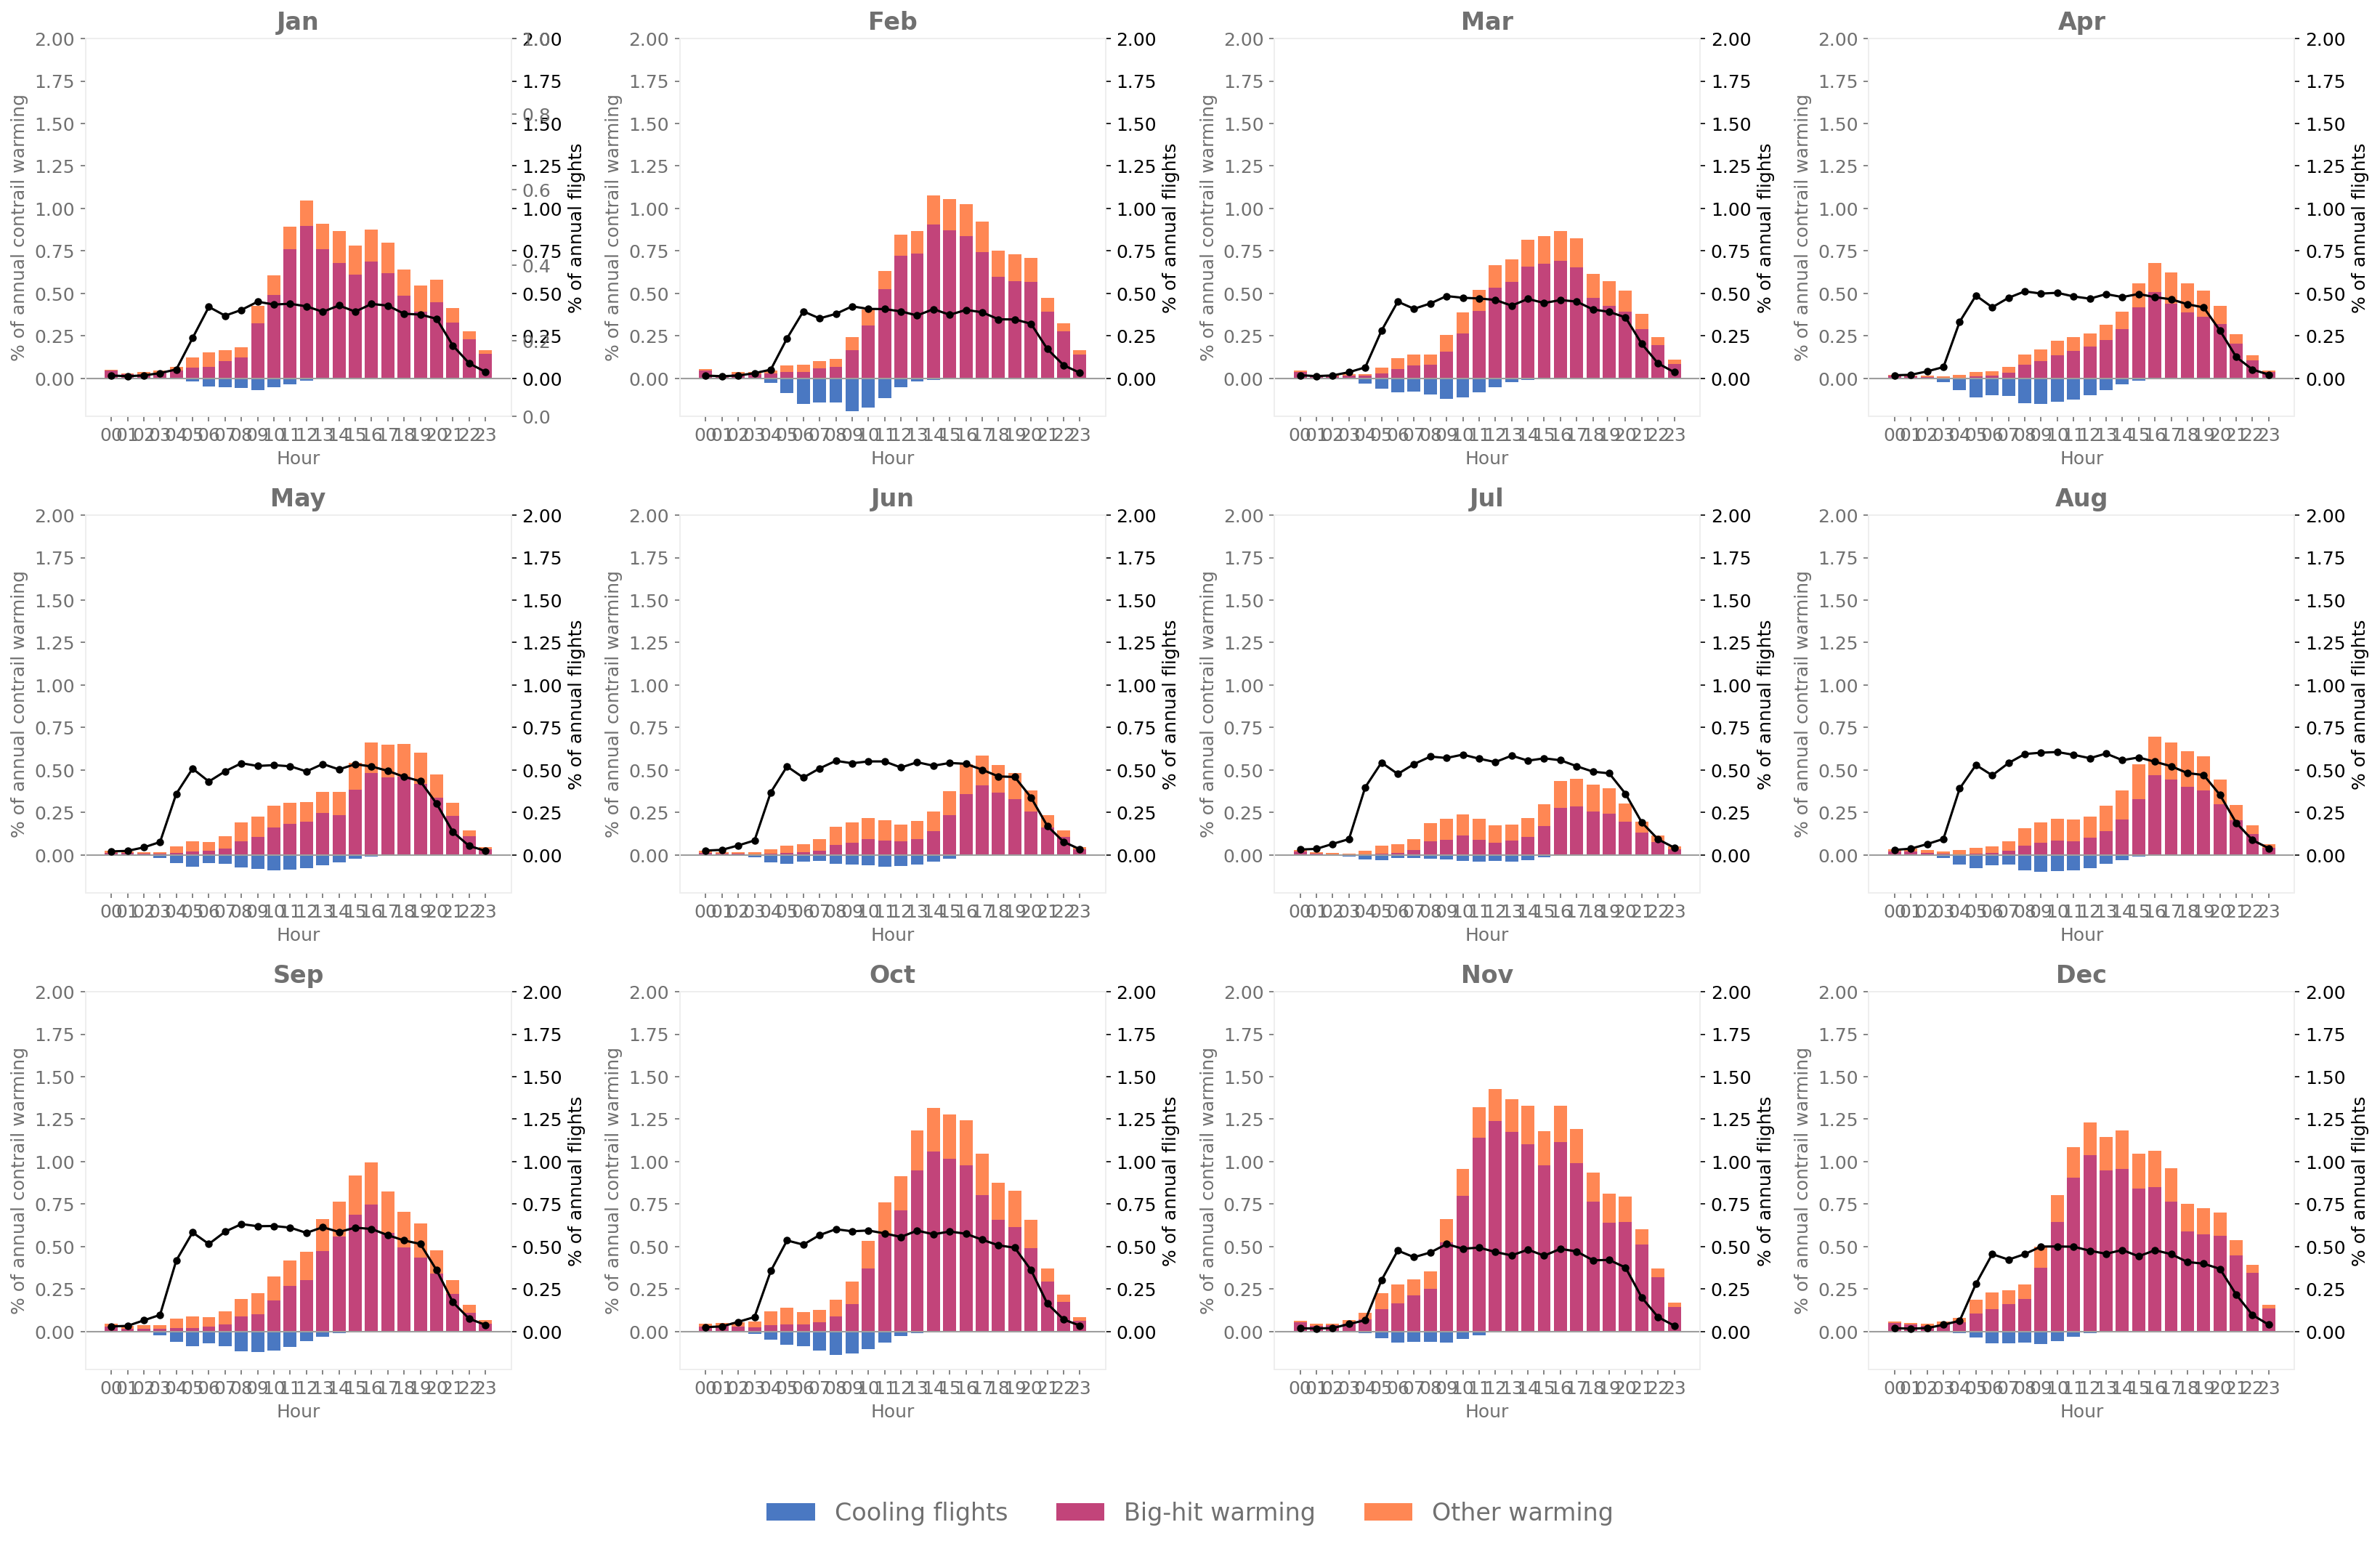

In [10]:
plot_contrail_distribution(df[df["origin_region"] == "Europe"])



## Germany

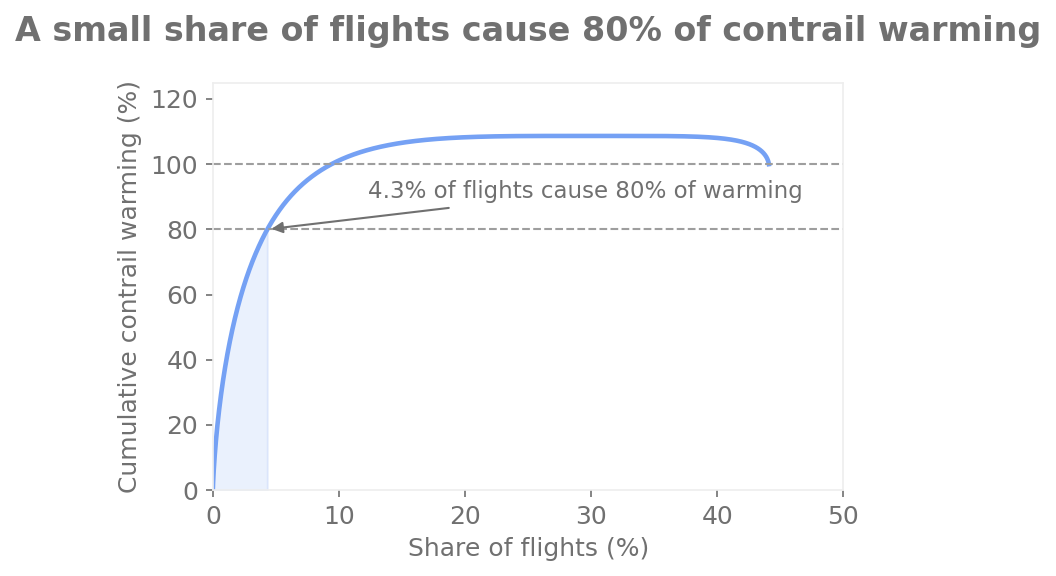

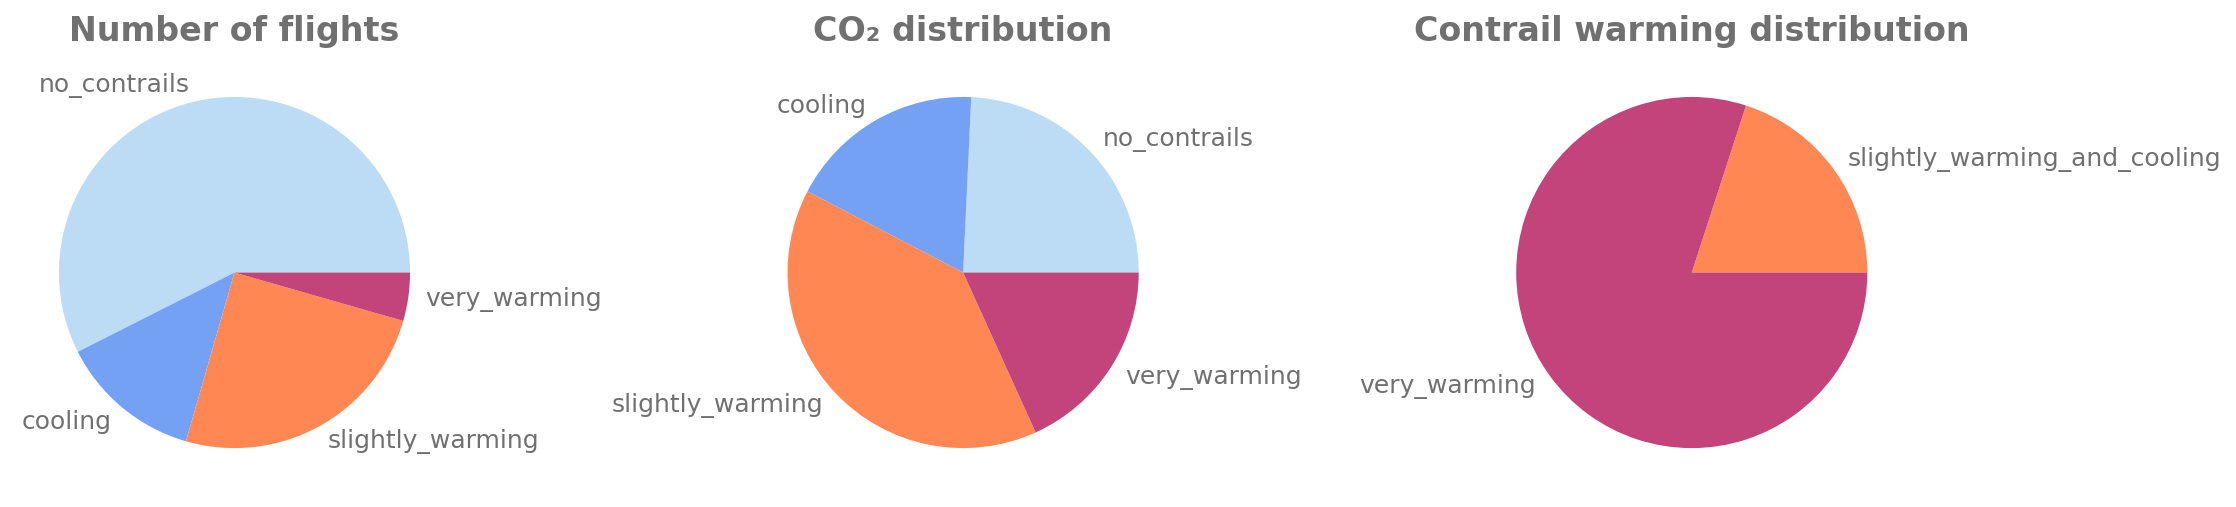

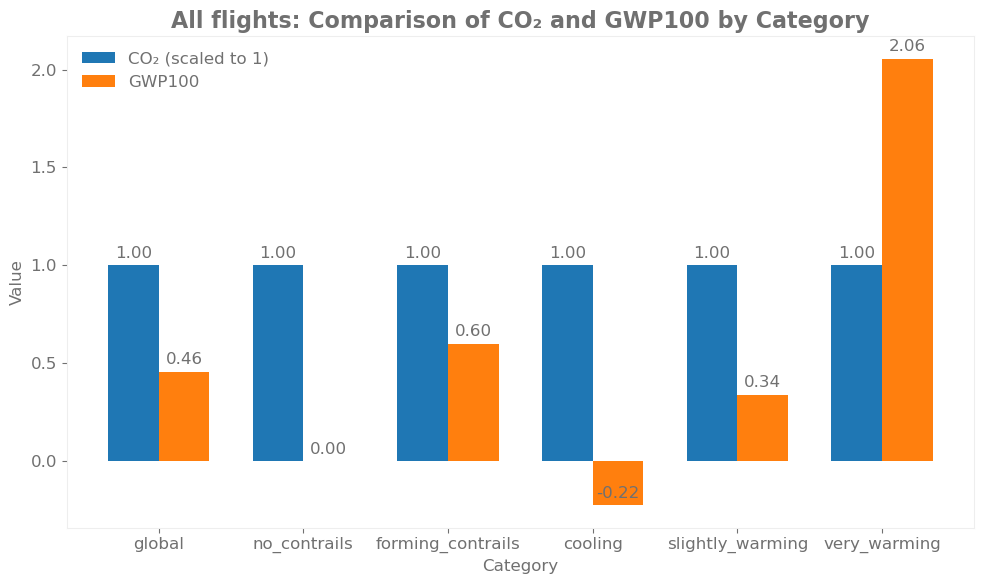

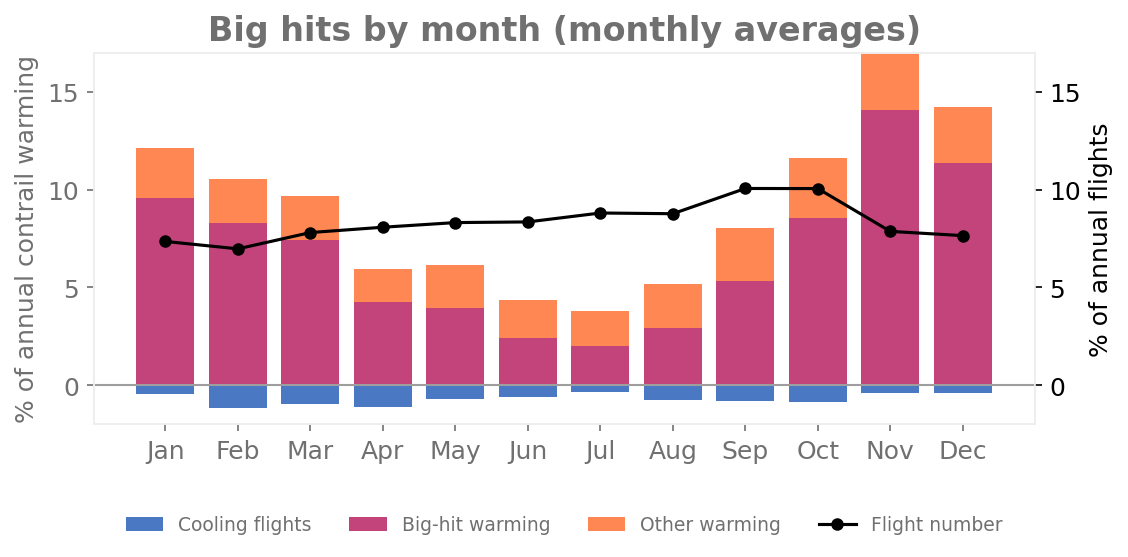

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

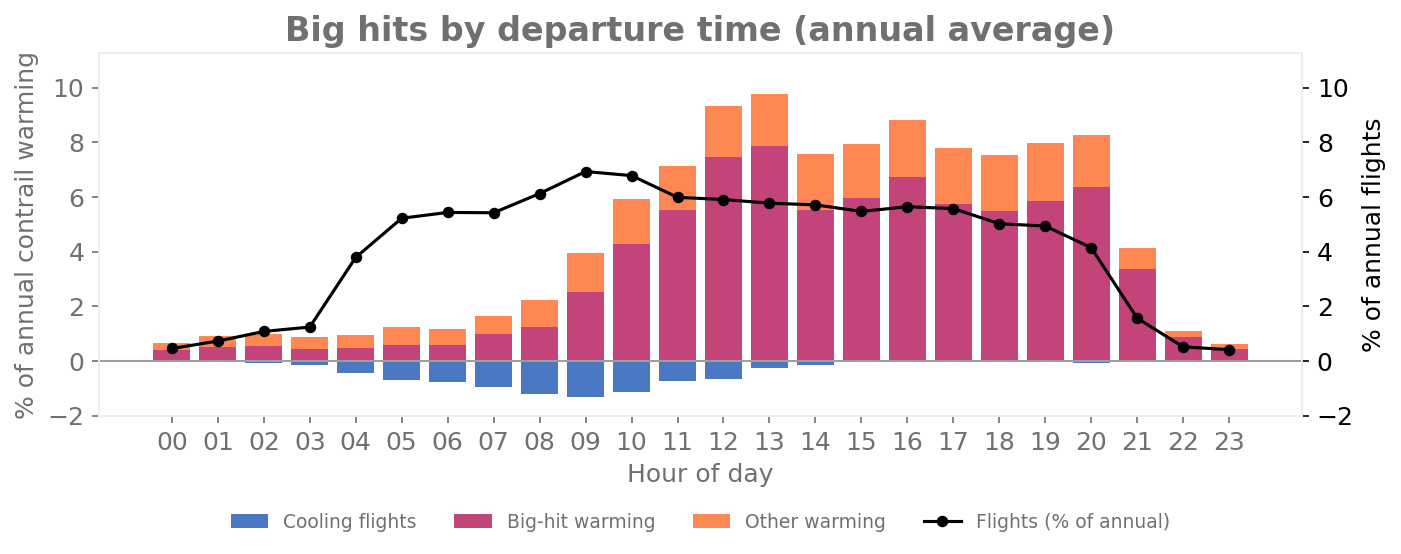

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:421: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_season"] = _df["_month"].map(season_map)
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:422: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

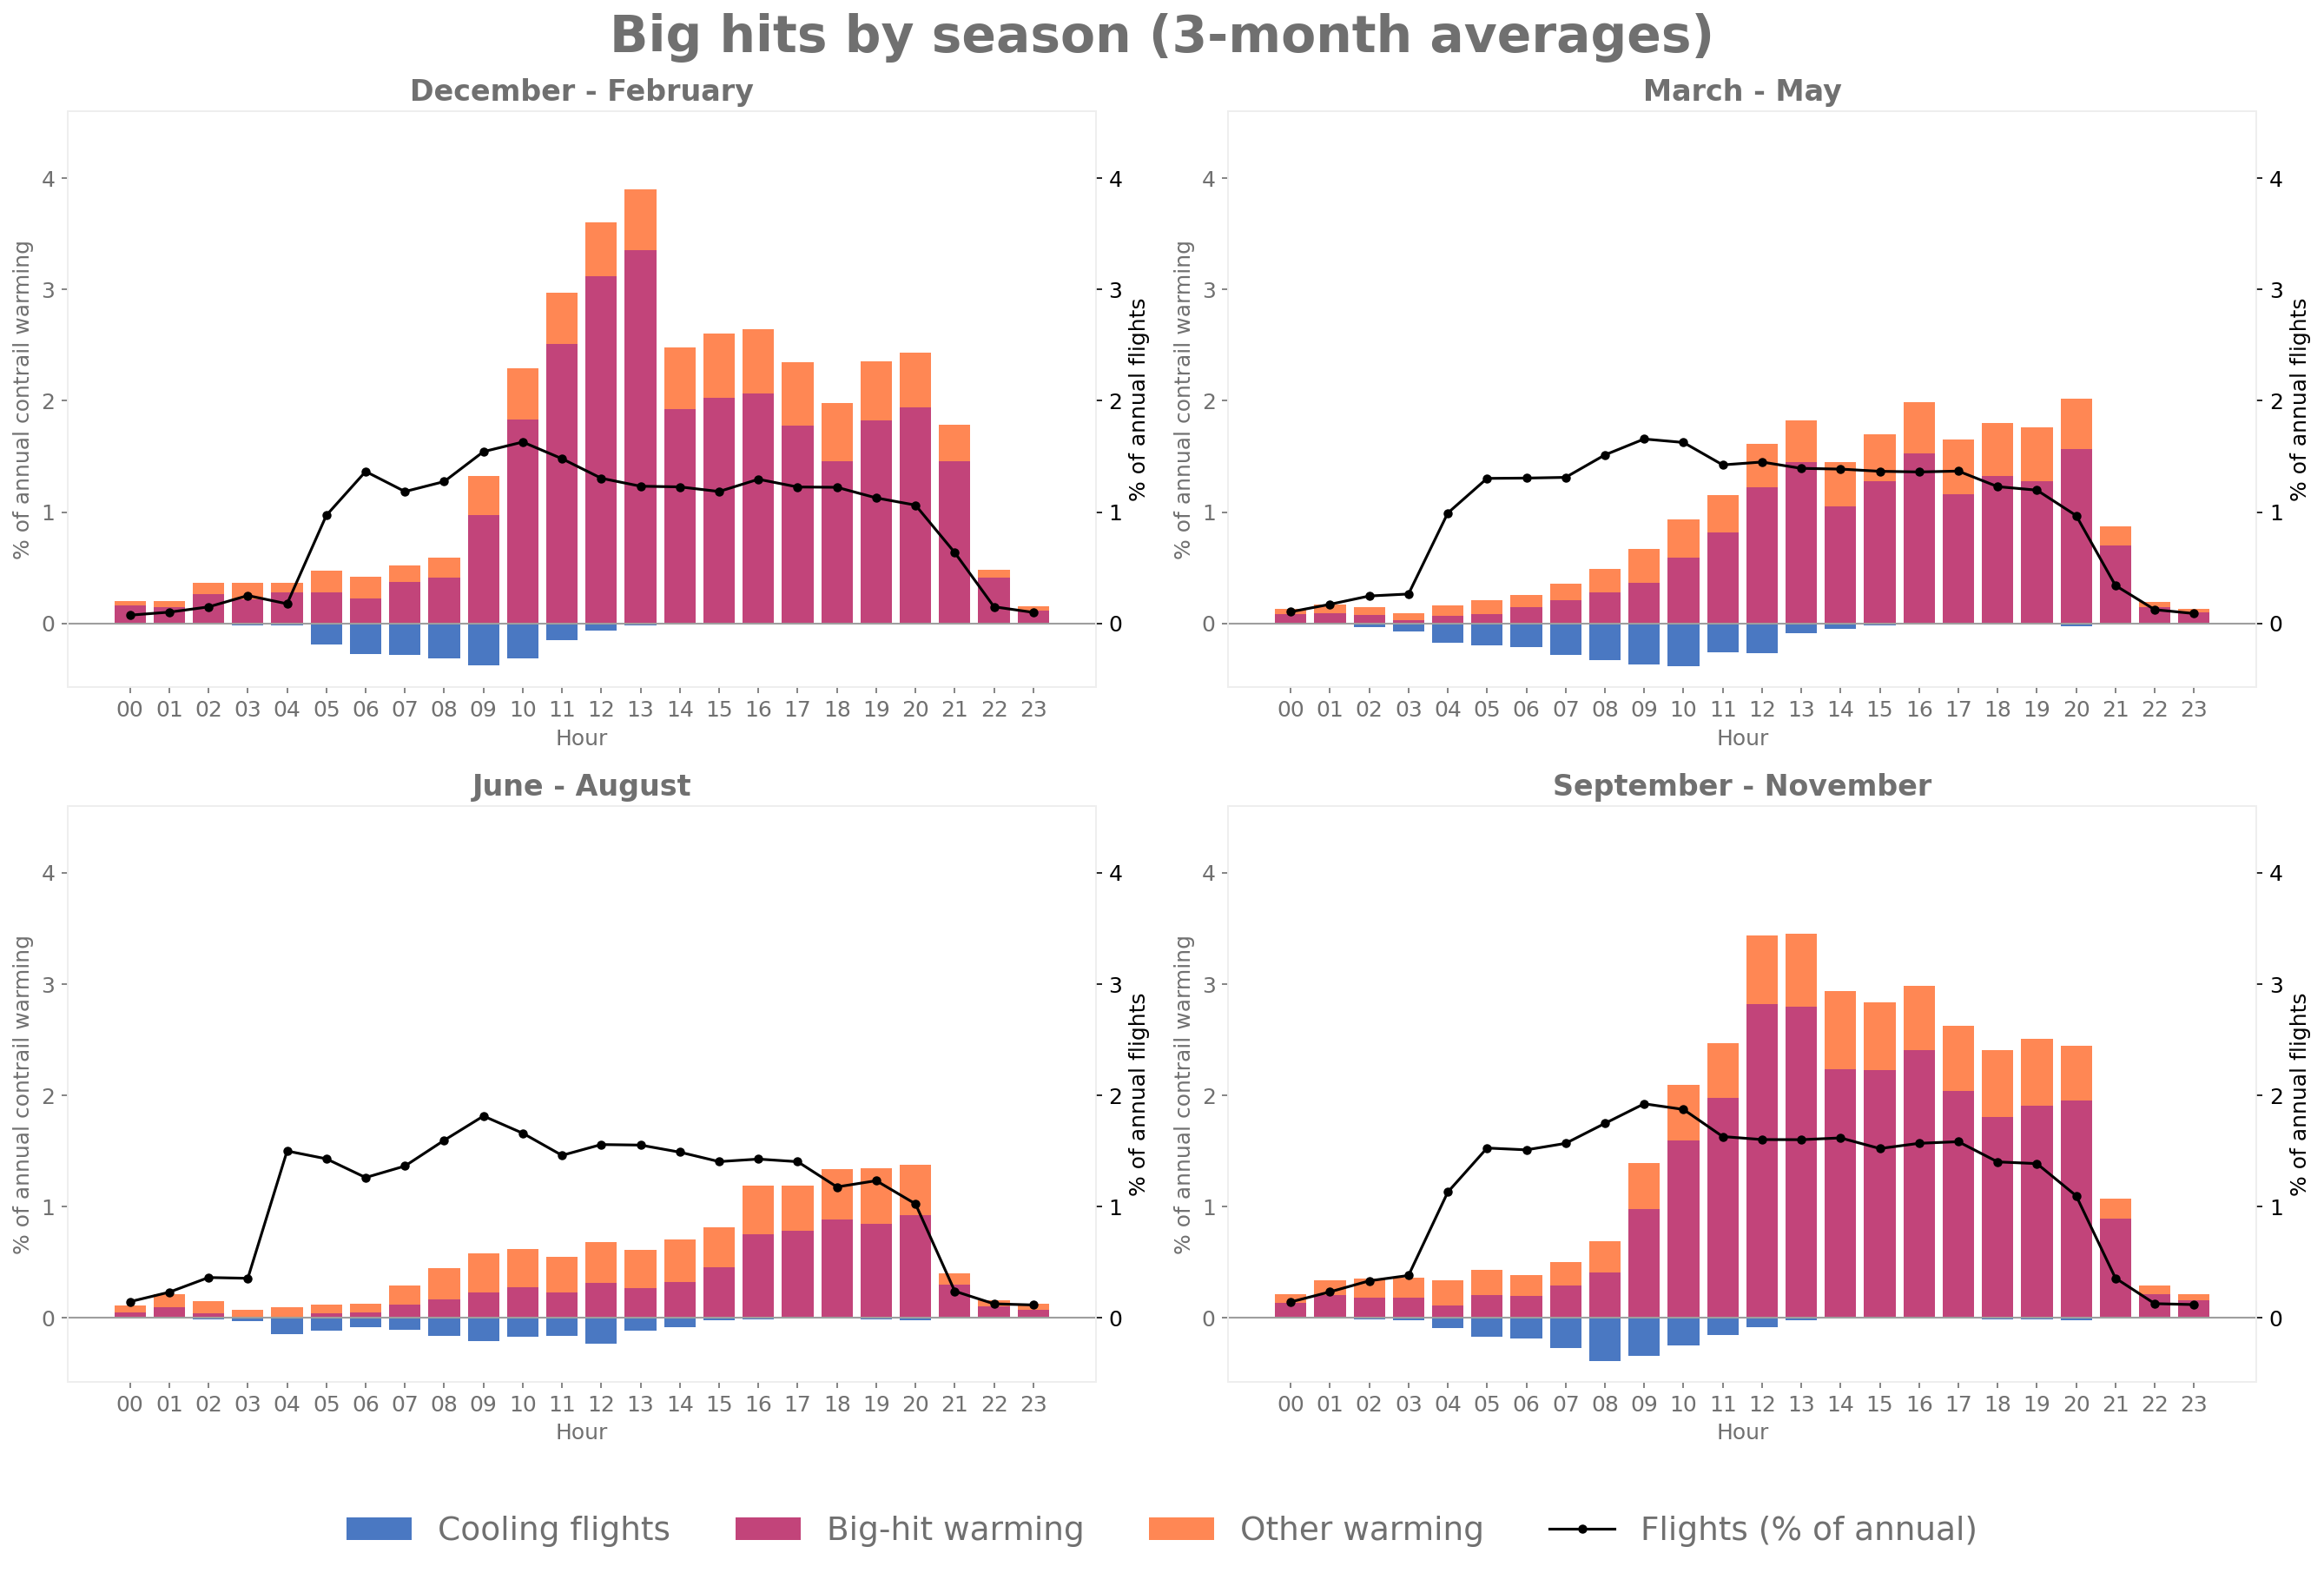

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:529: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"]  = _df[DATE_COL].dt.hour
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


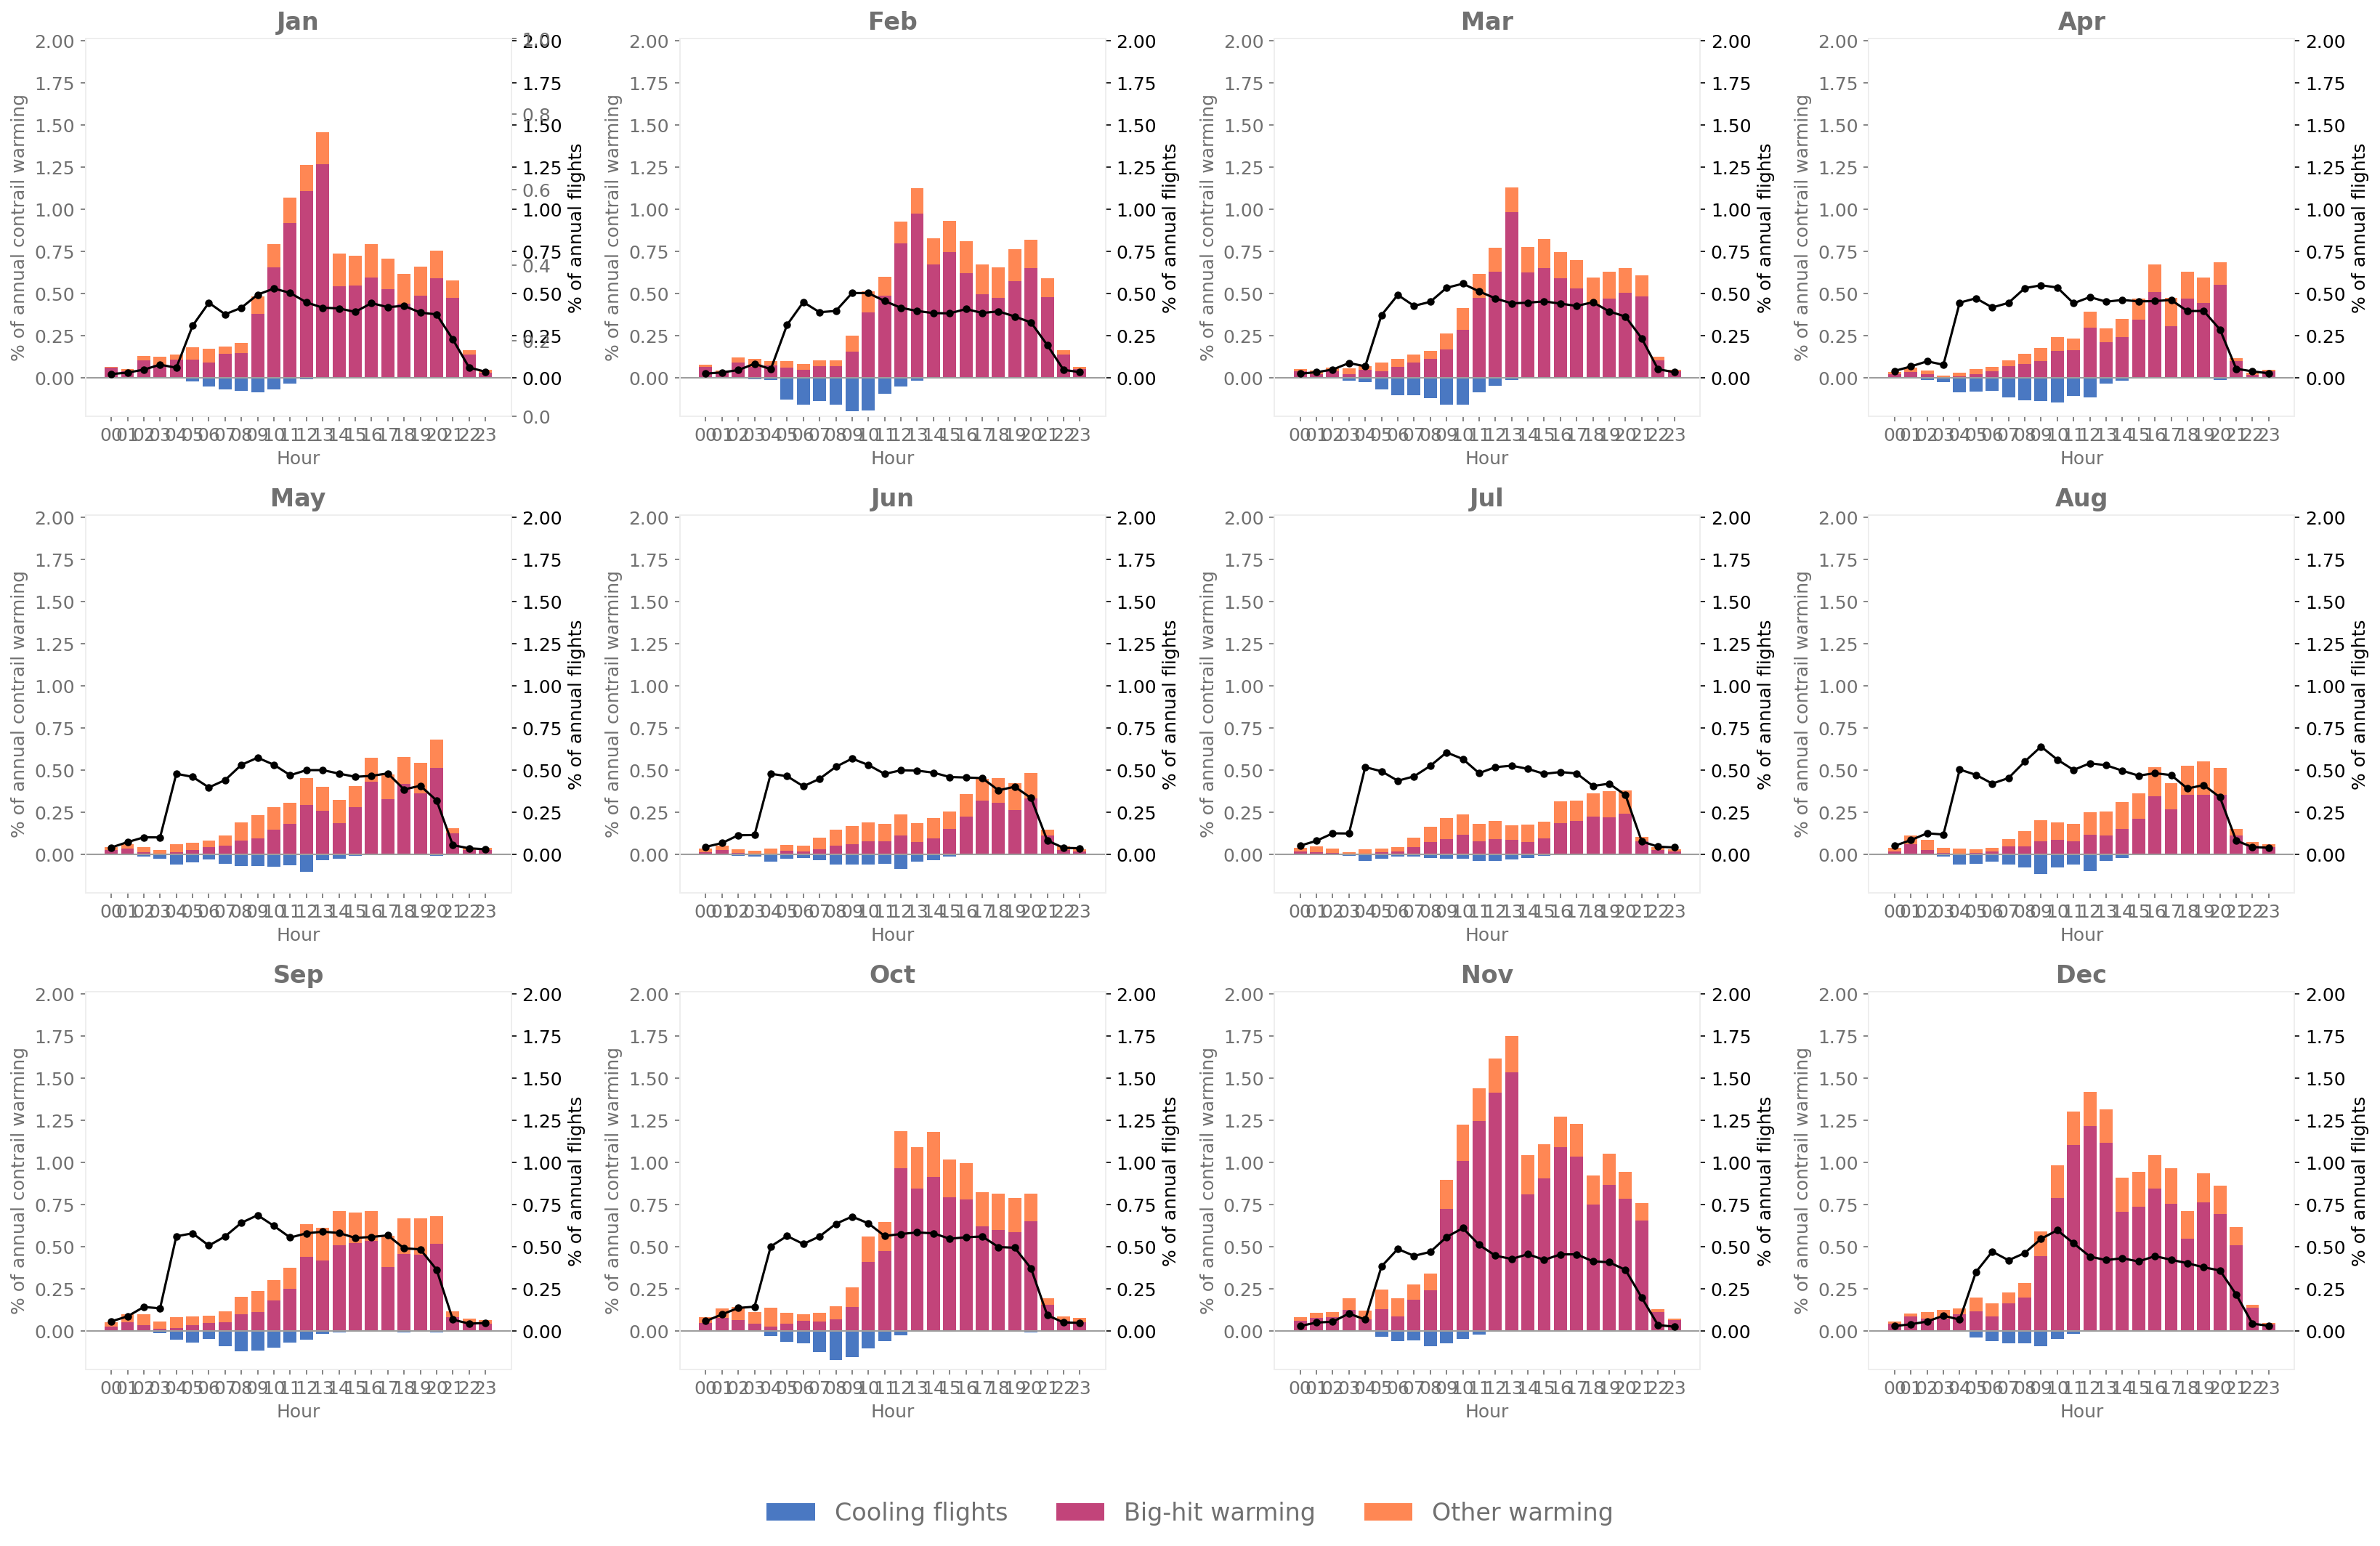

In [10]:
plot_contrail_distribution(df[df["origin_country"] == "DE"])

## France

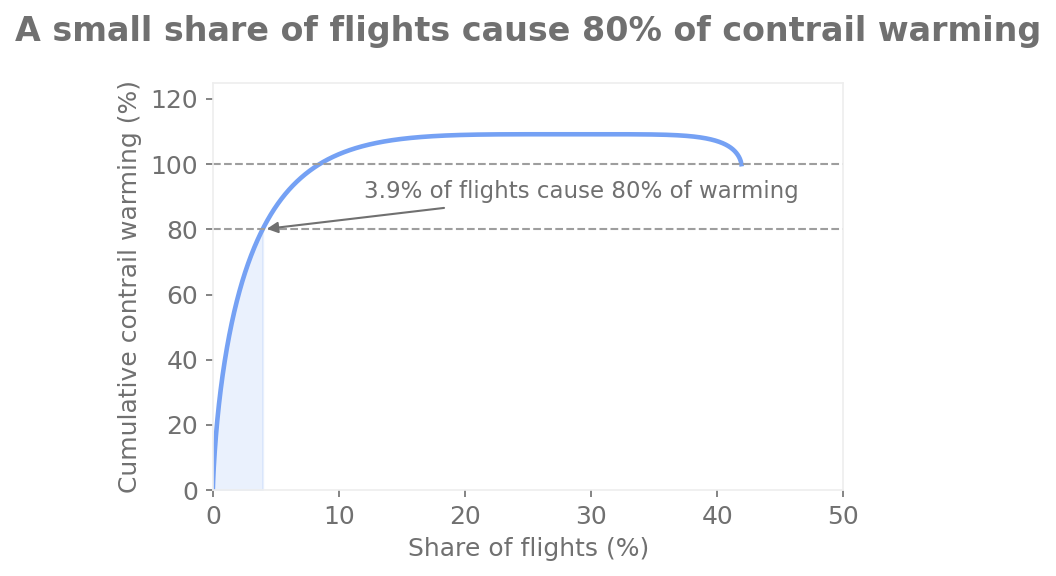

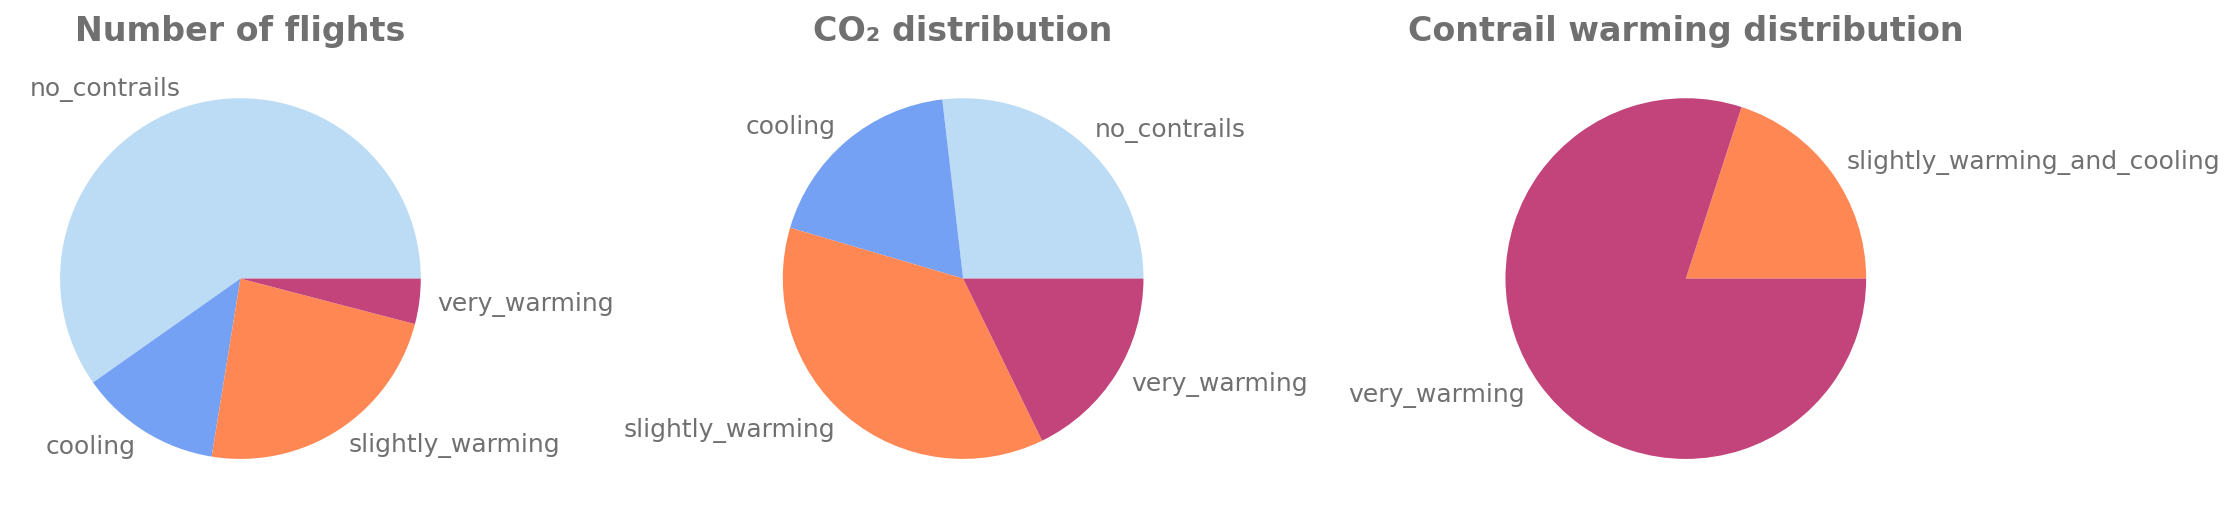

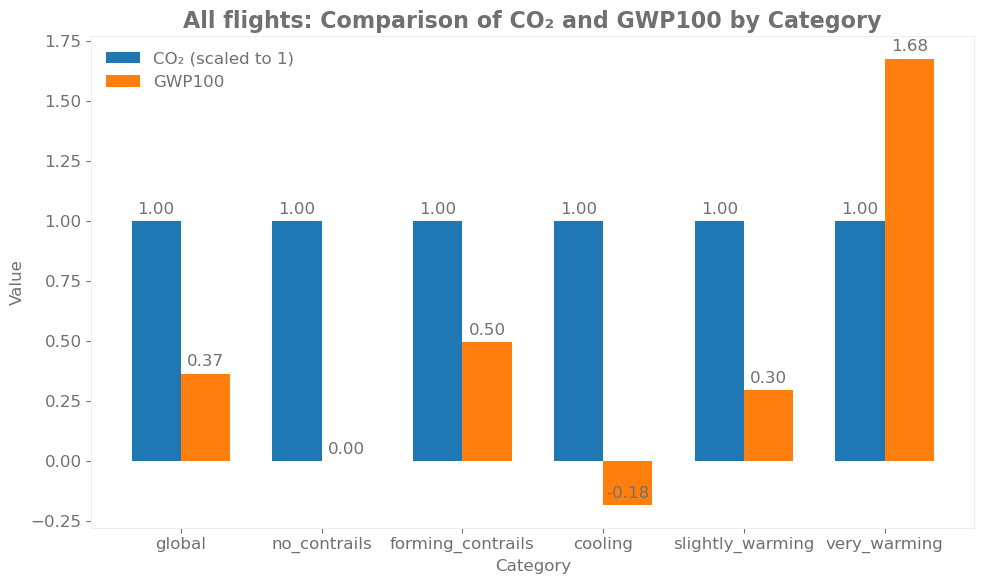

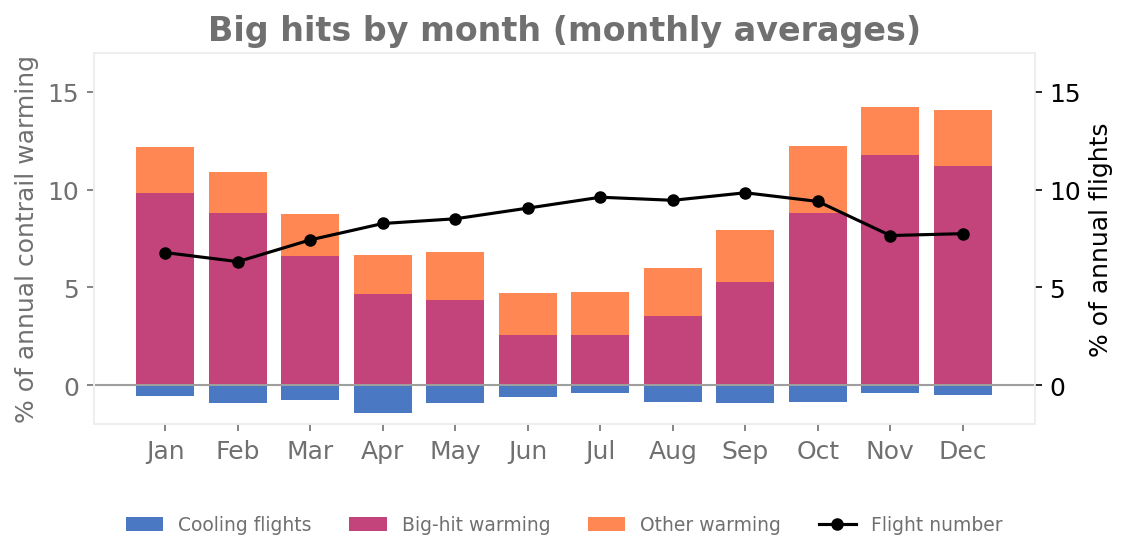

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

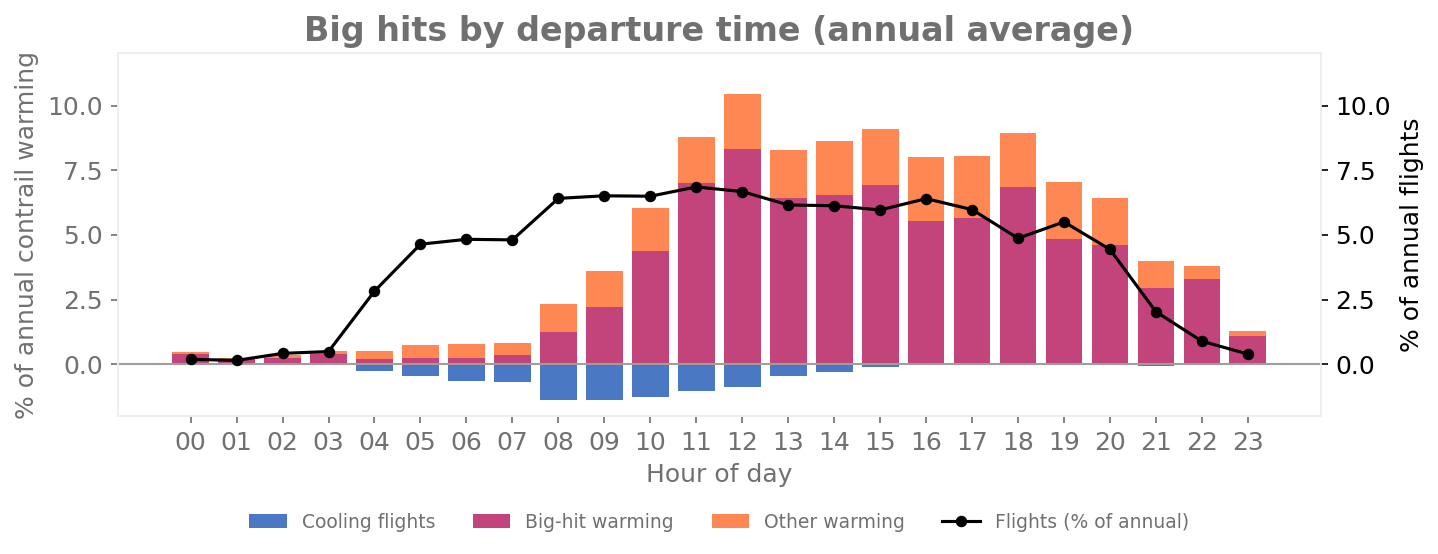

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:421: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_season"] = _df["_month"].map(season_map)
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:422: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

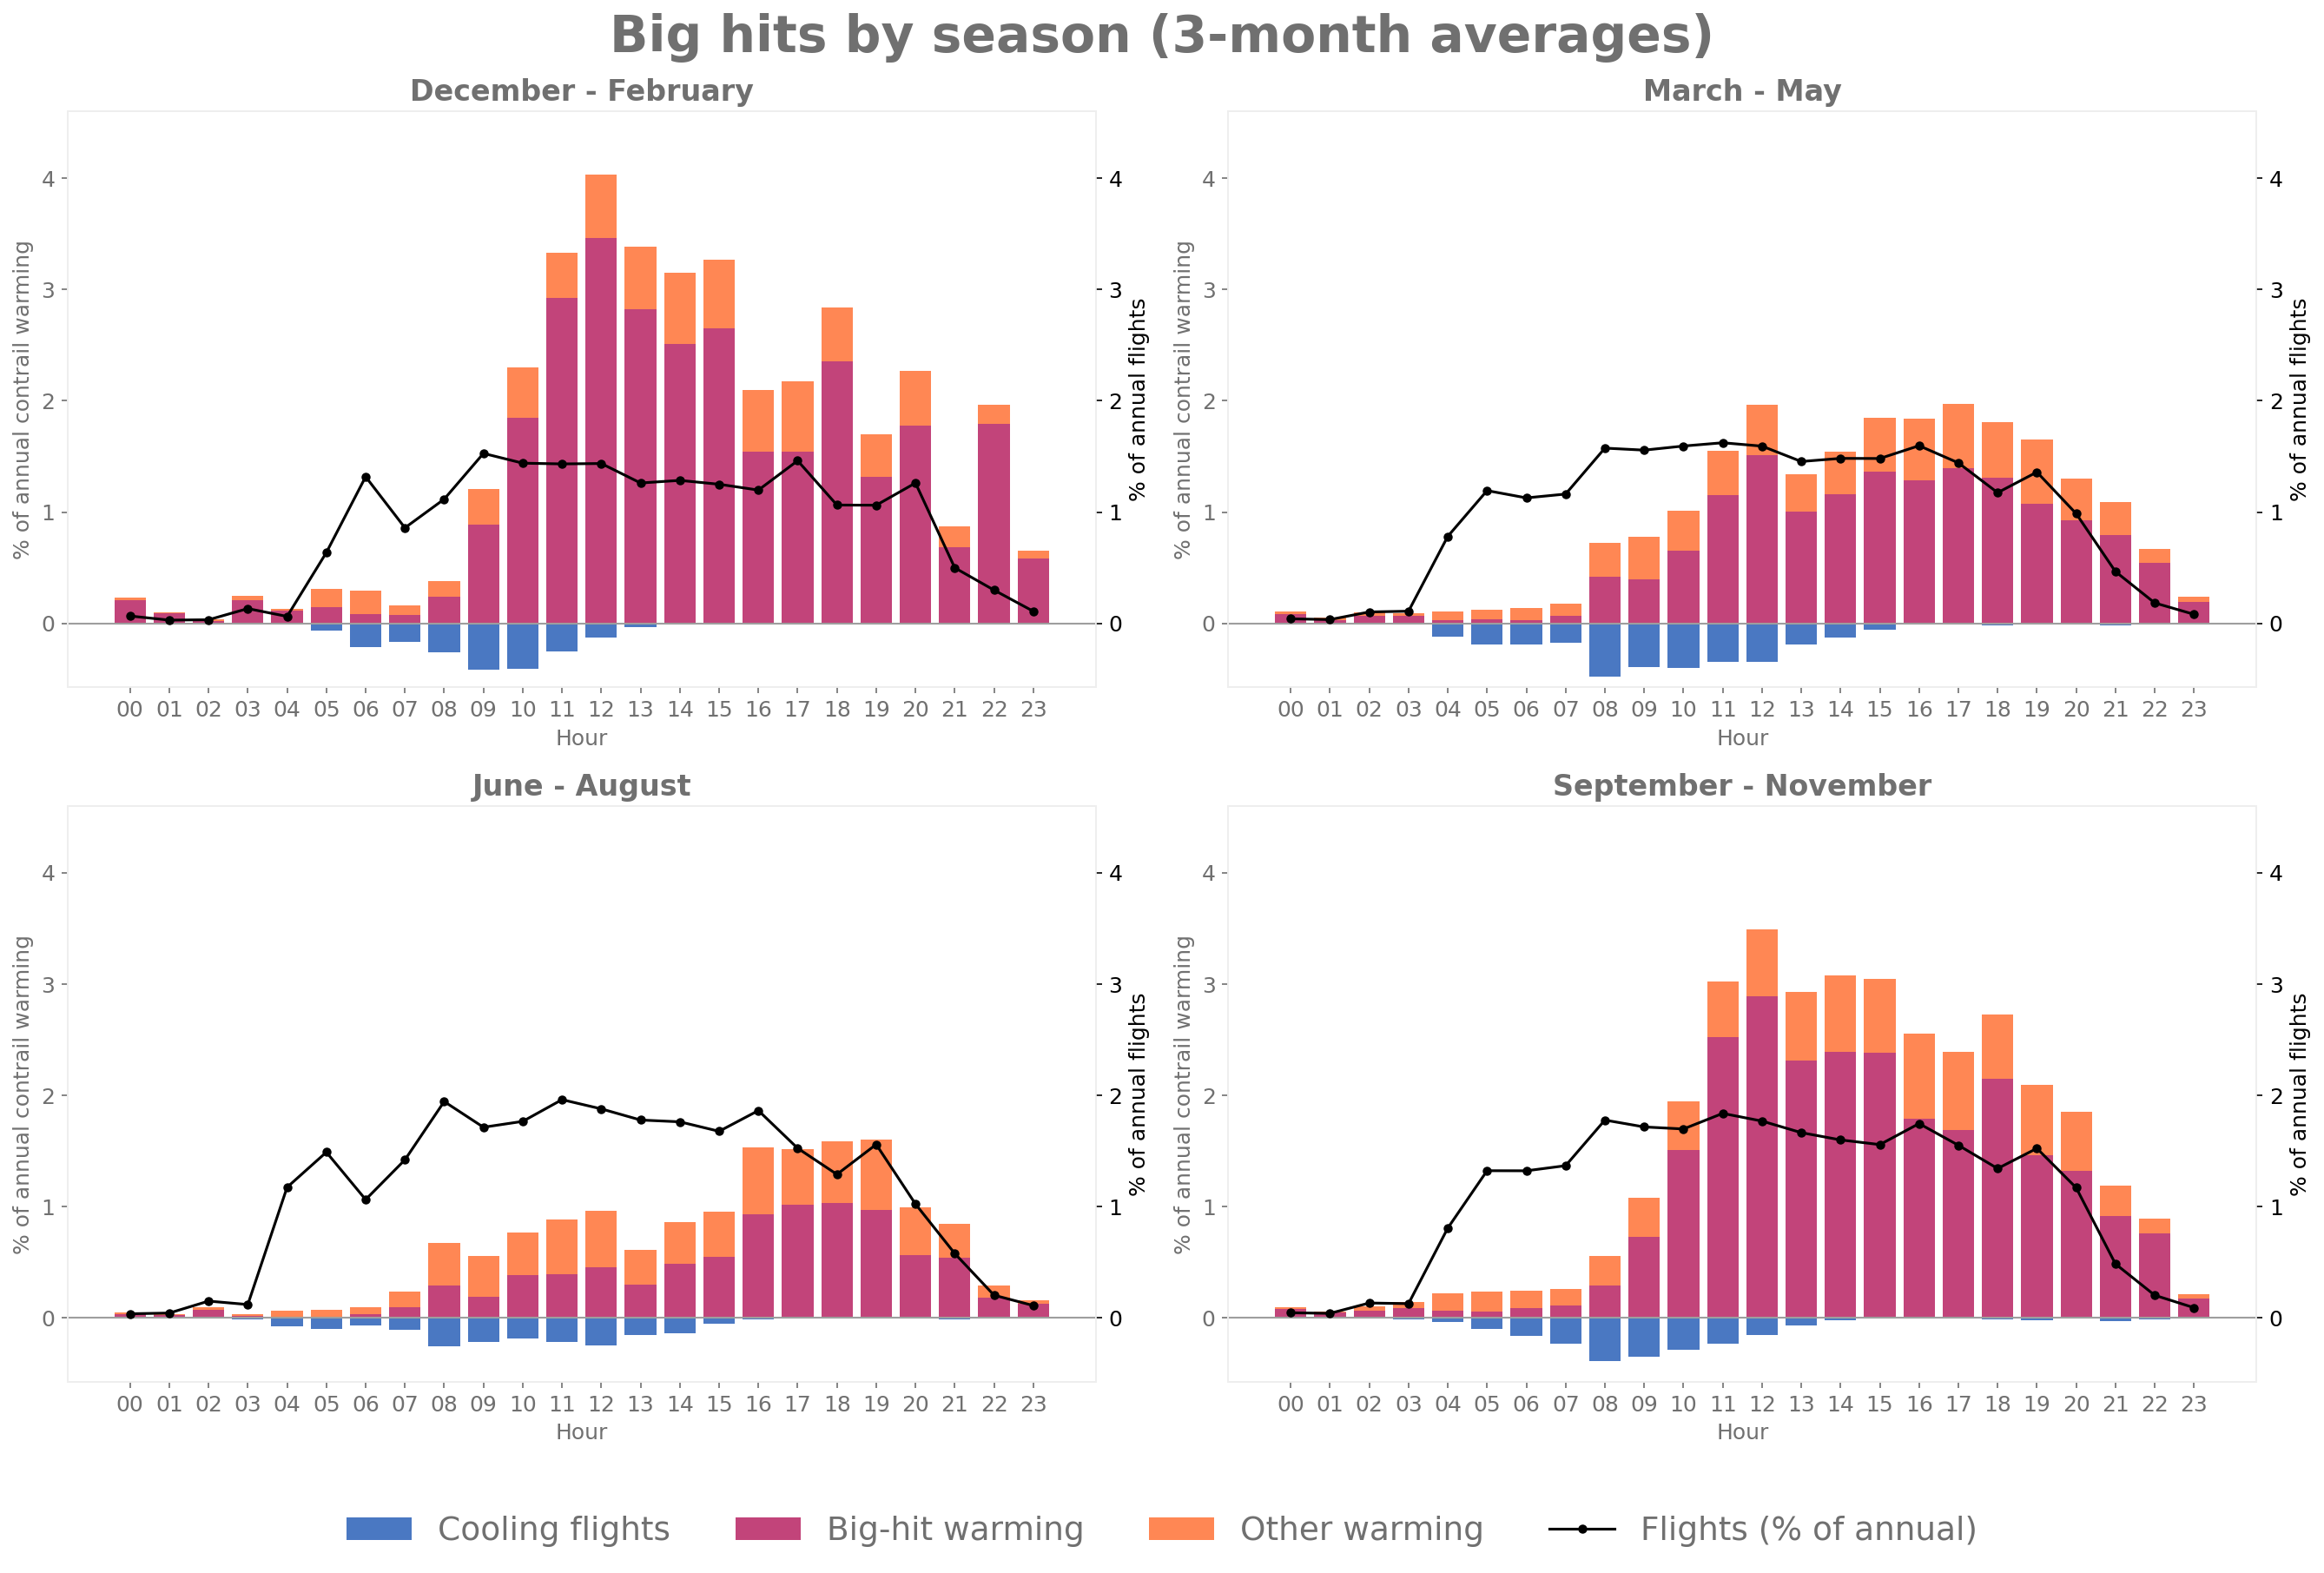

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:529: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"]  = _df[DATE_COL].dt.hour
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


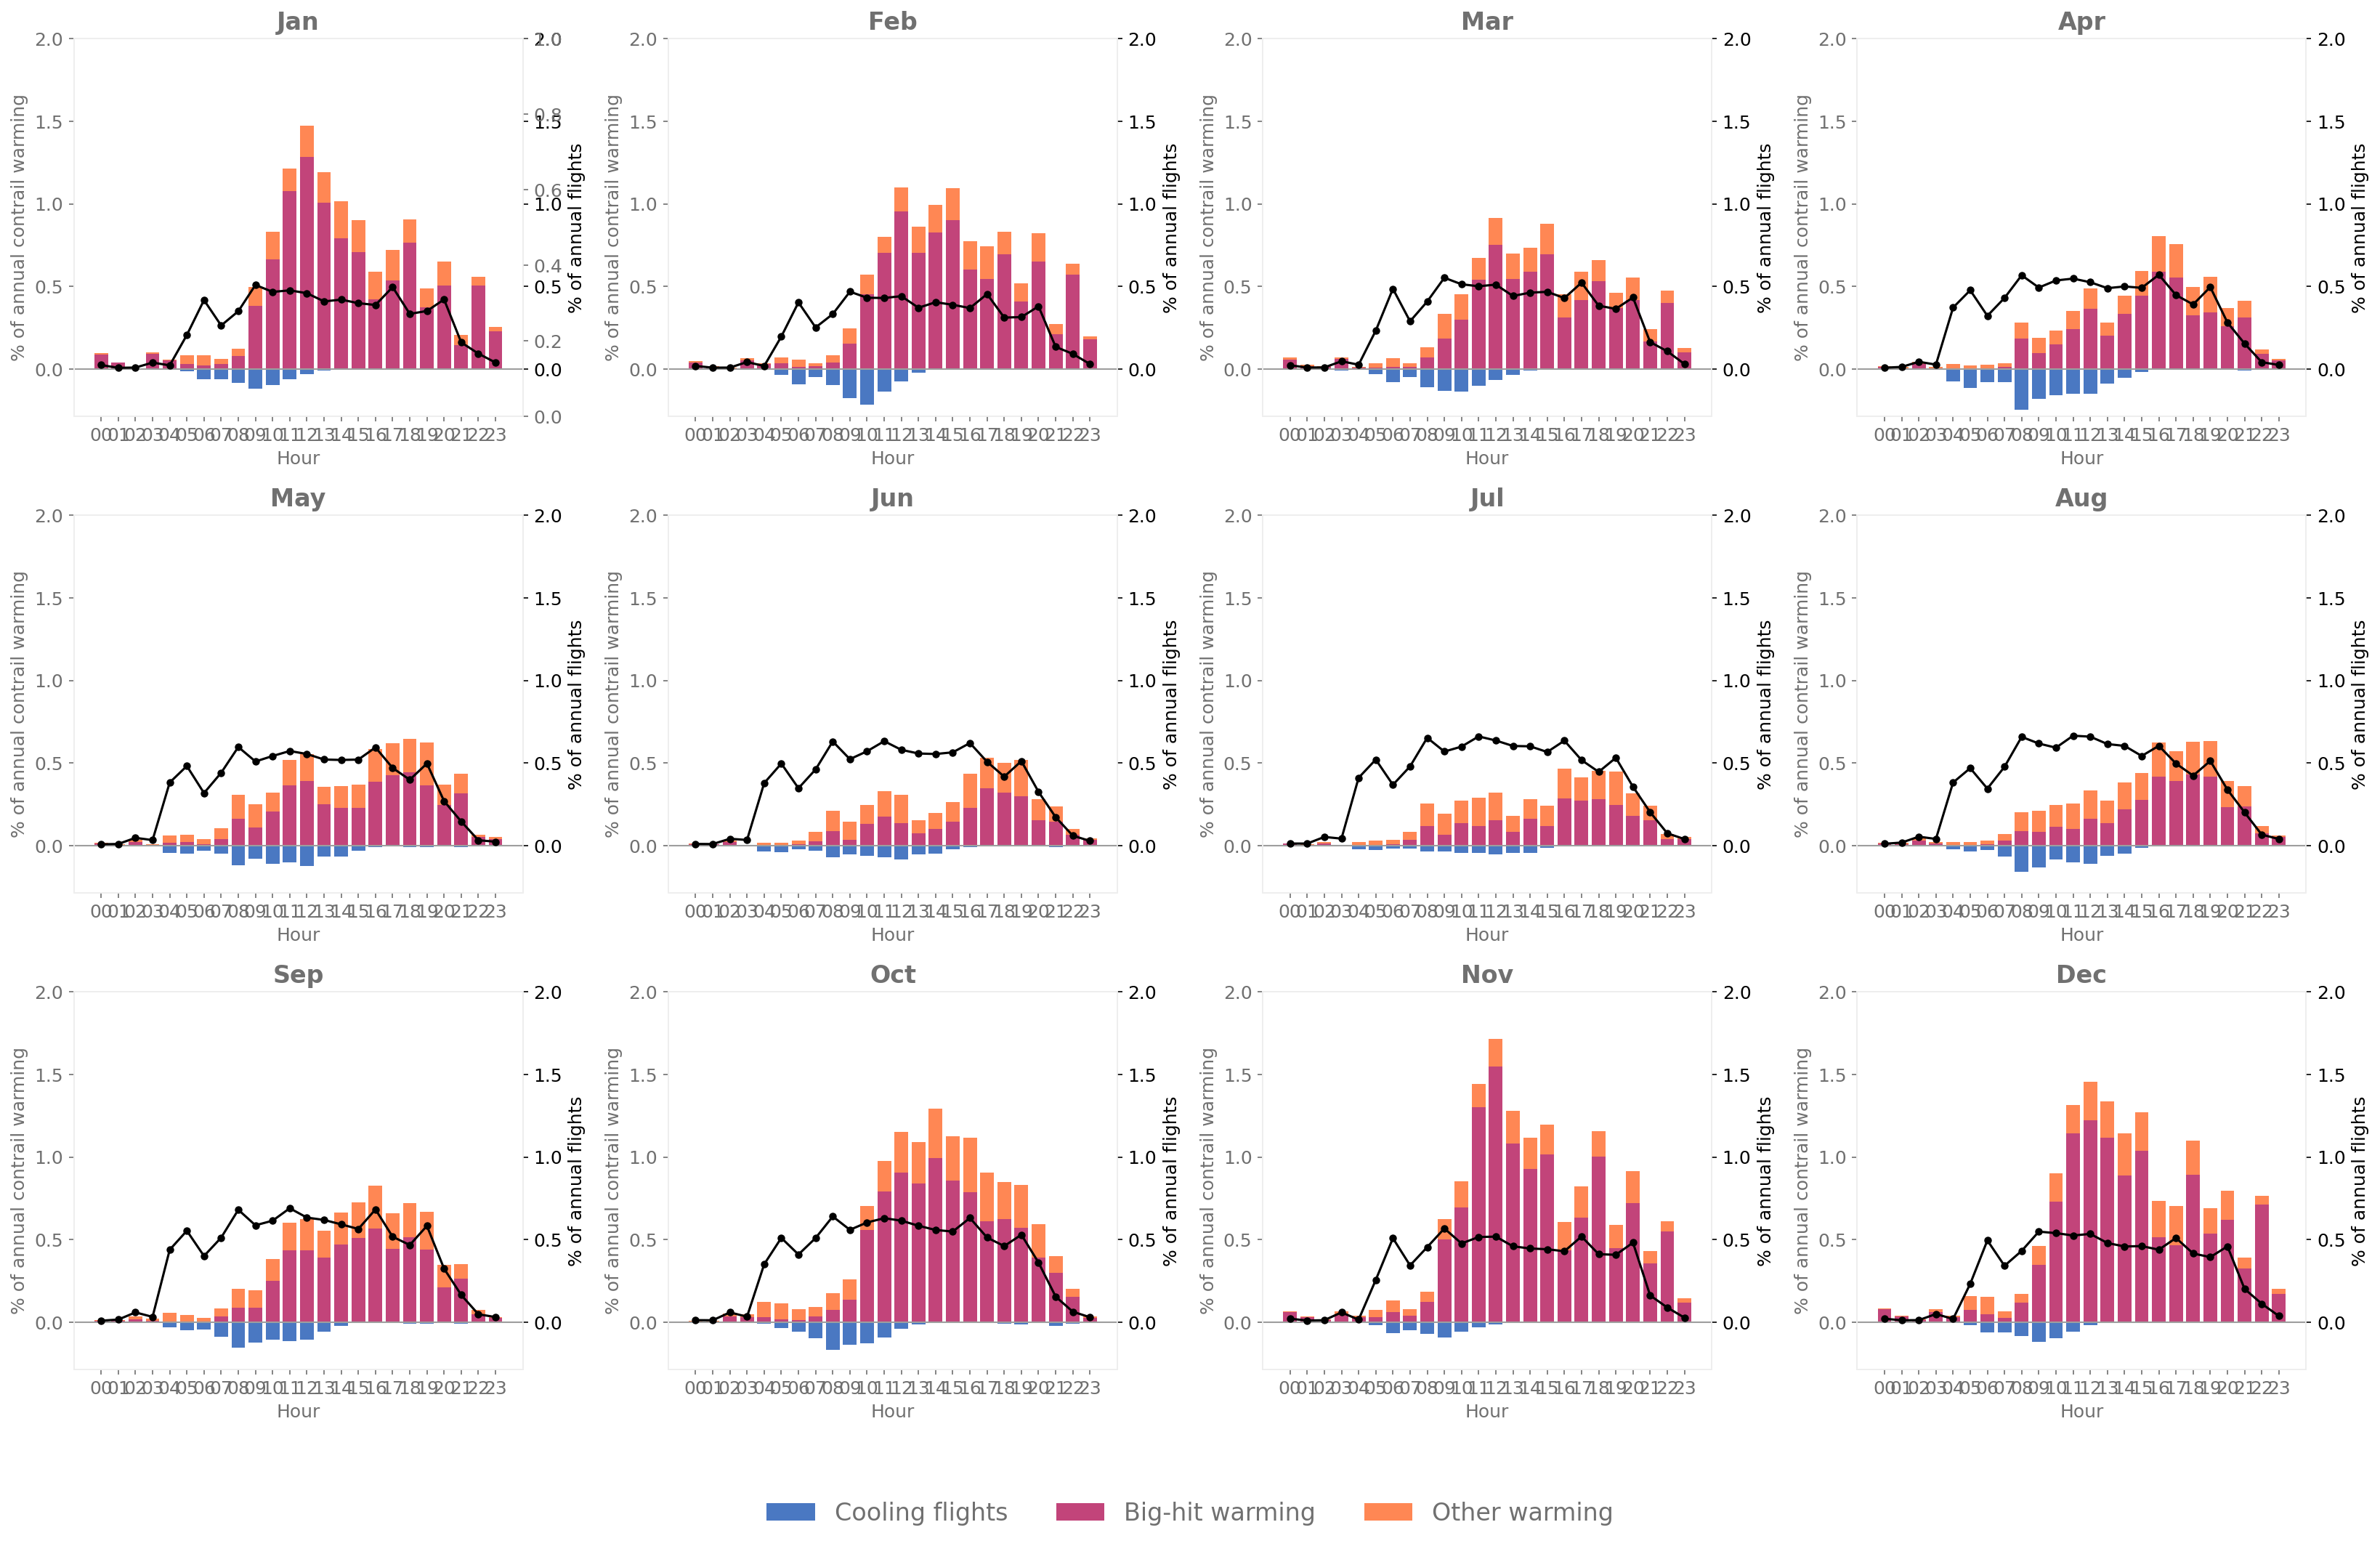

In [11]:
plot_contrail_distribution(df[df["origin_country"] == "FR"])

## Spain

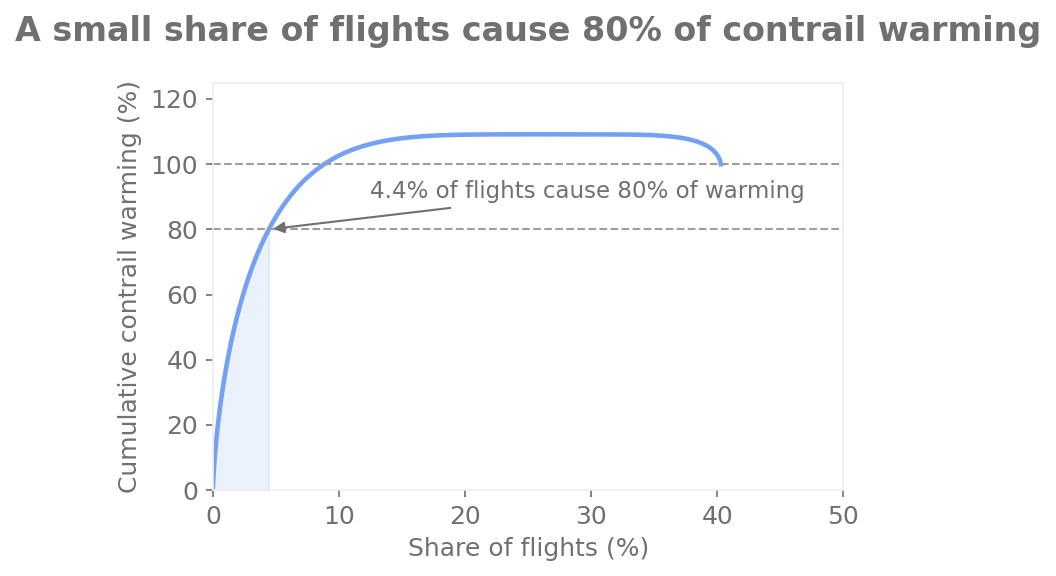

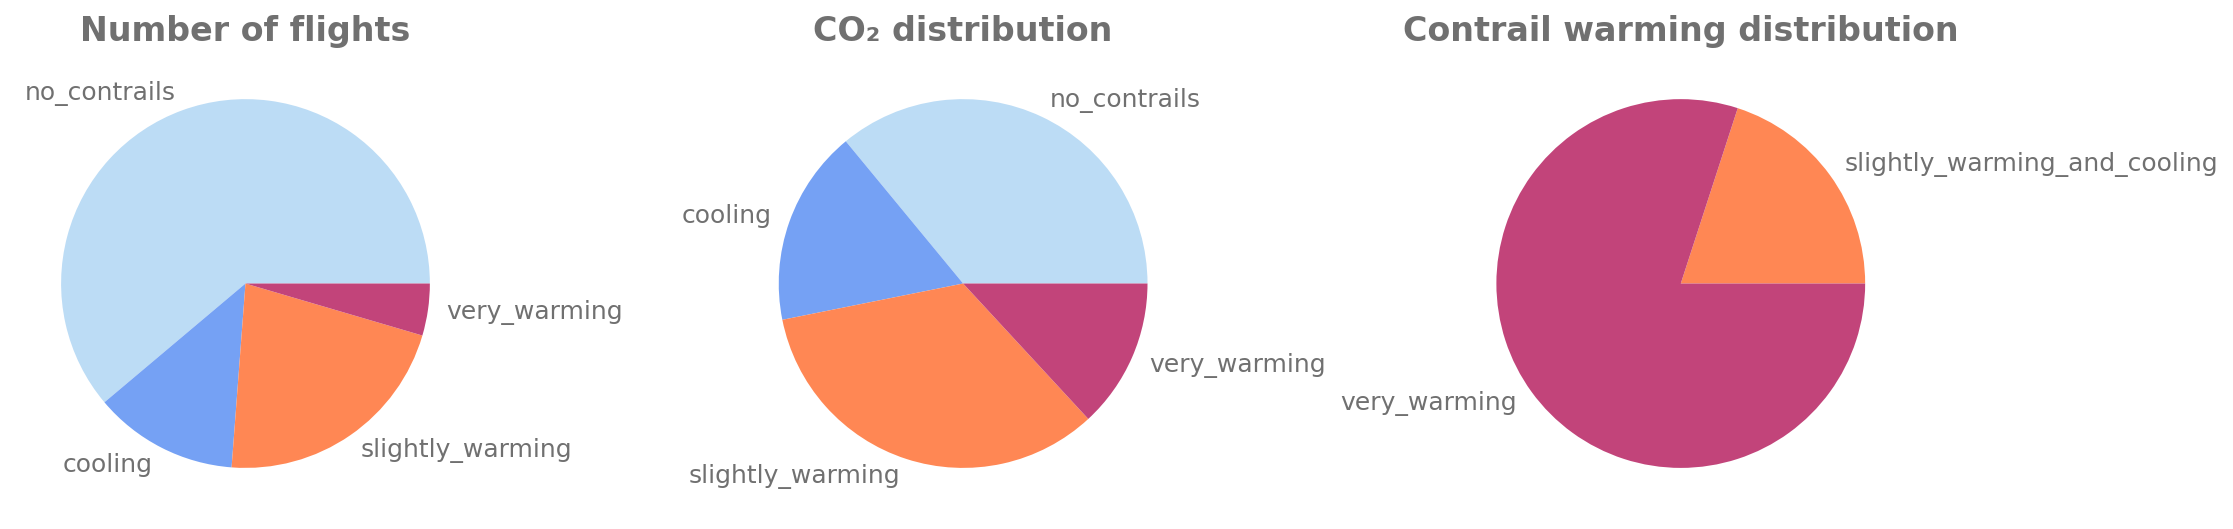

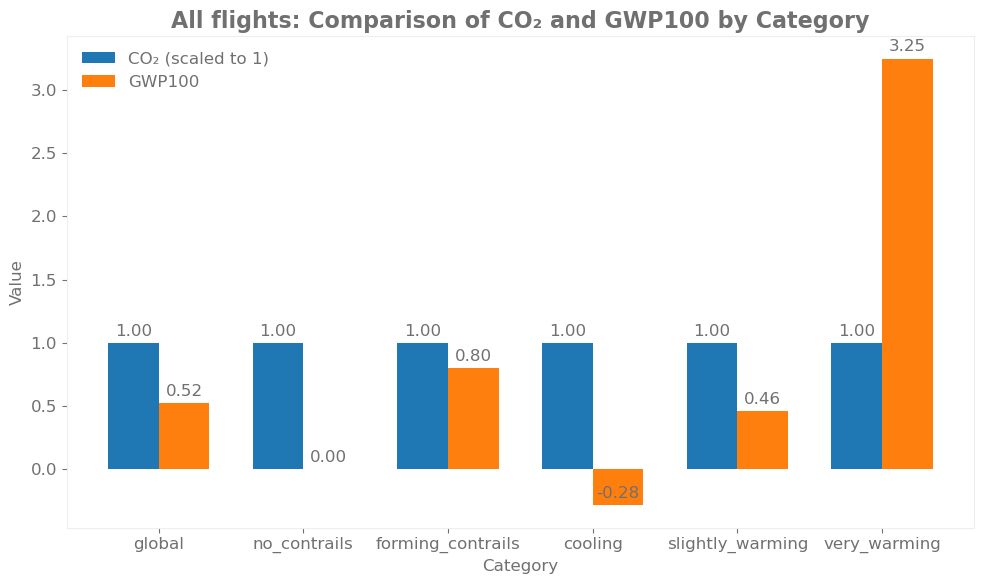

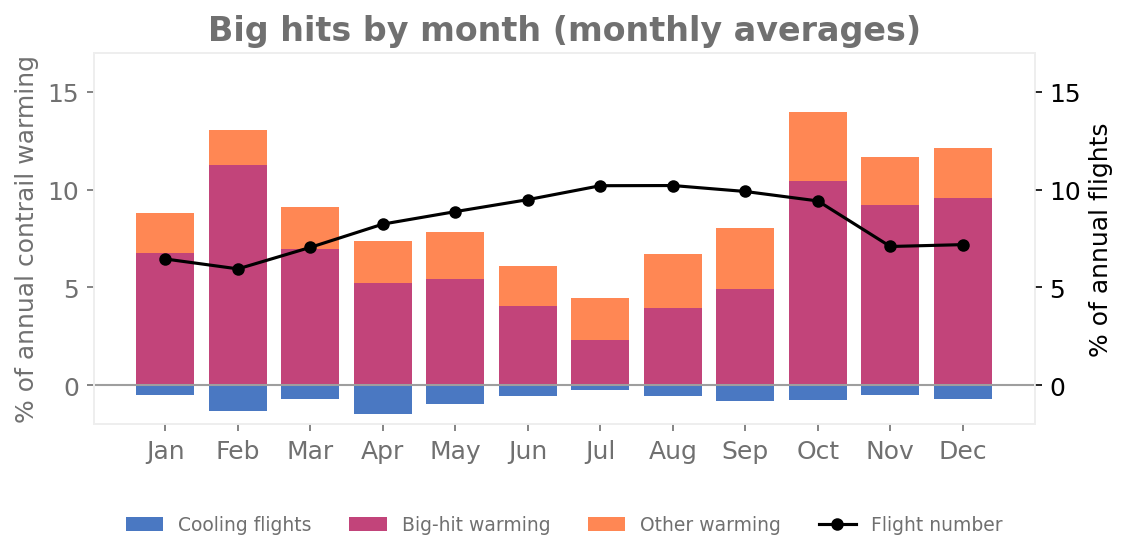

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

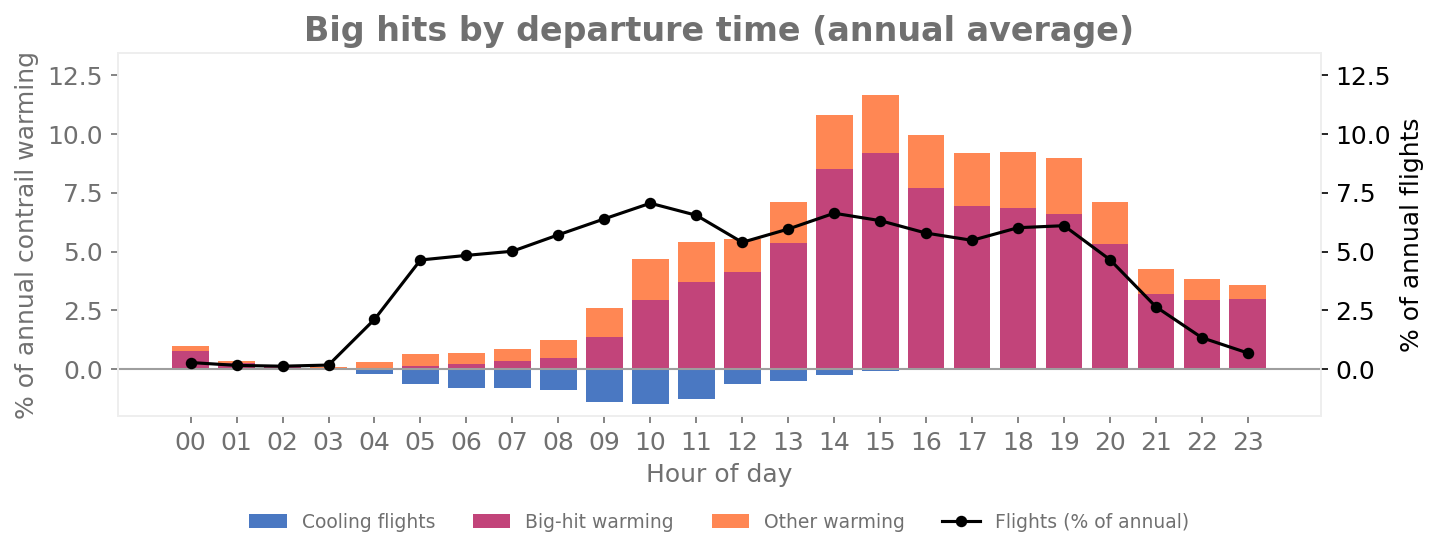

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:421: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_season"] = _df["_month"].map(season_map)
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:422: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

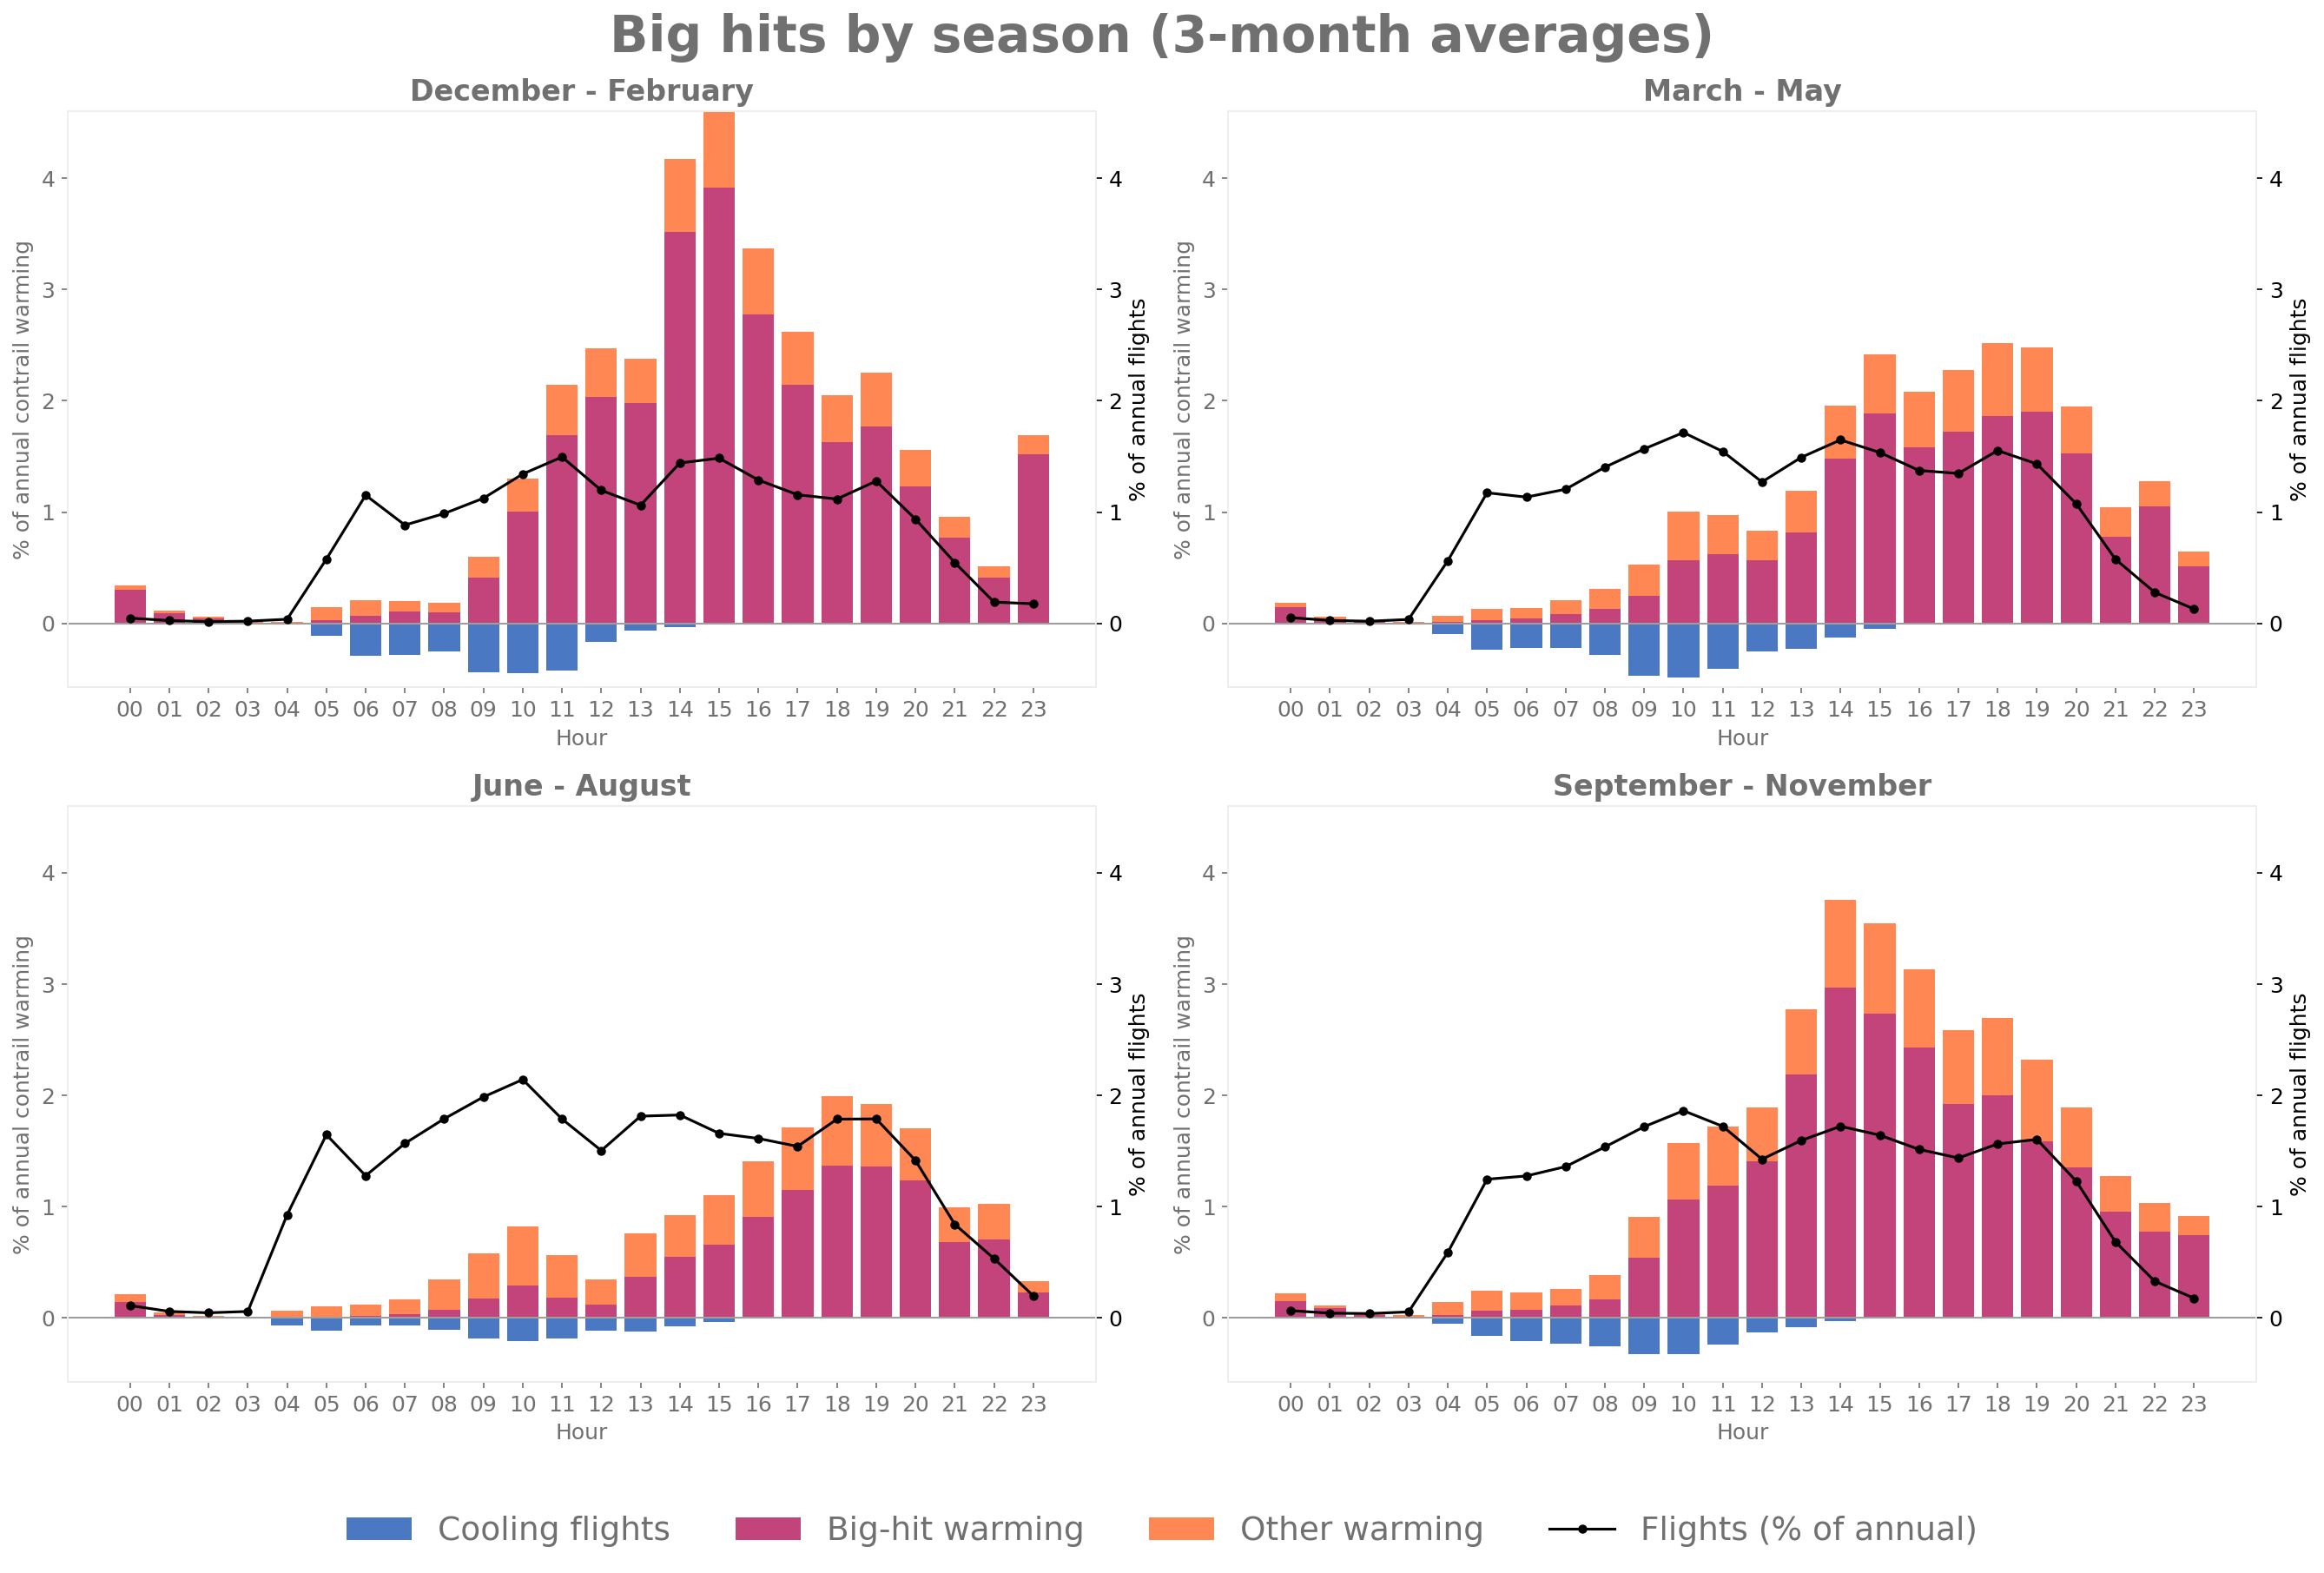

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:529: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"]  = _df[DATE_COL].dt.hour
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


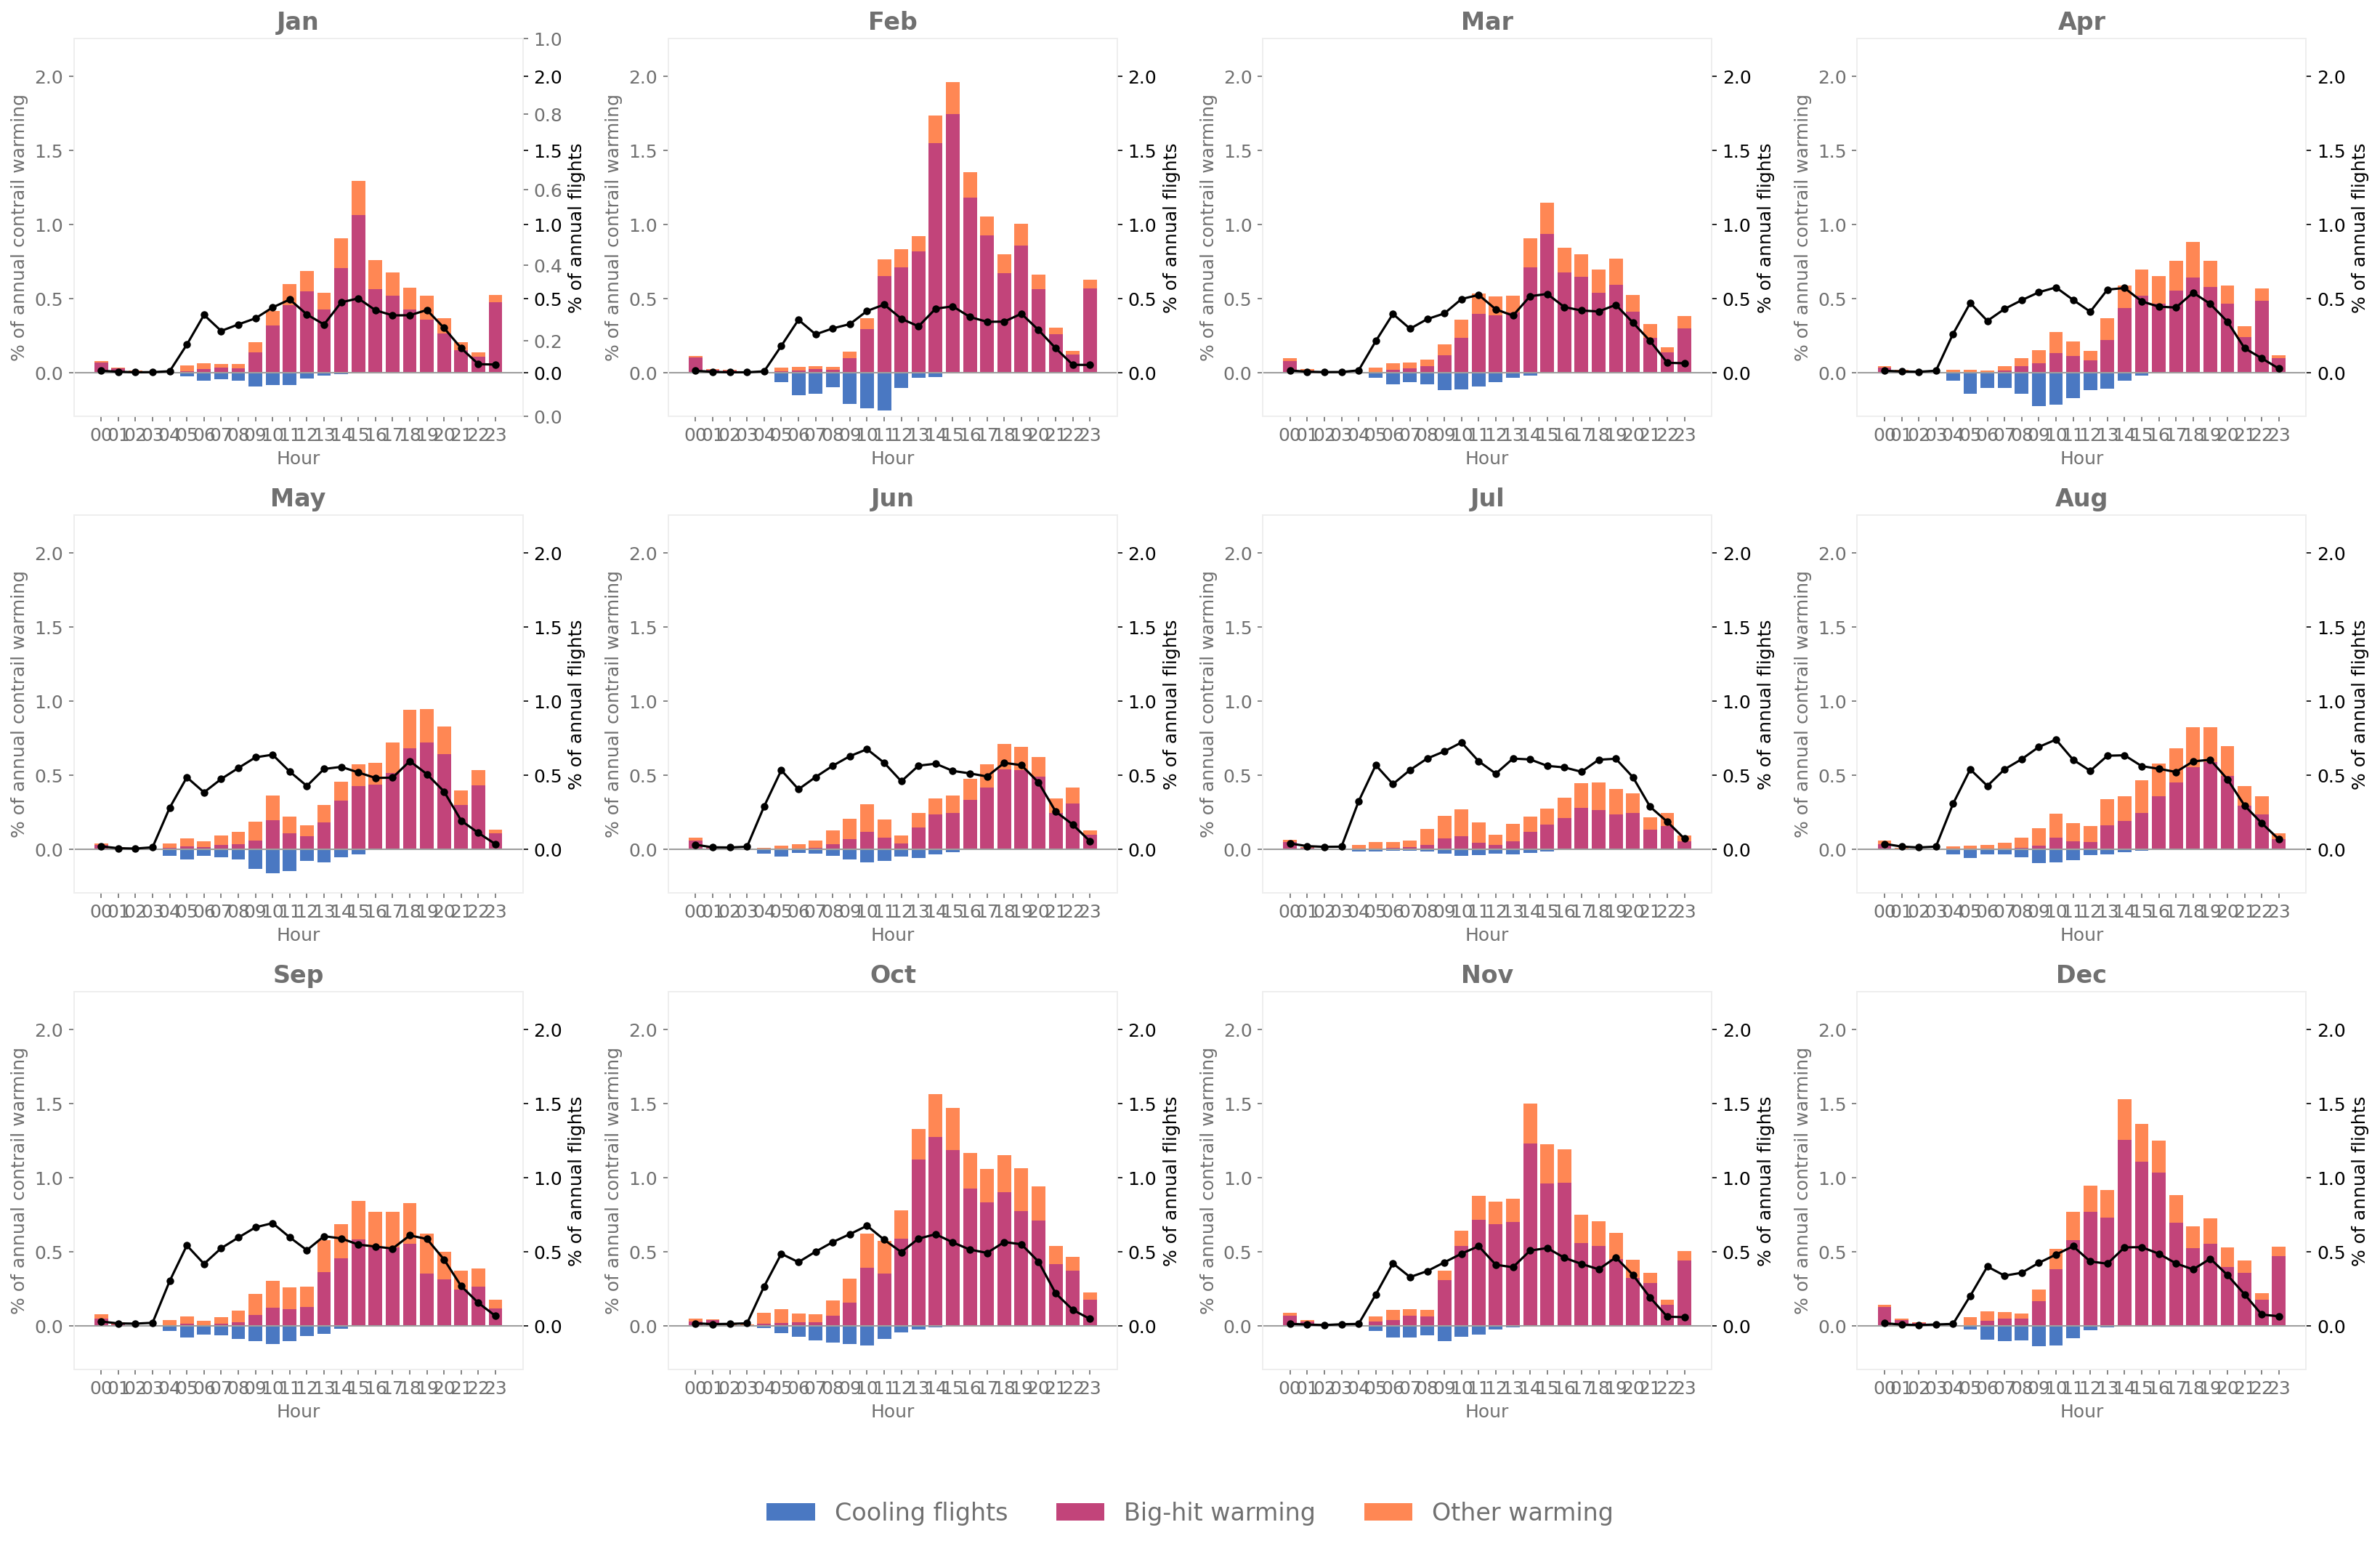

In [12]:
plot_contrail_distribution(df[df["origin_country"] == "ES"])

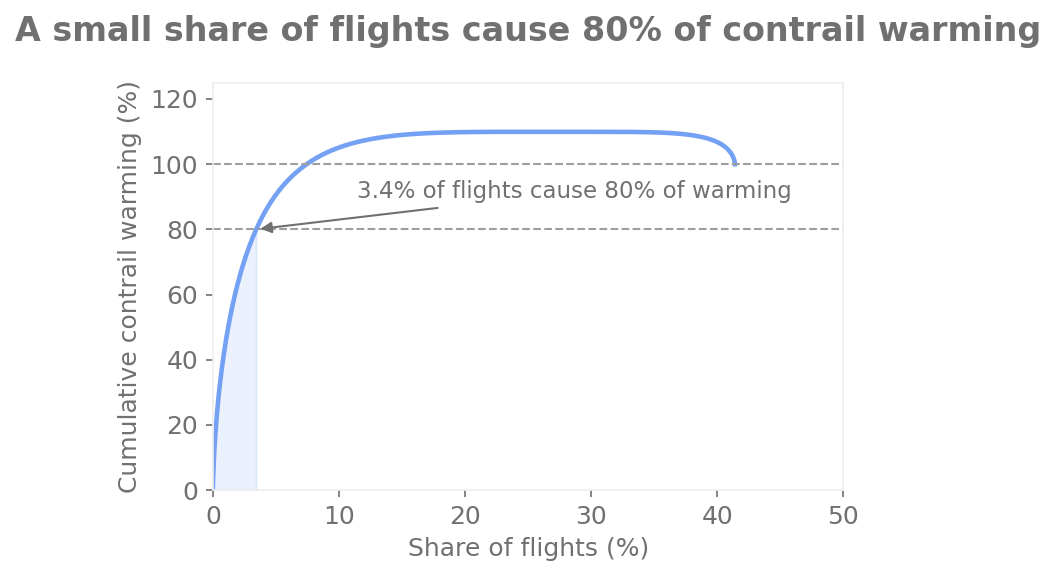

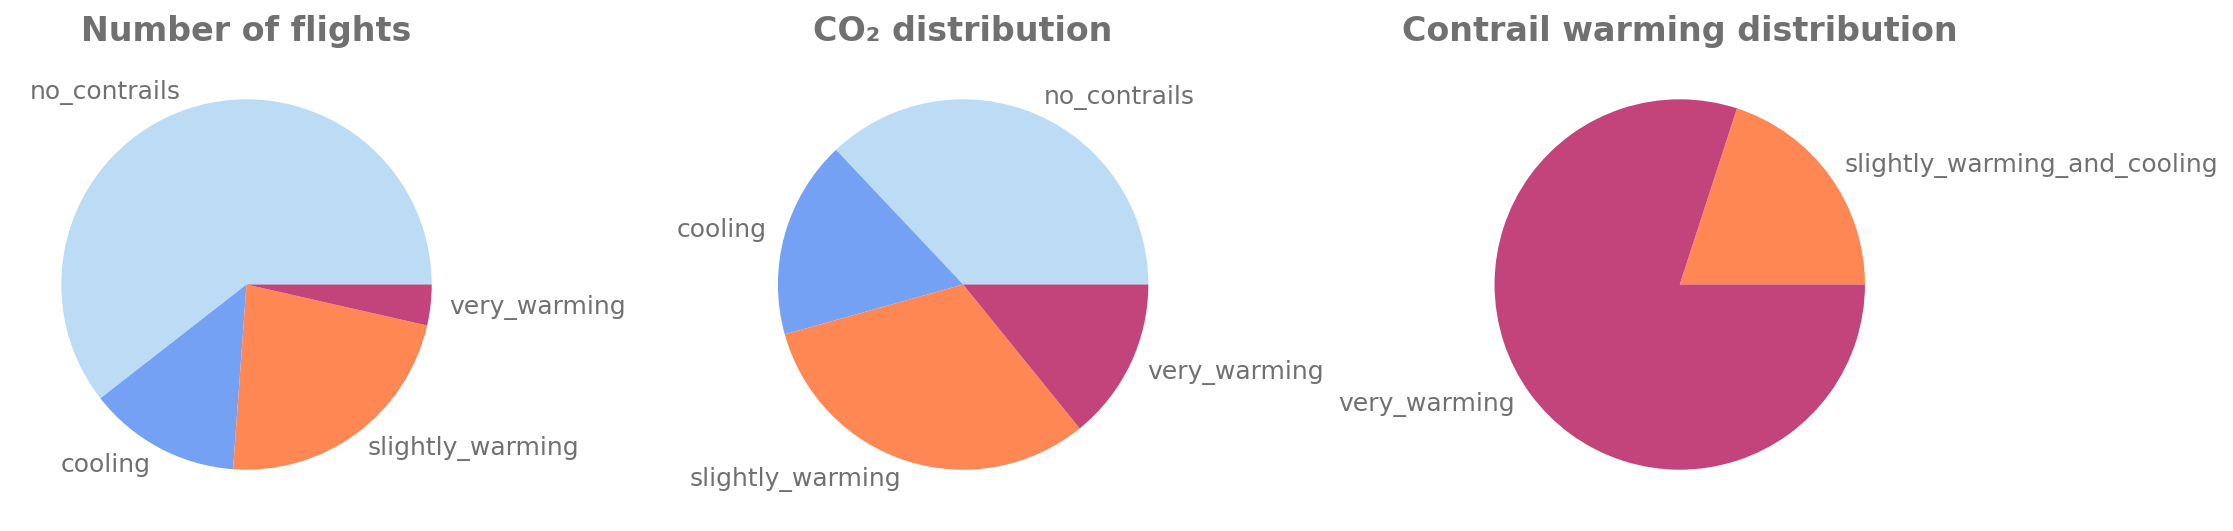

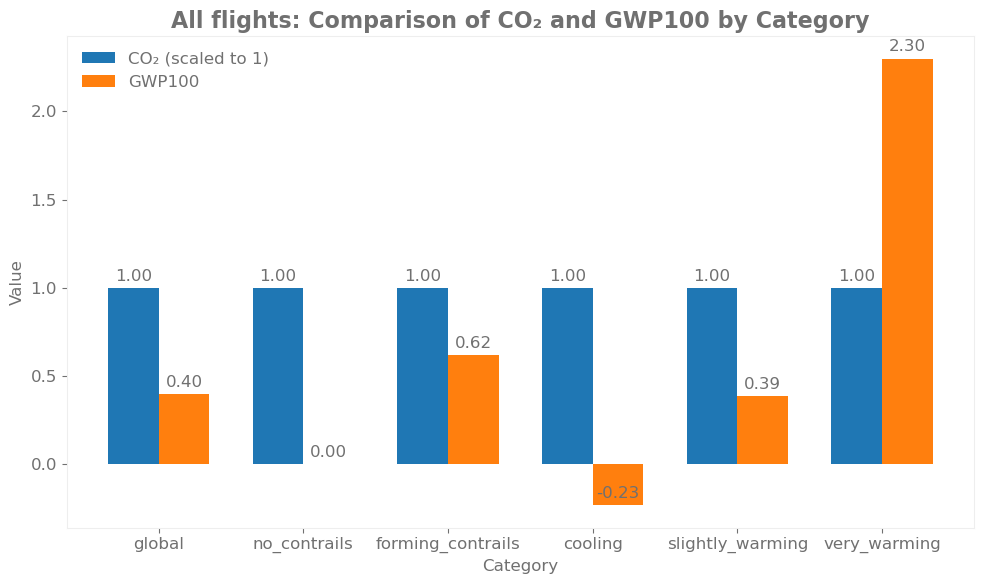

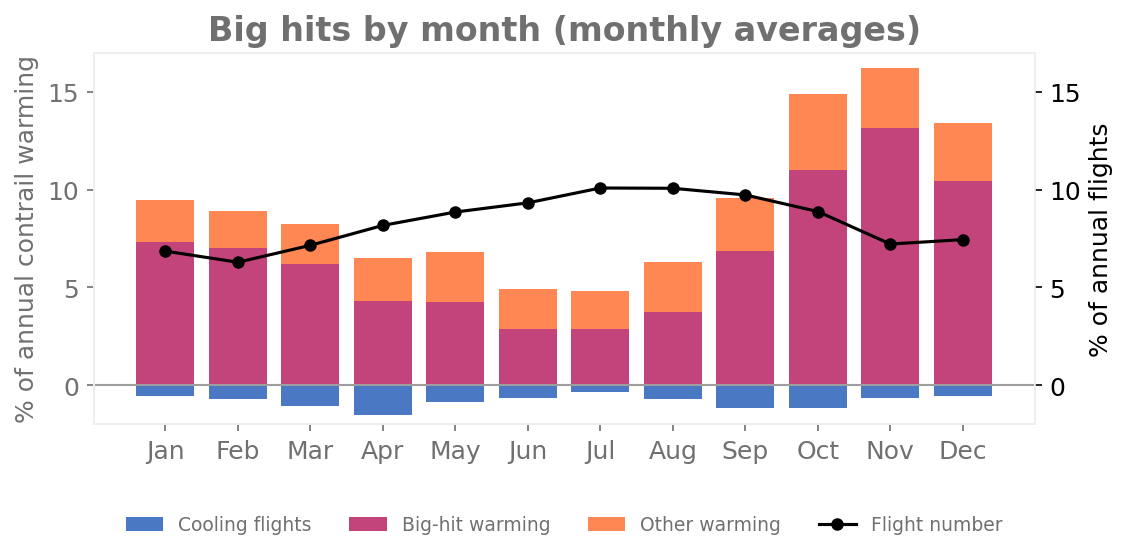

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

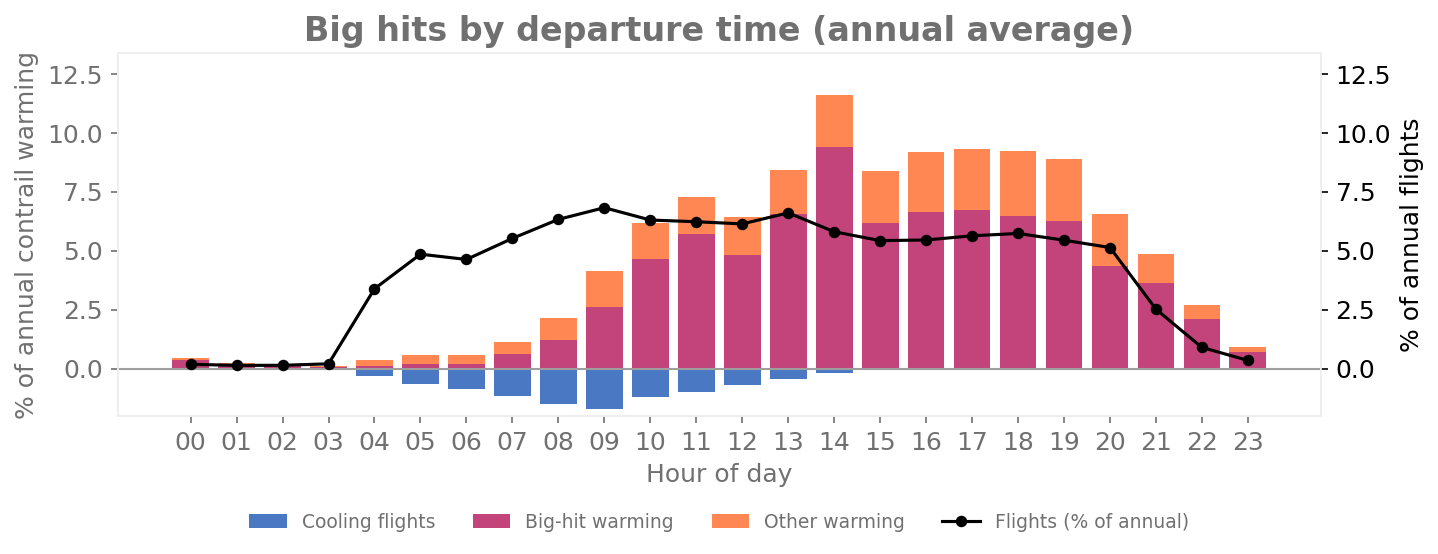

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:421: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_season"] = _df["_month"].map(season_map)
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:422: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

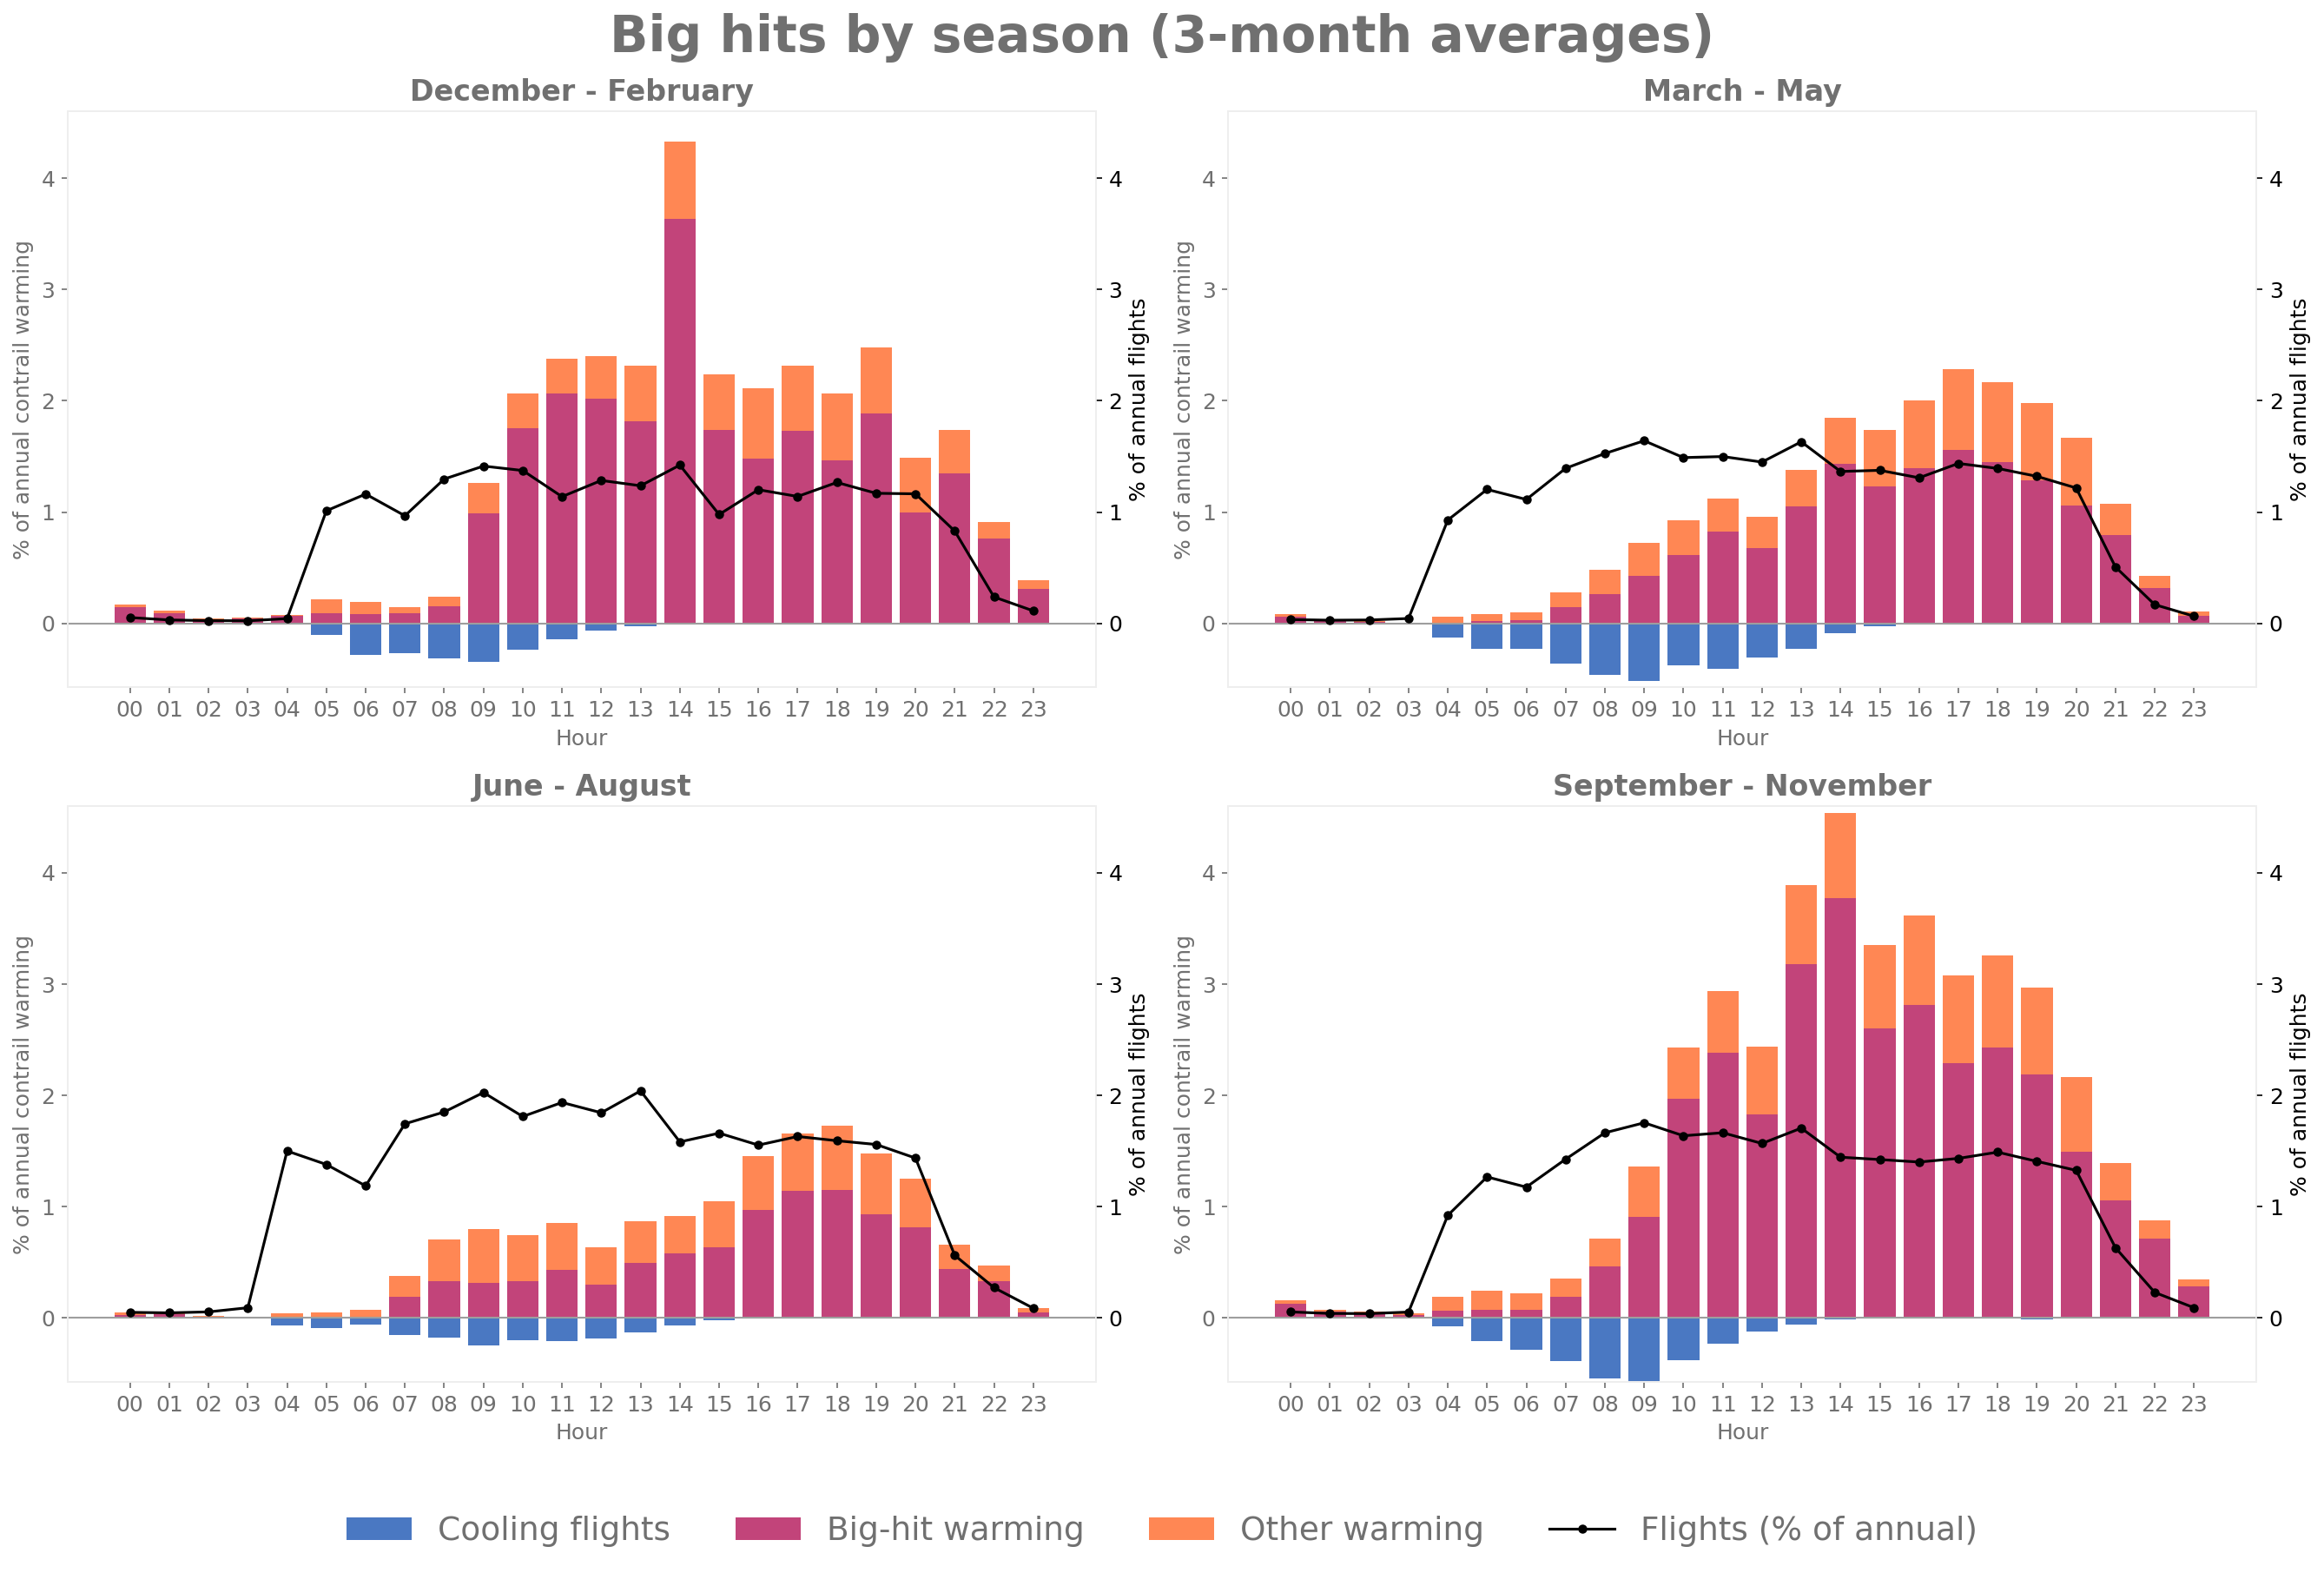

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:529: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"]  = _df[DATE_COL].dt.hour
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


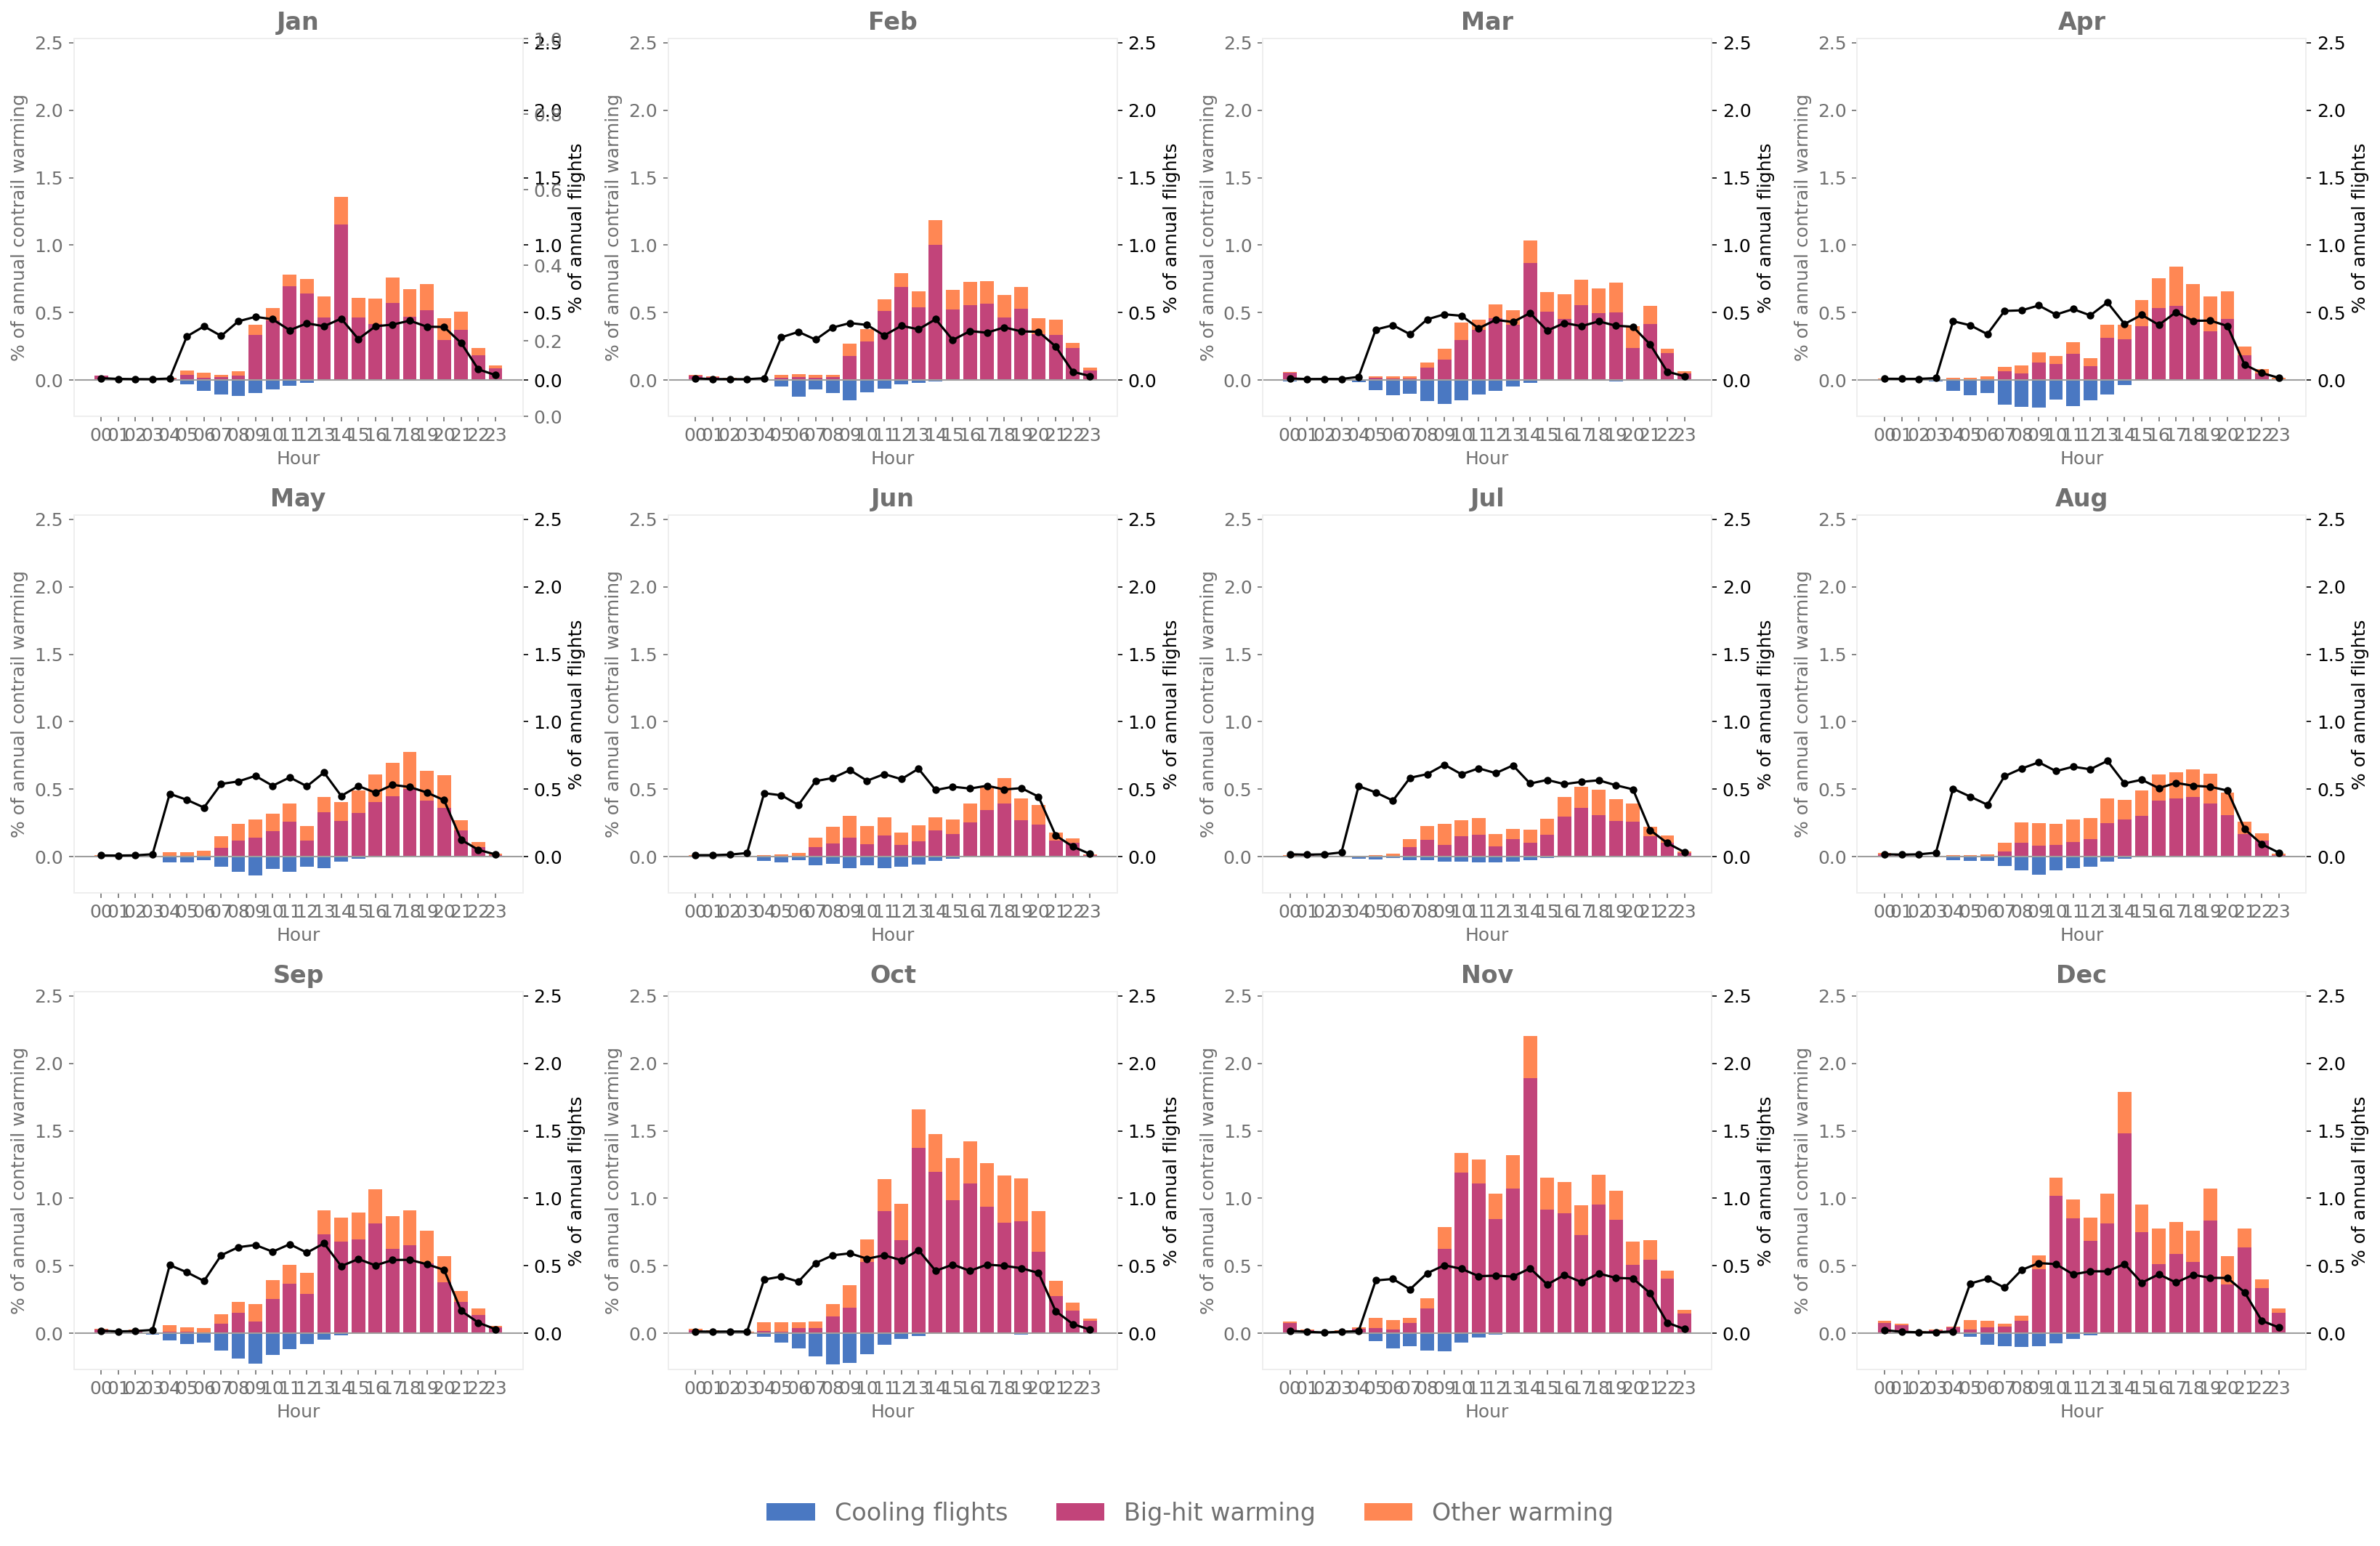

In [13]:
plot_contrail_distribution(df[df["origin_country"] == "IT"])

## UK

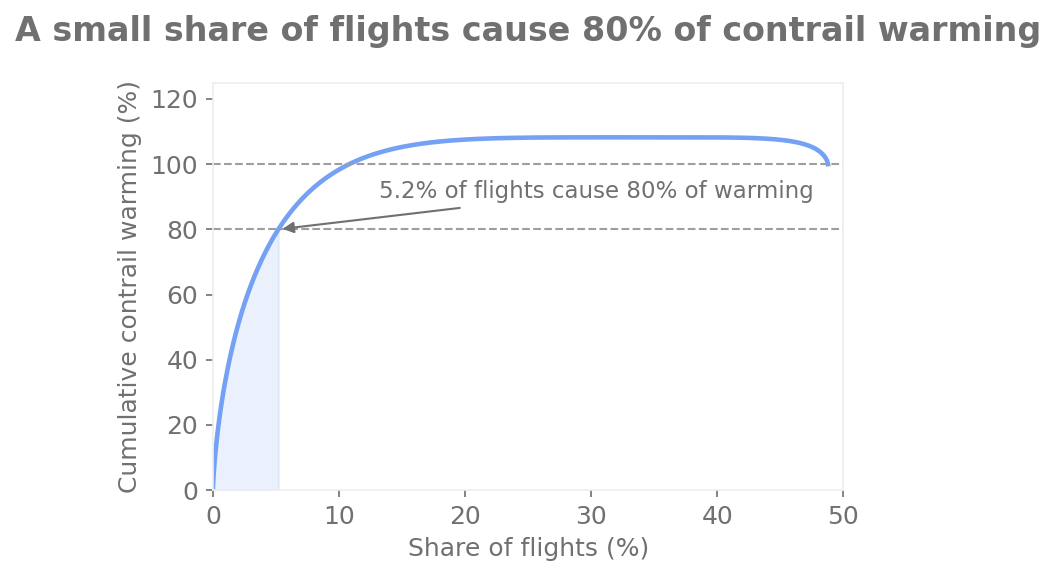

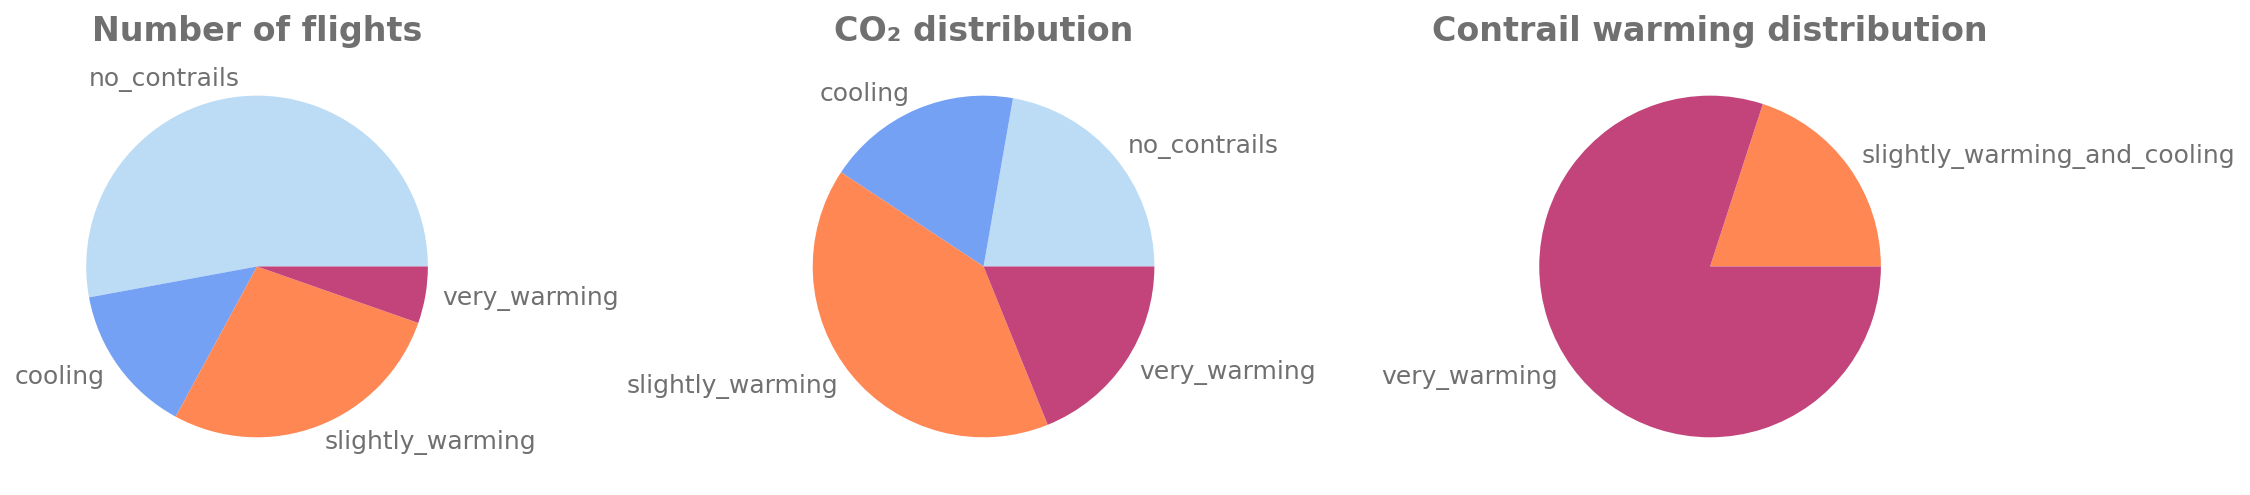

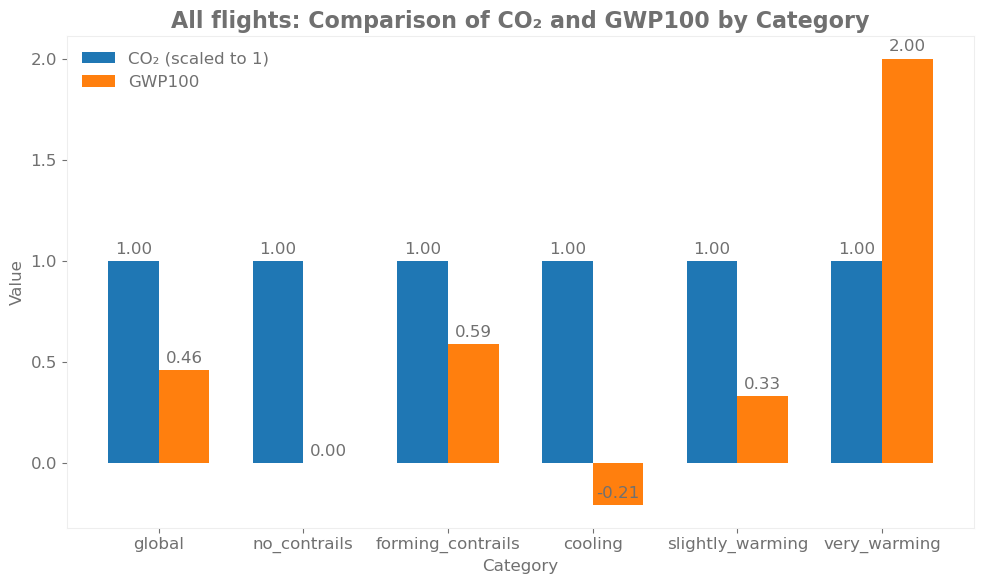

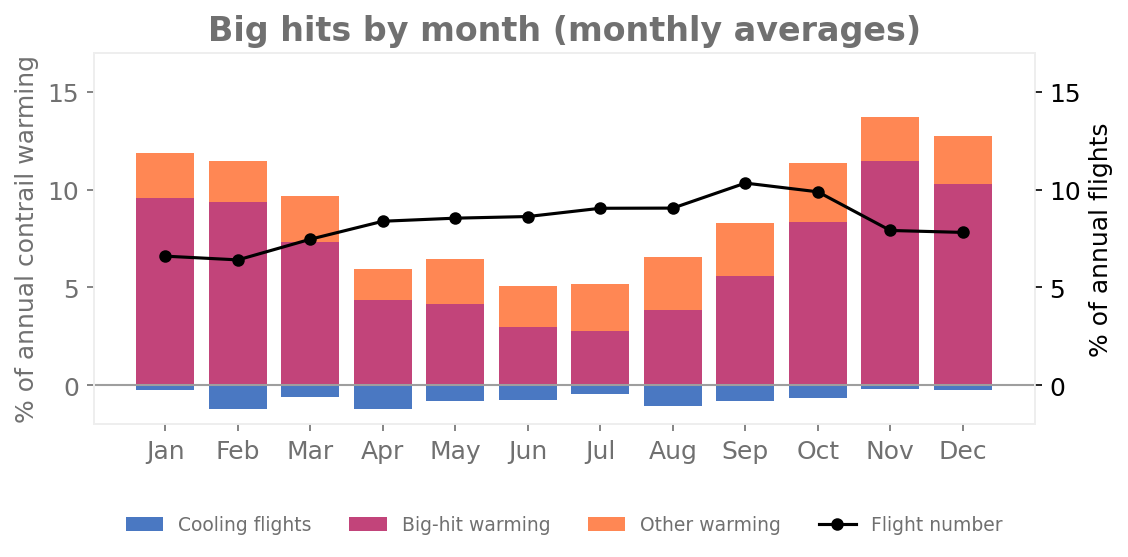

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"] = _df[DATE_COL].dt.hour  # 0..23
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

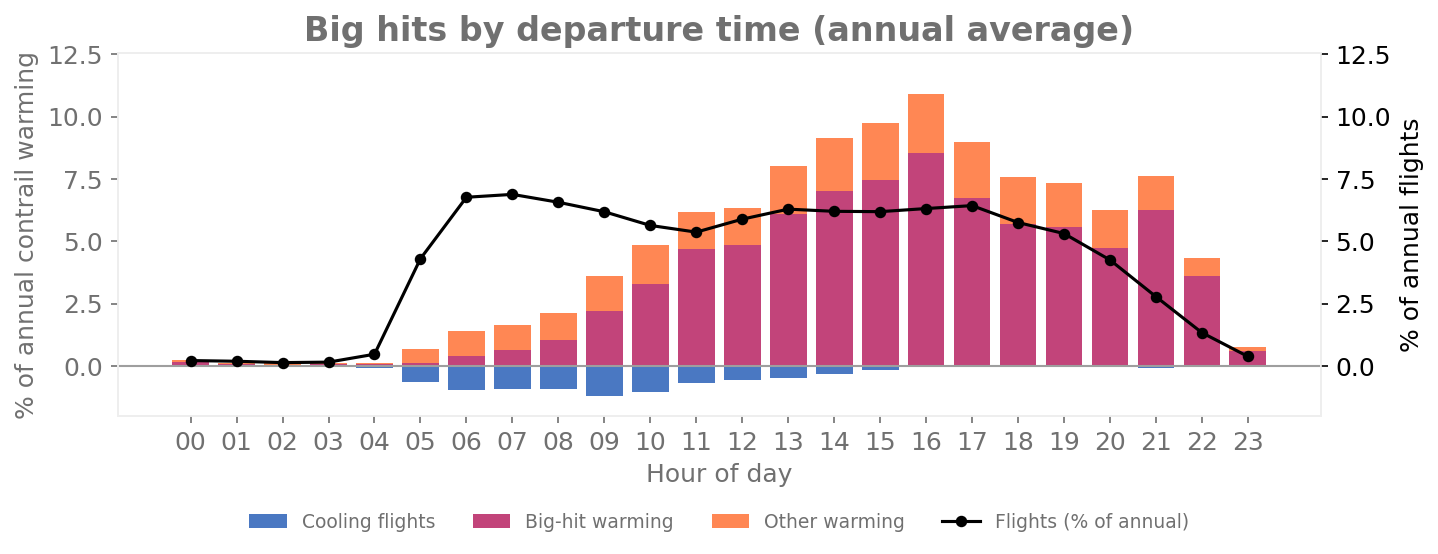

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:421: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_season"] = _df["_month"].map(season_map)
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:422: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

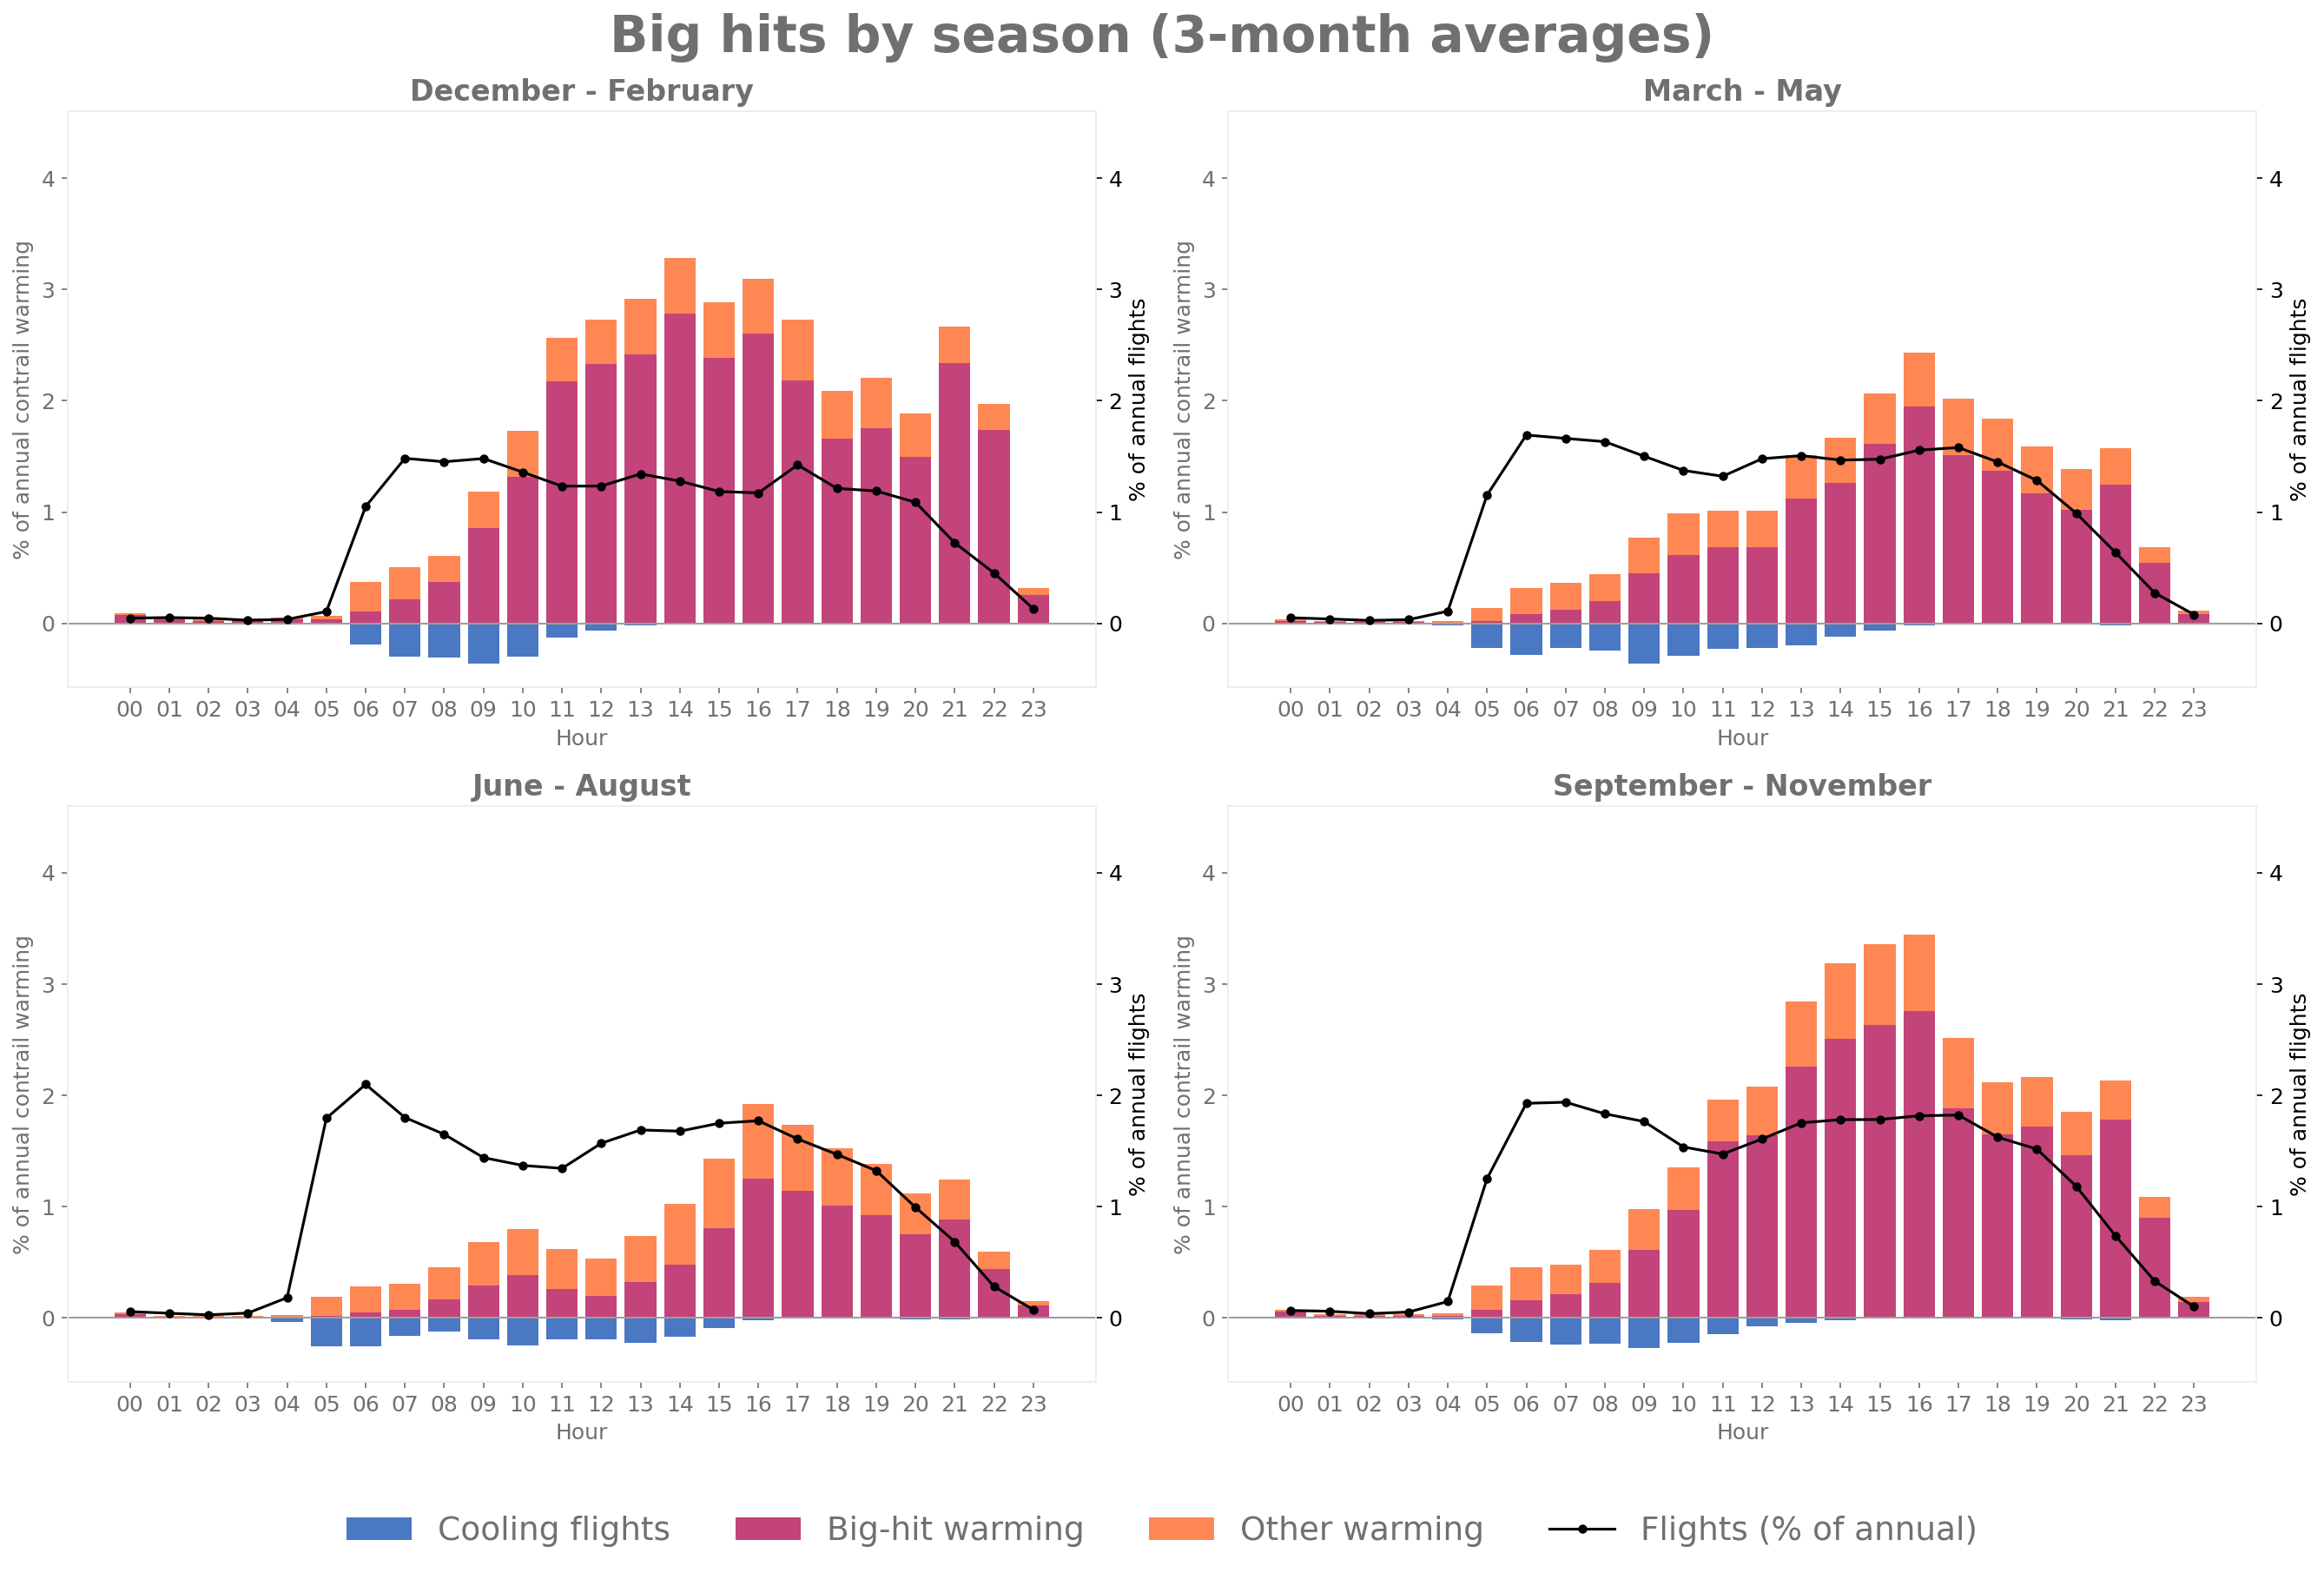

C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_month"] = _df[DATE_COL].dt.month
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:529: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df["_hour"]  = _df[DATE_COL].dt.hour
C:\Users\TE\AppData\Local\Temp\ipykernel_3864\3529241286.py:528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


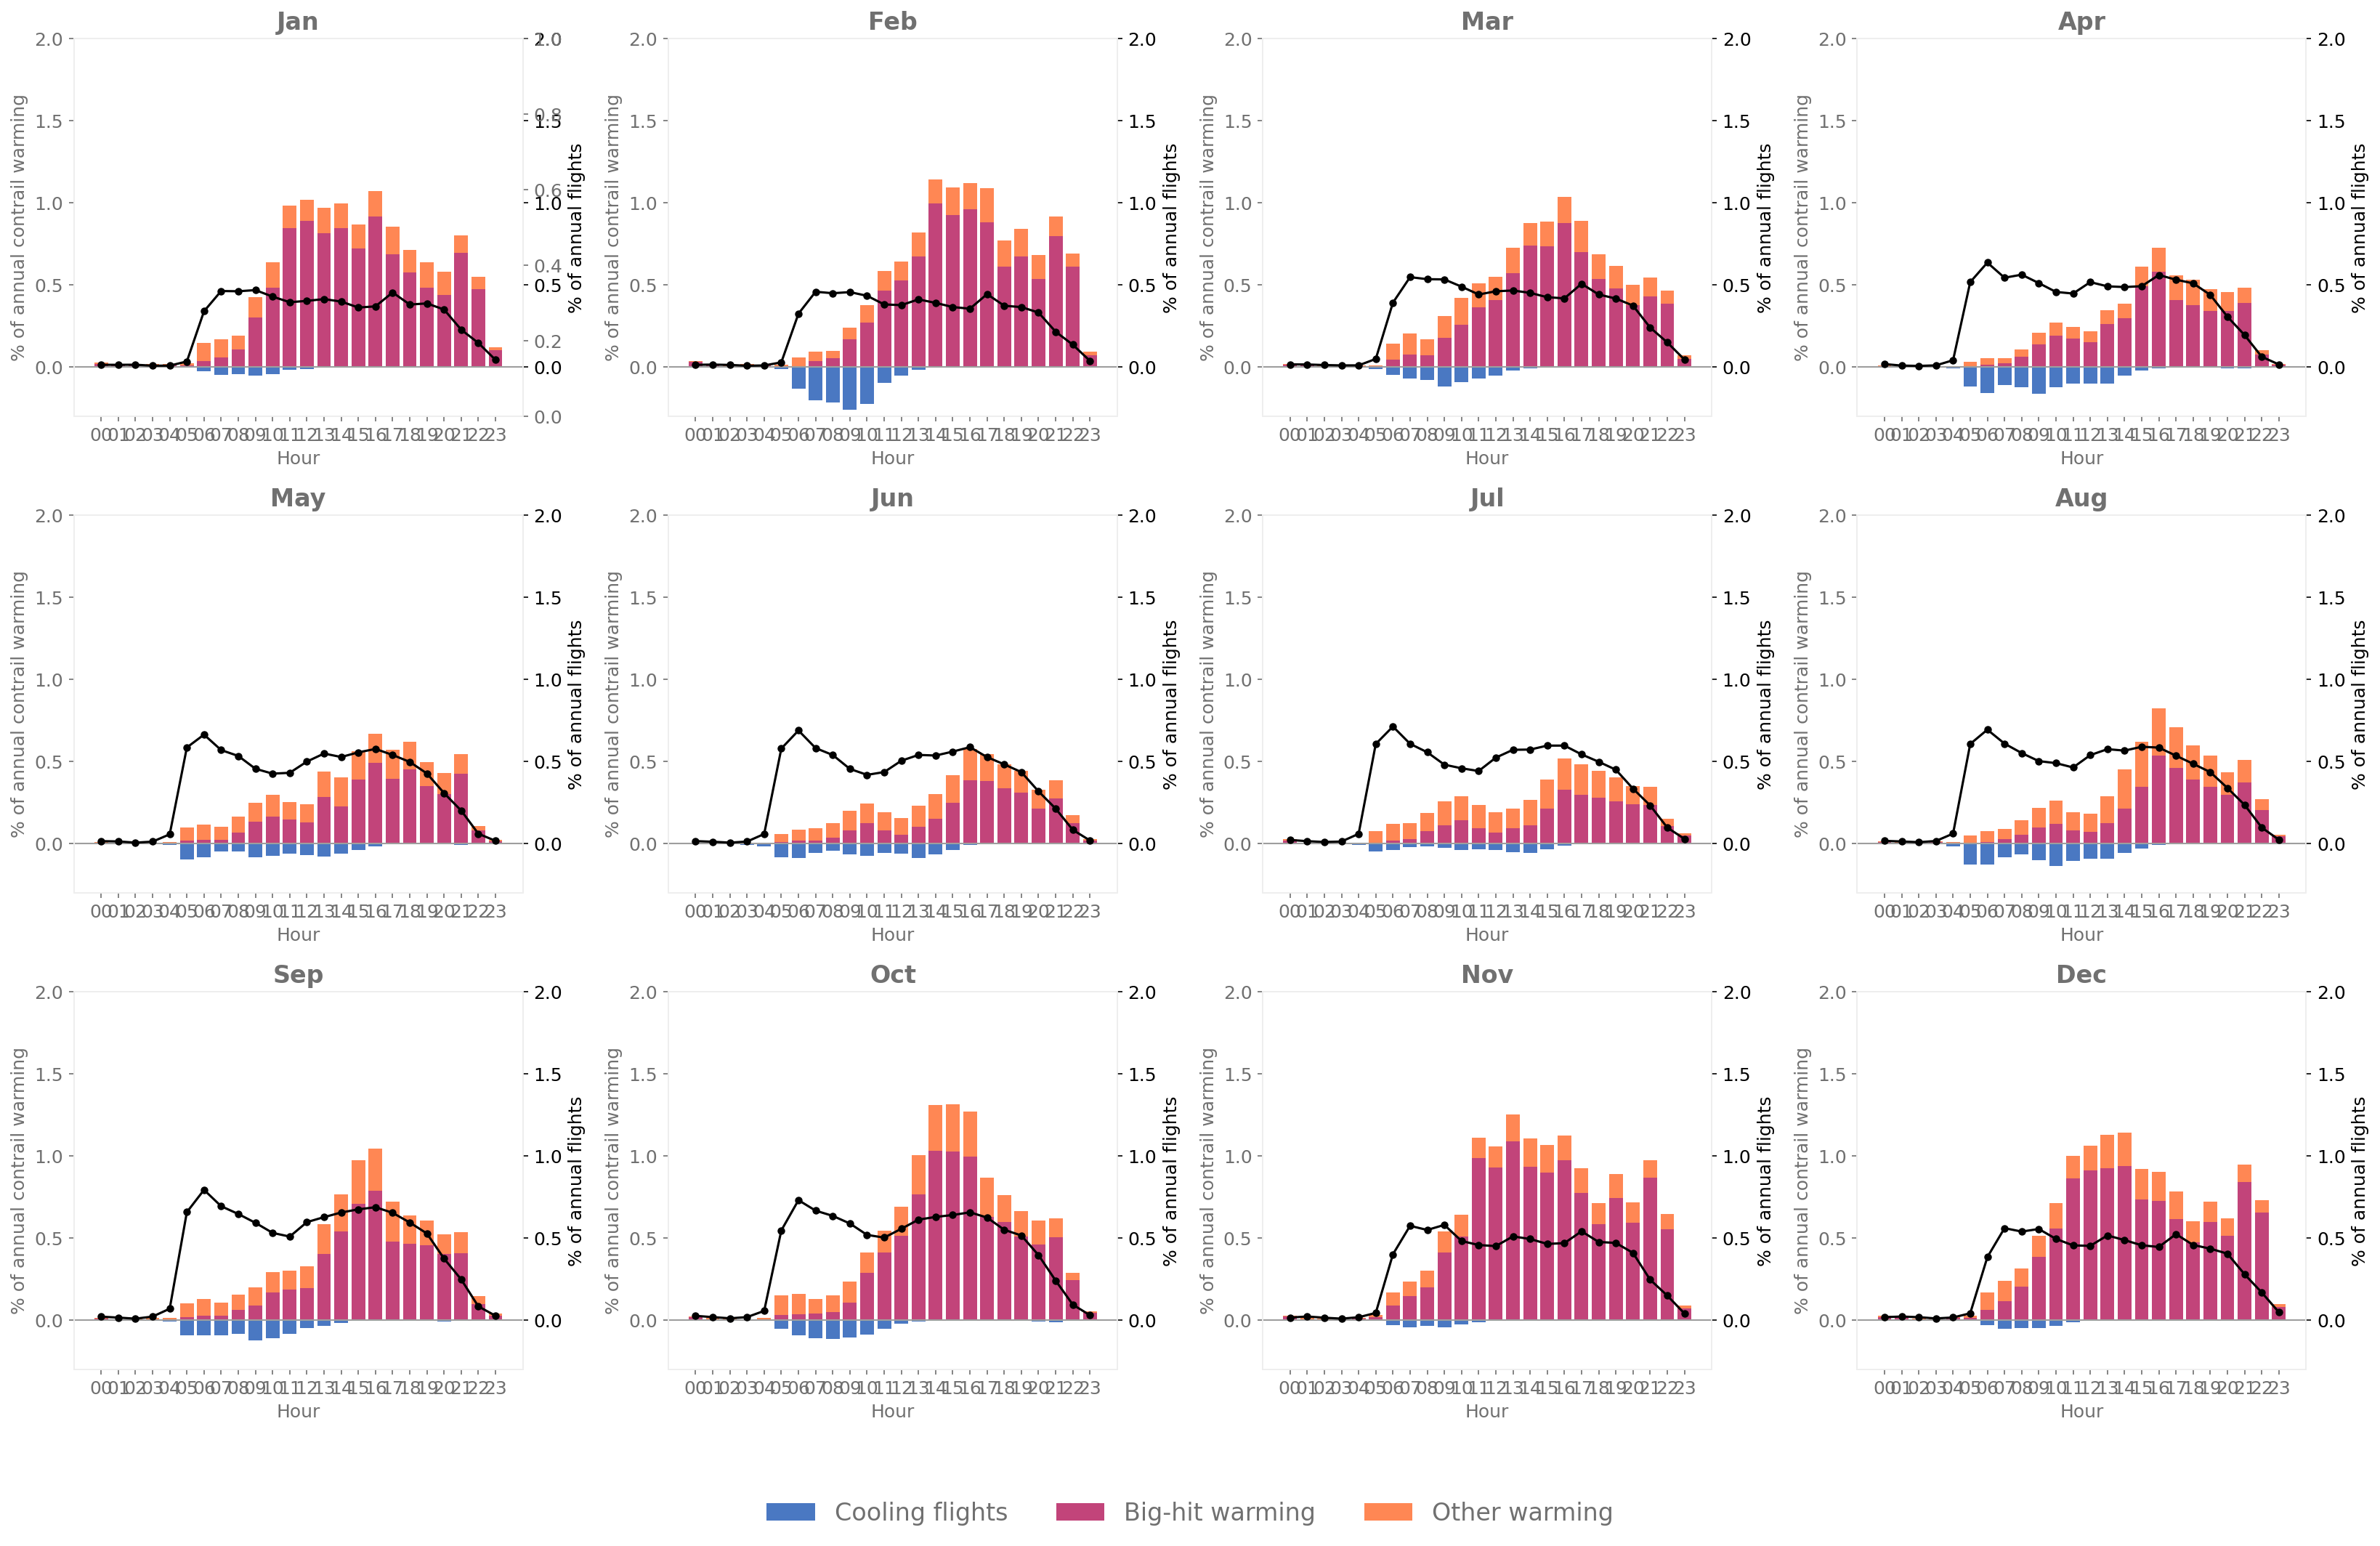

In [15]:
plot_contrail_distribution(df[df["origin_country"] == "GB"])

In [3]:
df.head()

,flight_id,aircraft_type_icao,aircraft_engine_type,origin_airport,origin_airport_name,origin_country,destination_airport,destination_airport_name,destination_country,first_waypoint_time,...,total_contrail_energy_forcing,total_co2,total_co2_forcing_20,total_co2_forcing_100,gwp20,gwp100,_month,_season,_hour,origin_region
2,190101-10098-ISS932,A332,Jet,VTBS,Suvarnabhumi Airport,TH,LIMC,Malpensa International Airport,IT,2019-01-01 00:55:28.155,...,0.0,222065.221953,8.537690e+13,3.143585e+14,0.0,0.0,1,DJF,0,Asia
3,190101-10101-IBK773,B38M,Jet,OMDB,Dubai International Airport,AE,EFHK,Helsinki Vantaa Airport,FI,2019-01-01 00:44:20.000,...,0.0,49474.113871,1.902120e+13,7.003621e+13,0.0,0.0,1,DJF,0,Asia
4,190101-10120-IBK1762,B38M,Jet,KSWF,New York Stewart International Airport,US,EIDW,Dublin Airport,IE,2019-01-01 00:56:29.000,...,0.0,40625.640209,1.561925e+13,5.751019e+13,0.0,0.0,1,DJF,0,Americas
8,190101-10273-TAP005,A343,Jet,LPPT,Humberto Delgado Airport (Lisbon Portela Airport),PT,SBSG,São Gonçalo do Amarante - Governador Aluízio A...,BR,2019-01-01 00:14:31.000,...,0.0,147331.848633,5.664433e+13,2.085649e+14,0.0,0.0,1,DJF,0,Europe
63,190101-11190-SVA213,A320,Jet,OEJN,King Abdulaziz International Airport,SA,LIMC,Malpensa International Airport,IT,2019-01-01 00:40:39.000,...,0.0,40583.605147,1.560308e+13,5.745069e+13,0.0,0.0,1,DJF,0,Asia


## Warming by airport

In [33]:
import pandas as pd

# Load your airports dataset
airports = pd.read_csv("data/airports.csv")

# Inspect to confirm column names
print(airports.head())

# The relevant columns are usually:
# iata_code, latitude, longitude
# In your example: index, name, city, country, iata, icao, lat, lon, elevation, etc.

# Keep only the needed columns and rename for clarity
airports = airports.rename(columns={
    "icao": "origin_airport",
})

# If your CSV columns are unnamed, you can manually assign:
# airports.columns = ["id","name","city","country","iata","icao","lat","lon","altitude","tz_offset","dst","tz","type","source"]

df_europe = df[df["origin_region"] == "Europe"]
# Aggregate by departure airport
agg_df = df_europe.groupby("origin_airport", as_index=False).agg({
    "total_fuel_burn": "sum",
    "total_contrail_energy_forcing": "sum"
})




# Calculate tailpipe CO2 emissions, AGWP and GWP
agg_df["total_co2"]              = agg_df["total_fuel_burn"] * CO2_per_kg_fuel
agg_df["total_co2_forcing_20"]   = agg_df["total_fuel_burn"] * fuel_to_co2_forcing_20
agg_df["total_co2_forcing_100"]  = agg_df["total_fuel_burn"] * fuel_to_co2_forcing_100
agg_df["gwp20"]                  = agg_df["total_contrail_energy_forcing"] / agg_df["total_co2_forcing_20"]   * ERF_RF_ratio
agg_df["gwp100"]                 = agg_df["total_contrail_energy_forcing"] / agg_df["total_co2_forcing_100"]  * ERF_RF_ratio
agg_df["contrail_co2_eq_20"]     = 0.5 * agg_df["total_co2"] * agg_df["gwp20"] / 1e9
agg_df["contrail_co2_eq_100"]    = 0.5 * agg_df["total_co2"] * agg_df["gwp100"] / 1e9

avg_gwp20 = agg_df["total_contrail_energy_forcing"].sum() / agg_df["total_co2_forcing_20"].sum()   * ERF_RF_ratio

def classify_contrail_impact(gwp, avg):
    if gwp < 0.75 * avg:
        return "Low contrail climate impact"
    elif gwp < 1.25 * avg:
        return "Average contrail climate impact"
    elif gwp < 1.75 * avg:
        return "High contrail climate impact"
    else:
        return "Very high contrail climate impact"

agg_df["contrail_impact_category"] = agg_df["gwp20"].apply(lambda x: classify_contrail_impact(x, avg_gwp20))


# Now merge this with your aggregated dataframe
agg_df = agg_df.merge(airports, on="origin_airport", how="left")

agg_df.to_csv("output/airports.csv")

   id                                         name          city  \
0   1                               Goroka Airport        Goroka   
1   2                               Madang Airport        Madang   
2   3                 Mount Hagen Kagamuga Airport   Mount Hagen   
3   4                               Nadzab Airport        Nadzab   
4   5  Port Moresby Jacksons International Airport  Port Moresby   

            country iata  icao       lat         lon  altitude tz_offset dst  \
0  Papua New Guinea  GKA  AYGA -6.081690  145.391998      5282        10   U   
1  Papua New Guinea  MAG  AYMD -5.207080  145.789001        20        10   U   
2  Papua New Guinea  HGU  AYMH -5.826790  144.296005      5388        10   U   
3  Papua New Guinea  LAE  AYNZ -6.569803  146.725977       239        10   U   
4  Papua New Guinea  POM  AYPY -9.443380  147.220001       146        10   U   

                     tz     type       source  
0  Pacific/Port_Moresby  airport  OurAirports  
1  Pacific/Por

## Big hits by day and airport

In [40]:

def label_big_hits(df): 
    title = "All flights"

    def analyse_df(df):
        datum = {}
        datum["n_flights"] = len(df)
        datum["gwp"]       = df["total_contrail_energy_forcing"].sum()/df["total_co2_forcing_100"].sum() * ERF_RF_ratio
        datum["co2"]       = df["total_co2"].sum()
        datum["contrails"] = df["total_contrail_energy_forcing"].sum()
        return datum

    data = {}
    data["global"]            = analyse_df(df)
    no_contrails              = df[df['mean_contrail_lifetime'].isna()]
    data["no_contrails"]      = analyse_df(no_contrails)
    persistent_contrails      = df[df['mean_contrail_lifetime'] > 0]
    data["forming_contrails"] = analyse_df(persistent_contrails)
    cooling_contrails         = persistent_contrails[persistent_contrails['total_contrail_energy_forcing'] < 0]
    data["cooling"]           = analyse_df(cooling_contrails)
    warming_contrails         = persistent_contrails[persistent_contrails['total_contrail_energy_forcing'] > 0]
    data["warming"]           = analyse_df(warming_contrails)

    # Calculate cumulative EF contrail as a function of the share of all flights
    sorted_df      = persistent_contrails.sort_values(by='total_contrail_energy_forcing', ascending=False)
    sorted_forcing = sorted_df['total_contrail_energy_forcing'].cumsum()
    normalized_sorted_forcing = sorted_forcing / sorted_forcing.iloc[-1]

    normalized_sorted_forcing.reset_index(drop=True, inplace=True)  # Reset indices
    flight_share = np.arange(1, len(sorted_df) + 1)/len(df) * 100

    # Determine the percentage of all flights that cause 80% of the annual energy forcing
    eighty_percent_index = (normalized_sorted_forcing >= 0.8).idxmax()
    very_warming_contrails               =  sorted_df.iloc[:eighty_percent_index]
    big_hit_flight_ids = very_warming_contrails["flight_id"].unique().tolist()

    data["very_warming"]                 = analyse_df(very_warming_contrails)
    slightly_warming_contrails           = sorted_df.iloc[eighty_percent_index:]
    data["slightly_warming_and_cooling"] = analyse_df(slightly_warming_contrails)
    slightly_warming_contrails           = slightly_warming_contrails[slightly_warming_contrails['total_contrail_energy_forcing'] > 0]
    data["slightly_warming"]             = analyse_df(slightly_warming_contrails)

    # ---- Assign warming types ----
    df["warming_type"] = np.where(df["mean_contrail_lifetime"].isna(), "No contrail", "Warming")
    df.loc[df["total_contrail_energy_forcing"] < 0, "warming_type"] = "Cooling"
    df.loc[df["flight_id"].isin(big_hit_flight_ids), "warming_type"] = "Big hit"

    return df

df_europe = label_big_hits(df[df["origin_region"] == "Europe"])

C:\Users\TE\AppData\Local\Temp\ipykernel_9052\2050356737.py:43: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [43]:
big_hits.head()

,flight_id,aircraft_type_icao,aircraft_engine_type,origin_airport,origin_airport_name,origin_country,destination_airport,destination_airport_name,destination_country,first_waypoint_time,...,total_co2,total_co2_forcing_20,total_co2_forcing_100,gwp20,gwp100,_month,_season,_hour,origin_region,warming_type
1649,190101-2899-BCS118,A306,Jet,EDDP,Leipzig/Halle Airport,DE,EBBR,Brussels Airport,BE,2019-01-01 00:11:05.395,...,12878.206330,4.951254e+12,1.823056e+13,28.175165,7.652119,1,DJF,0,Europe,Big hit
3567,190101-14003-PIA758,B772,Jet,EGLL,London Heathrow Airport,GB,OPLA,Alama Iqbal International Airport,PK,2019-01-01 01:27:00.000,...,141940.899972,5.457169e+13,2.009334e+14,6.901689,1.874436,1,DJF,1,Europe,Big hit
3835,190101-1659-AFL2149,SU95,Jet,EETN,Lennart Meri Tallinn Airport,EE,UUEE,Sheremetyevo International Airport,RU,2019-01-01 01:05:35.000,...,8249.727227,3.171753e+12,1.167842e+13,90.371424,24.544057,1,DJF,1,Europe,Big hit
3863,190101-16837-CES570,A332,Jet,LFPG,Charles de Gaulle International Airport,FR,ZSPD,Shanghai Pudong International Airport,CN,2019-01-01 01:12:00.000,...,181683.455744,6.985142e+13,2.571935e+14,4.697960,1.275923,1,DJF,1,Europe,Big hit
11893,190101-5232-AFL2717,A320,Jet,EFHK,Helsinki Vantaa Airport,FI,UUEE,Sheremetyevo International Airport,RU,2019-01-01 03:56:28.554,...,9657.201796,3.712882e+12,1.367086e+13,37.812991,10.269665,1,DJF,3,Europe,Big hit


In [ ]:
import pandas as pd

# Compute total CO2 forcing per airport across the entire dataset
annual_totals = (
    df_europe.groupby("origin_airport", as_index=False)
      .agg(total_co2_forcing_20=("total_co2_forcing_20", "sum"))
)

# Select top 20 airports by annual forcing
top20_airports = (
    annual_totals
    .sort_values("total_co2_forcing_20", ascending=False)
    .head(20)["origin_airport"]
    .tolist()
)
# --- filter Big Hit flights ---
big_hits = df_europe[df_europe["warming_type"] == "Big hit"].copy()


# ensure we have a proper date column (adjust if your column name is different)
big_hits["date"] = pd.to_datetime(big_hits["first_waypoint_time"]).dt.date

big_hits_top20 = big_hits[big_hits["origin_airport"].isin(top20_airports)].copy()

# --- aggregate number of Big Hits per airport per day ---
agg = (
    big_hits_top20
    .groupby(["date", "origin_airport_name"], as_index=False)
    .agg(
        big_hit_count=("flight_id", "count"),
        total_co2_forcing_20=("total_co2_forcing_20", "sum")
    )
)


# --- sort by date descending, then airport total_co2_forcing_20 descending ---
agg_full = agg.sort_values(["date", "total_co2_forcing_20"], ascending=[False, False])

# --- format columns for final CSV ---
agg_full["Date"] = pd.to_datetime(agg_full["date"]).dt.strftime("%-d %B %Y")
agg_full.rename(columns={"origin_airport_name": "Airport", "big_hit_count": "Big Hits"}, inplace=True)

# --- select final columns ---
final_df = agg_full[["Date", "Airport", "Big Hits"]]

# --- export to CSV ---
final_df.to_csv("output/daily_big_hit_summary.csv", index=False)

print(final_df.head(10))


                     Date                                  Airport  Big Hits
364   2019-12-31 00:00:00                                    Total       446
7585  2019-12-31 00:00:00                  London Heathrow Airport        94
7576  2019-12-31 00:00:00  Charles de Gaulle International Airport        53
7574  2019-12-31 00:00:00               Amsterdam Airport Schiphol        40
7580  2019-12-31 00:00:00                Frankfurt am Main Airport        34
7573  2019-12-31 00:00:00     Adolfo Suárez Madrid–Barajas Airport        35
7584  2019-12-31 00:00:00                   London Gatwick Airport        29
7592  2019-12-31 00:00:00                           Zürich Airport        18
7588  2019-12-31 00:00:00                           Munich Airport        15
7589  2019-12-31 00:00:00                       Paris-Orly Airport        16


In [47]:
agg_full

,date,Big Hits,total_co2_forcing_20,Airport,Date
364,2019-12-31,563,3.072598e+16,Total,2019-12-31 00:00:00
40186,2019-12-31,94,6.351277e+15,London Heathrow Airport,2019-12-31 00:00:00
40153,2019-12-31,53,3.719387e+15,Charles de Gaulle International Airport,2019-12-31 00:00:00
40148,2019-12-31,40,2.611284e+15,Amsterdam Airport Schiphol,2019-12-31 00:00:00
40164,2019-12-31,34,2.346483e+15,Frankfurt am Main Airport,2019-12-31 00:00:00
...,...,...,...,...,...
411,2019-01-01,1,4.231786e+12,Warsaw Chopin Airport,2019-01-01 00:00:00
394,2019-01-01,1,4.127524e+12,Memmingen Allgau Airport,2019-01-01 00:00:00
368,2019-01-01,1,3.484852e+12,Boryspil International Airport,2019-01-01 00:00:00
389,2019-01-01,1,3.171753e+12,Lennart Meri Tallinn Airport,2019-01-01 00:00:00


In [31]:

df_europe = df[df["origin_region"] == "Europe"]
len(df),len(df_europe)

(8767660, 7436801)

## Big hits by day and FIR

In [ ]:
import json, matplotlib.pyplot as plt, cartopy.crs as ccrs
from cartopy import feature as cfeature
import geopandas as gpd, topojson
from matplotlib.cm import get_cmap
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
# ---------------------------------
# data
# ---------------------------------
with open(r"data/airspaces/observablehq/worldfirs.json") as f:
    topo = json.load(f)

gdf = (
    topojson.Topology(topo, object_name="data")
        .to_gdf()
        .set_crs(4326)           # WGS-84
)

# Filter only FIRs
gdf = gdf[gdf["type"].str.contains("FIR")]

# Load your airports dataset
airports = pd.read_csv("data/airports.csv")

# Keep only the needed columns and rename for clarity
airports = airports.rename(columns={
    "icao": "origin_airport",
})


# Convert airports DataFrame to GeoDataFrame
airports_gdf = gpd.GeoDataFrame(
    airports,
    geometry=gpd.points_from_xy(airports.lon, airports.lat),
    crs="EPSG:4326"  # WGS84
)

# Match each airport to its FIR polygon
airports_with_fir = gpd.sjoin(
    airports_gdf,
    gdf[["geometry", "designator", "name"]],
    how="left",
    predicate="within"
)

# Rename columns for clarity
airports_with_fir = airports_with_fir.rename(columns={
    "designator": "fir_code",
    "name_right": "fir_name"
})

# Check unmatched airports
unmatched = airports_with_fir[airports_with_fir["fir_code"].isna()]
print(f"Unmatched airports: {len(unmatched)}")


In [ ]:
import pandas as pd

# --- make sure FIRs are already attached ---
df_europe = df_europe.merge(
    airports_with_fir[["origin_airport", "fir_code", "fir_name"]],
    on="origin_airport",
    how="left"
)

# --- ensure we have a proper date column ---
df_europe["date"] = pd.to_datetime(df_europe["first_waypoint_time"]).dt.date

# --- aggregate by date and FIR ---
fir_daily_full = (
    df_europe.groupby(["date", "fir_code", "fir_name"], as_index=False)
    .agg(
        n_total=("flight_id", "count"),
        n_big_hit=("warming_type", lambda x: (x == "Big hit").sum()),
        n_warming=("warming_type", lambda x: (x == "Warming").sum()),
        n_cooling=("warming_type", lambda x: (x == "Cooling").sum()),
        n_no_contrail=("warming_type", lambda x: (x == "No contrail").sum()),
        total_contrail_energy_forcing=("total_contrail_energy_forcing", "sum"),
        total_fuel_burn=("total_fuel_burn", "sum"),
    )
)


In [ ]:
fir_daily_simple = fir_daily_full[[
    "date", "fir_code", "fir_name", "n_big_hit"
]].rename(columns={"n_big_hit": "big_hit_count"})

fir_daily_simple.to_csv("output/daily_big_hit_by_fir.csv", index=False)


In [ ]:
fir_totals = (
    fir_daily_full.groupby(["fir_code", "fir_name"], as_index=False)
    .agg(
        n_total=("n_total", "sum"),
        n_big_hit=("n_big_hit", "sum"),
        n_warming=("n_warming", "sum"),
        n_cooling=("n_cooling", "sum"),
        n_no_contrail=("n_no_contrail", "sum"),
        total_contrail_energy_forcing=("total_contrail_energy_forcing", "sum"),
        total_fuel_burn=("total_fuel_burn", "sum"),
    )
)
fir_totals["total_co2"]              = fir_totals["total_fuel_burn"] * CO2_per_kg_fuel
fir_totals["total_co2_forcing_20"]   = fir_totals["total_fuel_burn"] * fuel_to_co2_forcing_20
fir_totals["total_co2_forcing_100"]  = fir_totals["total_fuel_burn"] * fuel_to_co2_forcing_100
fir_totals["gwp20"]                  = fir_totals["total_contrail_energy_forcing"] / fir_totals["total_co2_forcing_20"]   * ERF_RF_ratio
fir_totals["gwp100"]                 = fir_totals["total_contrail_energy_forcing"] / fir_totals["total_co2_forcing_100"]   * ERF_RF_ratio

In [ ]:
fir_totals.to_csv("output/firs.csv")